# 15 — Sintéticos I: generadores de escenarios con régimen conocido

<a id="s0"></a>
## 0. Objetivo

Construir generadores de trayectorias multivariantes de las features del benchmark **con la
secuencia de régimen conocida** (verdad-terreno exacta), ajustados solo con el tramo de
entrenamiento, para (a) validar su fidelidad en `16_sinteticos_validacion`, (b) estresar los
detectores en un laboratorio controlado en `17_sinteticos_laboratorio` y (c) ampliar la escasa
muestra de crisis en `18_sinteticos_aumento`. Este notebook ajusta los generadores, documenta la
convergencia de cada uno con su diagnóstico propio, muestrea las trayectorias que consumen los
notebooks siguientes y comprueba su **sanidad** (que lo generado es finito, respeta el contrato
y tiene la escala correcta). No valida ni admite ningún generador.

### Preguntas que responde

1. ¿Qué generadores paramétricos reproducen la dinámica de régimen del tramo de entrenamiento
   (duraciones, transiciones, niveles de volatilidad y correlación por régimen)?
2. ¿Aportan los generadores neuronales realismo adicional (colas, dependencia no lineal,
   asimetrías) sin memorizar el entrenamiento?
3. ¿Cómo se impone una secuencia de régimen dada (condicionamiento) y cómo se etiqueta la
   verdad-terreno en la salida?
4. ¿Cuál es el coste de ajuste y de muestreo, y es reproducible con la semilla del proyecto?

### Entradas y salidas (vía `regimenes.rutas`)

| papel | ruta | versionado |
|---|---|---|
| entrada: paneles reales por pista | `rutas.DATA_PROCESSED` | no (se regeneran con `03_preprocesado`) |
| entrada: precio del S&P 500 (re-derivación) | `rutas.DATA_RAW` | no |
| entrada: ventanas de crisis del banco de pruebas | `rutas.BENCHMARK_SPEC` | sí |
| entrada: configuración de generadores y muestreo | `rutas.SINTETICOS_CONFIG` | sí |
| salida: generador ajustado (`generador.pkl`) | `rutas.DATA_SINTETICOS / <generador> / pista<X>` | no |
| salida: trayectorias con cadena simulada (`trayectorias.parquet`) | `rutas.DATA_SINTETICOS / <generador> / pista<X>` | no |
| salida: trayectorias con régimen impuesto (`trayectorias_impuesto.parquet`) | `rutas.DATA_SINTETICOS / <generador> / pista<X>` | no |
| salida: ficha de ajuste y de muestreo (`*_resumen.json`) e historial de convergencia (`*_historial.csv`) | `rutas.RESULTS_SINTETICOS / 'generadores'` | sí |
| salida: tablas de sanidad (`sanidad_*.csv`) | `rutas.RESULTS_SINTETICOS / 'generadores'` | sí |
| salida: figuras (`*.png`) | `rutas.RESULTS_SINTETICOS / 'generadores'` | no (van embebidas en el notebook) |

### Cambios respecto al diseño previsto

El esqueleto de este notebook anunciaba un catálogo que no es el que se ha implementado. Las
cuatro desviaciones y su motivo:

1. **TimeGAN y QuantGAN se sustituyen por los cuatro generadores neuronales del taller previo del
   equipo** (flow matching, difusión, cVAE y cGAN), portados a torch puro y reformulados como
   modelos de «siguiente bloque». El motivo es el coste: el proyecto se ejecuta en CPU, y una
   arquitectura recurrente o convolucional entrenada sobre ventanas largas no cabe en el
   presupuesto de minutos por generador que exige poder repetir el notebook. Los cuatro modelos
   portados comparten representación y encadenado, de modo que lo que se compara entre ellos es
   el modelo y no el preprocesado.
2. **«MS-VAR que reutiliza D05» pasa a ser un VAR por régimen observado.** D05 es un modelo de
   cambio de régimen univariante (solo el retorno del S&P 500) y no ofrece nada que reutilizar
   para un panel multivariante. Además, aquí el régimen es conocido: la verosimilitud se separa
   por régimen y el estimador es de mínimos cuadrados, sin filtro de Hamilton ni EM.
3. **«HMM-t» no se implementa como generador aparte.** Las colas pesadas por régimen, que era lo
   que debía aportar, las cubren `garch_regimen` (innovación t de Student con grados de libertad
   propios de cada régimen) y `rbig` (marginales empíricas por régimen).
4. **Se añaden tres generadores que el esqueleto no preveía**: `jitter` (datos reales más ruido:
   suelo de comparación y control positivo de memorización), `gaussiano_regimen` (línea base que
   solo conoce medias y covarianzas por régimen) y `rbig` (flujo normalizante sin gradiente).

### Índice

0. [Objetivo, preguntas, entradas/salidas y cambios de diseño](#s0)
1. [Configuración](#s1)
2. [Datos de entrenamiento y régimen de referencia](#s2) — [la cadena de régimen simulada](#s2x) · [qué significa `regime = 1` en sintético](#s2y)
3. [Espacio de generación](#s3)
4. [Generadores paramétricos](#s4): [jitter](#s4-1) · [bootstrap](#s4-2) · [gaussiano](#s4-3) · [VAR](#s4-4) · [GARCH](#s4-5) · [RBIG](#s4-6)
5. [Generadores neuronales](#s5): [flow matching](#s5-1) · [difusión](#s5-2) · [cVAE](#s5-3) · [cGAN](#s5-4)
6. [Muestreo, persistencia y sanidad común](#s6)
7. [Resumen y siguiente paso](#s7)

> **Regla de lectura.** Toda cifra que aparece en el texto sale de una celda; los párrafos en
> markdown solo razonan de forma cualitativa. Lo que aquí se mide es **sanidad**, no validez: la
> fidelidad (discriminador, memorización, hechos estilizados, colas condicionales), la utilidad
> (entrenar en sintético y evaluar en real) y el veredicto de admisión de cada generador son el
> notebook `16_sinteticos_validacion`.

<a id="s1"></a>
## 1. Configuración

Todo sale de `configs/sinteticos.yaml`: semilla, pistas y cortes de entrenamiento, generadores con
sus parámetros y opciones de muestreo. La tabla de generadores se construye desde el registro
(`regimenes.sinteticos.registry`): la clase aporta los valores por defecto (`PARAMS`) y el yaml los
que sobrescribe.

`EJECUTAR = False` (por defecto) **no ajusta ni muestrea nada**: carga los generadores ajustados,
las fichas y las trayectorias guardadas, y recalcula solo lo barato (tablas, figuras y los
barridos de los generadores paramétricos). Si falta algún artefacto, o no corresponde a la
configuración vigente, la celda se detiene indicando qué hacer. `EJECUTAR = True` ajusta lo que
falte o haya quedado obsoleto, guarda el modelo, la ficha, el historial y las trayectorias;
`FORZAR = True` reajusta y remuestrea aunque lo guardado esté vigente.

In [1]:
%matplotlib inline
import json
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from IPython.display import Markdown, display
from scipy.spatial import cKDTree

from regimenes import informes as inf
from regimenes import rutas, viz
from regimenes.sinteticos import GeneradorBase, datos, espacio, persistencia
from regimenes.sinteticos import registry as registro
from regimenes.sinteticos.comun import FICHERO_MODELO

try:
    import torch
    from regimenes.sinteticos.neuronales import _torch as nucleo_torch  # noqa: F401
except ImportError as exc:  # torch es el extra opcional [deep]
    raise ImportError('Los generadores neuronales necesitan PyTorch: pip install -e .[deep]') from exc

EJECUTAR = False   # True = ajusta y muestrea lo que falte u obsoleto (minutos en CPU; ver tiempos en §6)
FORZAR = False     # True = ignora lo guardado y reajusta/remuestrea todo (solo con EJECUTAR = True)

CONFIG = yaml.safe_load(rutas.SINTETICOS_CONFIG.read_text(encoding='utf-8'))
SEMILLA = int(CONFIG['semilla'])
ENTRENAMIENTO = {CONFIG[b]['pista']: CONFIG[b] for b in ('entrenamiento', 'entrenamiento_secundario')}
PISTAS = list(ENTRENAMIENTO)
PISTA_PRINCIPAL = CONFIG['entrenamiento']['pista']
GENERADORES = list(CONFIG['generadores'])
PARAMS = {n: dict(v.get('params') or {}) for n, v in CONFIG['generadores'].items()}
PARAMETRICOS = [n for n in GENERADORES if registro.familia_de(n) == 'parametricos']
NEURONALES = [n for n in GENERADORES if registro.familia_de(n) == 'neuronales']
MUESTREO = CONFIG['muestreo']
N_PATHS, LENGTH = int(MUESTREO['n_paths']), int(MUESTREO['length'])
OPC_CADENA = {'inicial': MUESTREO['inicial'], 'duraciones': MUESTREO['duraciones']}
if MUESTREO.get('regimenes') is not None:
    raise ValueError('configs/sinteticos.yaml: este notebook espera muestreo.regimenes = null (cadena simulada).')

FIG_DIR = rutas.RESULTS_SINTETICOS / 'generadores'   # figuras (gitignored)
RES_DIR = persistencia.dir_resumenes()               # fichas, historiales y tablas (versionables)
FIG_DIR.mkdir(parents=True, exist_ok=True)
rel = inf.ruta_relativa
ETIQ_REG = {0: 'calma', 1: 'crisis'}
C_PISTA = {'A': viz.C_LONG, 'B': viz.C_SHORT}

viz.use_house_style()
inf.opciones_pandas()
pd.set_option('display.max_colwidth', None)
warnings.filterwarnings('ignore', category=FutureWarning)


def guardar(fig, nombre):
    """Guarda en results/sinteticos/generadores/<nombre>.png con el estilo de casa."""
    return inf.guardar_figura(fig, FIG_DIR, nombre)


def md(*lineas):
    """Texto con cifras generado por celda."""
    display(Markdown('\n'.join(lineas)))


def fmt(x, dec=2):
    """Número con coma decimal para el texto generado."""
    return '—' if x is None or not np.isfinite(x) else f'{x:.{dec}f}'.replace('.', ',')


print(f'Semilla {SEMILLA} | pista principal {PISTA_PRINCIPAL} | pistas y cortes: '
      + ', '.join(f"{t} hasta {ENTRENAMIENTO[t]['fin_train']}" for t in PISTAS))
print(f'Muestreo: {N_PATHS} trayectorias x {LENGTH} sesiones, cadena {OPC_CADENA}')
print(f'EJECUTAR = {EJECUTAR} | FORZAR = {FORZAR} | torch {torch.__version__}, {torch.get_num_threads()} hilos')
print('Figuras :', rel(FIG_DIR))
print('Fichas  :', rel(RES_DIR))

Semilla 42 | pista principal A | pistas y cortes: A hasta 2006-12-31, B hasta 2017-12-31
Muestreo: 100 trayectorias x 2520 sesiones, cadena {'inicial': 'estacionaria', 'duraciones': 'geometricas'}
EJECUTAR = False | FORZAR = False | torch 2.13.0+cpu, 6 hilos
Figuras : results/sinteticos/generadores
Fichas  : results/sinteticos/generadores


In [2]:
filas = []
for n in GENERADORES:
    clase = registro.clase(n)
    declarada = CONFIG['generadores'][n]['familia']
    if declarada != clase.familia or clase.familia != registro.familia_de(n):
        raise ValueError(f'{n}: la familia del yaml ({declarada}) no coincide con la del registro ({clase.familia}).')
    resto = {k: v for k, v in clase.PARAMS.items() if k not in PARAMS[n]}
    filas.append({
        'generador': n, 'familia': clase.familia, 'clase': clase.__name__,
        'params del yaml': ', '.join(f'{k}={v}' for k, v in PARAMS[n].items()),
        'otros parámetros (valor por defecto de la clase)': len(resto),
    })
TABLA_GENERADORES = pd.DataFrame(filas).set_index('generador')
display(TABLA_GENERADORES)
print(f'{len(GENERADORES)} generadores: {len(PARAMETRICOS)} paramétricos y {len(NEURONALES)} neuronales; '
      f'todos heredan de GeneradorBase: {all(issubclass(registro.clase(n), GeneradorBase) for n in GENERADORES)}.')

RUTAS_NB = {
    'entrada: paneles reales': rutas.DATA_PROCESSED,
    'entrada: precio del S&P 500': rutas.DATA_RAW,
    'entrada: banco de pruebas': rutas.BENCHMARK_SPEC,
    'entrada: configuración de sintéticos': rutas.SINTETICOS_CONFIG,
    'salida: modelos y trayectorias (gitignored)': rutas.DATA_SINTETICOS,
    'salida: fichas, historiales, tablas y figuras': RES_DIR,
}
display(pd.DataFrame([{'papel': k, 'ruta': rel(v), 'existe': v.exists()} for k, v in RUTAS_NB.items()]).set_index('papel'))

,familia,clase,params del yaml,otros parámetros (valor por defecto de la clase)
generador,,,,
jitter,parametricos,Jitter,"sigma=0.1, longitud_media=63",0
bootstrap_regimen,parametricos,BootstrapRegimen,longitud_media=21,0
gaussiano_regimen,parametricos,GaussianoRegimen,estimador=ledoit_wolf,1
var_regimen,parametricos,VarRegimen,"orden=1, innovaciones=bootstrap, radio_max=0.999, anclar_media=True",1
garch_regimen,parametricos,GarchRegimen,"ajuste=conjunto, persistencia_max=0.995, techo_varianza=1.0, cuantil_techo=0.99, techo_nivel=1.5",7
rbig,parametricos,RBIG,"largo_bloque=21, largo_contexto=5, n_componentes=64",6
flow_matching,neuronales,FlowMatching,"largo_bloque=21, largo_contexto=21, epocas=40",20
difusion,neuronales,Difusion,"largo_bloque=21, largo_contexto=21, epocas=60",23
cvae,neuronales,CVAE,"largo_bloque=21, largo_contexto=21, epocas=120",22


10 generadores: 6 paramétricos y 4 neuronales; todos heredan de GeneradorBase: True.


,ruta,existe
papel,,
entrada: paneles reales,data/processed,True
entrada: precio del S&P 500,data/raw,True
entrada: banco de pruebas,configs/benchmark_spec.yaml,True
entrada: configuración de sintéticos,configs/sinteticos.yaml,True
salida: modelos y trayectorias (gitignored),data/sinteticos,True
"salida: fichas, historiales, tablas y figuras",results/sinteticos/generadores,True


<a id="s2"></a>
## 2. Datos de entrenamiento y régimen de referencia

Cada generador se ajusta con **exactamente** el mismo panel y la misma etiqueta de régimen
(`datos.cargar_entrenamiento`): el núcleo de features de la pista más el log-retorno crudo del
S&P 500, recortado al corte de entrenamiento y sin el tramo de calentamiento de las features
causales.

El régimen de referencia es binario y sale de las ventanas `[pico, suelo]` de `crisis_windows` del
banco de pruebas: un día es crisis si cae dentro de alguna ventana y calma en otro caso. **Nunca
sale de un detector.** Si lo hiciera, ese detector (y su familia) jugaría en casa al evaluarse
sobre lo generado: la verdad-terreno sintética sería, por construcción, lo que él considera
crisis. Usar las ventanas del juez tiene su propio coste —las ventanas se fijaron mirando la
historia, de modo que el régimen no es observable en tiempo real—, pero ese coste es común a
todos los detectores.

La celda comprueba explícitamente las dos condiciones anti-fuga de los datos: que ninguna fila
es posterior al corte y que el corte no parte ningún episodio de crisis (un episodio a medias
sesgaría duraciones y transiciones).

In [3]:
PANEL, REG, RACHAS, P_TRANS, FREC, EPISODIOS = {}, {}, {}, {}, {}, {}
filas = []
for t in PISTAS:
    corte = pd.Timestamp(ENTRENAMIENTO[t]['fin_train'])
    panel, reg = datos.cargar_entrenamiento(t, corte, ENTRENAMIENTO[t].get('features') or None)
    # --- comprobaciones anti-fuga explícitas
    assert panel.index.max() <= corte, f'pista {t}: hay filas posteriores a fin_train'
    assert datos.episodio_cruzado(t, corte) is None, f'pista {t}: fin_train parte un episodio de crisis'
    assert np.isfinite(panel.to_numpy()).all() and reg.index.equals(panel.index)
    ventanas = datos.ventanas_crisis(t)
    a_medias = [k for k, (a, b) in ventanas.items() if a <= corte < b]
    en_train = {k: v for k, v in ventanas.items() if v[1] <= corte and v[1] >= panel.index[0]}
    PANEL[t], REG[t] = panel, reg
    RACHAS[t] = datos.rachas(reg)
    P_TRANS[t] = datos.matriz_transicion(reg, n=2)
    FREC[t] = np.bincount(reg.to_numpy(), minlength=2) / len(reg)
    # --- ficha de cada episodio de crisis de train
    ep = []
    for nombre, (a, b) in en_train.items():
        dias = (panel.index >= a) & (panel.index <= b)
        r = panel.loc[dias, 'SP500_ret']
        ep.append({'episodio': nombre, 'pico': a.date(), 'suelo': b.date(), 'sesiones': int(dias.sum()),
                   'retorno acumulado (%)': 100 * np.expm1(r.sum()), 'deriva media diaria (pb)': 1e4 * r.mean(),
                   'desv. diaria (%)': 100 * r.std()})
    EPISODIOS[t] = pd.DataFrame(ep).set_index('episodio')
    assert len(EPISODIOS[t]) == int((RACHAS[t]['regimen'] == 1).sum()), 'episodios y rachas de crisis no casan'
    filas.append({
        'pista': t, 'fin_train (yaml)': corte.date(), 'primera fila': panel.index[0].date(),
        'última fila': panel.index[-1].date(), 'sesiones': len(panel), 'columnas': panel.shape[1],
        'filas posteriores al corte': int((panel.index > corte).sum()),
        'episodios partidos por el corte': len(a_medias), 'episodios de crisis en train': len(en_train),
        '% de días de crisis': 100 * FREC[t][1],
    })
DATOS_TRAIN = pd.DataFrame(filas).set_index('pista')
display(DATOS_TRAIN.assign(**{'% de días de crisis': DATOS_TRAIN['% de días de crisis'].round(2)}).T)
for t in PISTAS:
    print(f'Pista {t} — columnas del panel de ajuste: {", ".join(PANEL[t].columns)}')

pista,A,B
fin_train (yaml),2006-12-31,2017-12-31
primera fila,1962-03-29,2007-04-11
última fila,2006-12-29,2017-12-29
sesiones,11267,2702
columnas,10,15
filas posteriores al corte,0,0
episodios partidos por el corte,0,0
episodios de crisis en train,8,4
% de días de crisis,19.62,25.87


Pista A — columnas del panel de ajuste: SP500_ret_z, SP500_vol_z, SP500_momentum, SP500_drawdown, FF_MKT_z, DGS10_change_z, credit_BaaAaa_mensual_z, term_spread_hist_z, INDPRO_yoy_z, SP500_ret
Pista B — columnas del panel de ajuste: SP500_ret_z, SP500_vol_z, SP500_momentum, SP500_drawdown, FF_MKT_z, DGS10_change_z, credit_BaaAaa_mensual_z, term_spread_hist_z, INDPRO_yoy_z, VIX_level_z, MOVE_level_z, credit_BAA10Y_z, DFII10_change_z, corr_spx_bond, SP500_ret


Rachas del régimen de referencia, duraciones por régimen y matriz de transición empírica (el
estimador de máxima verosimilitud por conteo de transiciones consecutivas). La duración esperada
que implica la matriz, $1/(1-P_{kk})$, es la media de la geométrica con la que una cadena de
Markov de primer orden reparte las duraciones.

In [4]:
for t in PISTAS:
    tabla = RACHAS[t].assign(regimen=RACHAS[t]['regimen'].map(ETIQ_REG))
    tabla[['inicio', 'fin']] = tabla[['inicio', 'fin']].apply(lambda s: s.dt.date)
    dur = RACHAS[t].groupby('regimen')['duracion'].agg(['count', 'mean', 'median', 'min', 'max'])
    dur.index = dur.index.map(ETIQ_REG)
    dur['esperada por la matriz'] = [1.0 / (1.0 - P_TRANS[t][k, k]) for k in (0, 1)]
    dur['prob. de permanencia'] = [P_TRANS[t][k, k] for k in (0, 1)]
    dur['frecuencia estacionaria'] = datos.distribucion_estacionaria(P_TRANS[t], FREC[t])
    display(Markdown(f'**Pista {t}** — {len(tabla)} rachas ({int((RACHAS[t]["regimen"] == 1).sum())} de crisis)'))
    display(tabla.set_index('inicio').T)
    display(dur.rename(columns={'count': 'rachas', 'mean': 'media', 'median': 'mediana'}).style.format(
        {'media': '{:.0f}', 'mediana': '{:.0f}', 'esperada por la matriz': '{:.0f}',
         'prob. de permanencia': '{:.5f}', 'frecuencia estacionaria': '{:.3f}'}))
    display(EPISODIOS[t].style.format({'retorno acumulado (%)': '{:.1f}', 'deriva media diaria (pb)': '{:.1f}',
                                        'desv. diaria (%)': '{:.2f}'}))

**Pista A** — 17 rachas (8 de crisis)

inicio,1962-03-29,1966-02-09,1966-10-10,1968-11-29,1970-05-27,1973-01-11,1974-10-04,1980-11-28,1982-08-13,1987-08-25,1987-12-07,1990-07-16,1990-10-12,1998-07-17,1998-09-01,2000-03-24,2002-10-10
fin,1966-02-08,1966-10-07,1968-11-27,1970-05-26,1973-01-10,1974-10-03,1980-11-26,1982-08-12,1987-08-24,1987-12-04,1990-07-13,1990-10-11,1998-07-16,1998-08-31,2000-03-23,2002-10-09,2006-12-29
regimen,calma,crisis,calma,crisis,calma,crisis,calma,crisis,calma,crisis,calma,crisis,calma,crisis,calma,crisis,calma
duracion,974,168,515,370,664,437,1554,431,1272,72,658,63,1961,32,394,638,1064


,rachas,media,mediana,min,max,esperada por la matriz,prob. de permanencia,frecuencia estacionaria
regimen,,,,,,,,
calma,9,1006,974,394,1961,1132,0.99912,0.804
crisis,8,276,269,32,638,276,0.99638,0.196


,pico,suelo,sesiones,retorno acumulado (%),deriva media diaria (pb),desv. diaria (%)
episodio,,,,,,
credit_crunch_1966,1966-02-09,1966-10-07,168,-21.8,-14.6,0.78
bear_1969_70,1968-11-29,1970-05-26,370,-35.7,-11.9,0.72
oil_stagflation_1973,1973-01-11,1974-10-03,437,-47.9,-14.9,1.12
volcker_1980_82,1980-11-28,1982-08-12,431,-26.9,-7.3,0.87
black_monday_1987,1987-08-25,1987-12-04,72,-32.8,-55.3,3.57
gulf_war_sl_1990,1990-07-16,1990-10-11,63,-19.6,-34.6,1.27
ltcm_russia_1998,1998-07-17,1998-08-31,32,-19.1,-66.4,1.79
dotcom_2000_02,2000-03-24,2002-10-09,638,-49.1,-10.6,1.44


**Pista B** — 9 rachas (4 de crisis)

inicio,2007-04-11,2007-10-09,2009-03-10,2010-04-23,2010-07-06,2011-04-29,2011-10-04,2015-05-21,2016-02-12
fin,2007-10-08,2009-03-09,2010-04-22,2010-07-02,2011-04-28,2011-10-03,2015-05-20,2016-02-11,2017-12-29
regimen,calma,crisis,calma,crisis,calma,crisis,calma,crisis,calma
duracion,126,356,283,50,207,109,912,184,475


,rachas,media,mediana,min,max,esperada por la matriz,prob. de permanencia,frecuencia estacionaria
regimen,,,,,,,,
calma,5,401,283,126,912,500,0.99800,0.741
crisis,4,175,146,50,356,175,0.99428,0.259


,pico,suelo,sesiones,retorno acumulado (%),deriva media diaria (pb),desv. diaria (%)
episodio,,,,,,
gfc_2007_09,2007-10-09,2009-03-09,356,-56.4,-23.3,2.40
flash_crash_euro1_2010,2010-04-23,2010-07-02,50,-15.4,-33.4,1.71
us_downgrade_euro2_2011,2011-04-29,2011-10-03,109,-19.2,-19.6,1.72
china_oil_2015_16,2015-05-21,2016-02-11,184,-14.0,-8.2,1.13


figura -> results/sinteticos/generadores/train_regimen_referencia.png


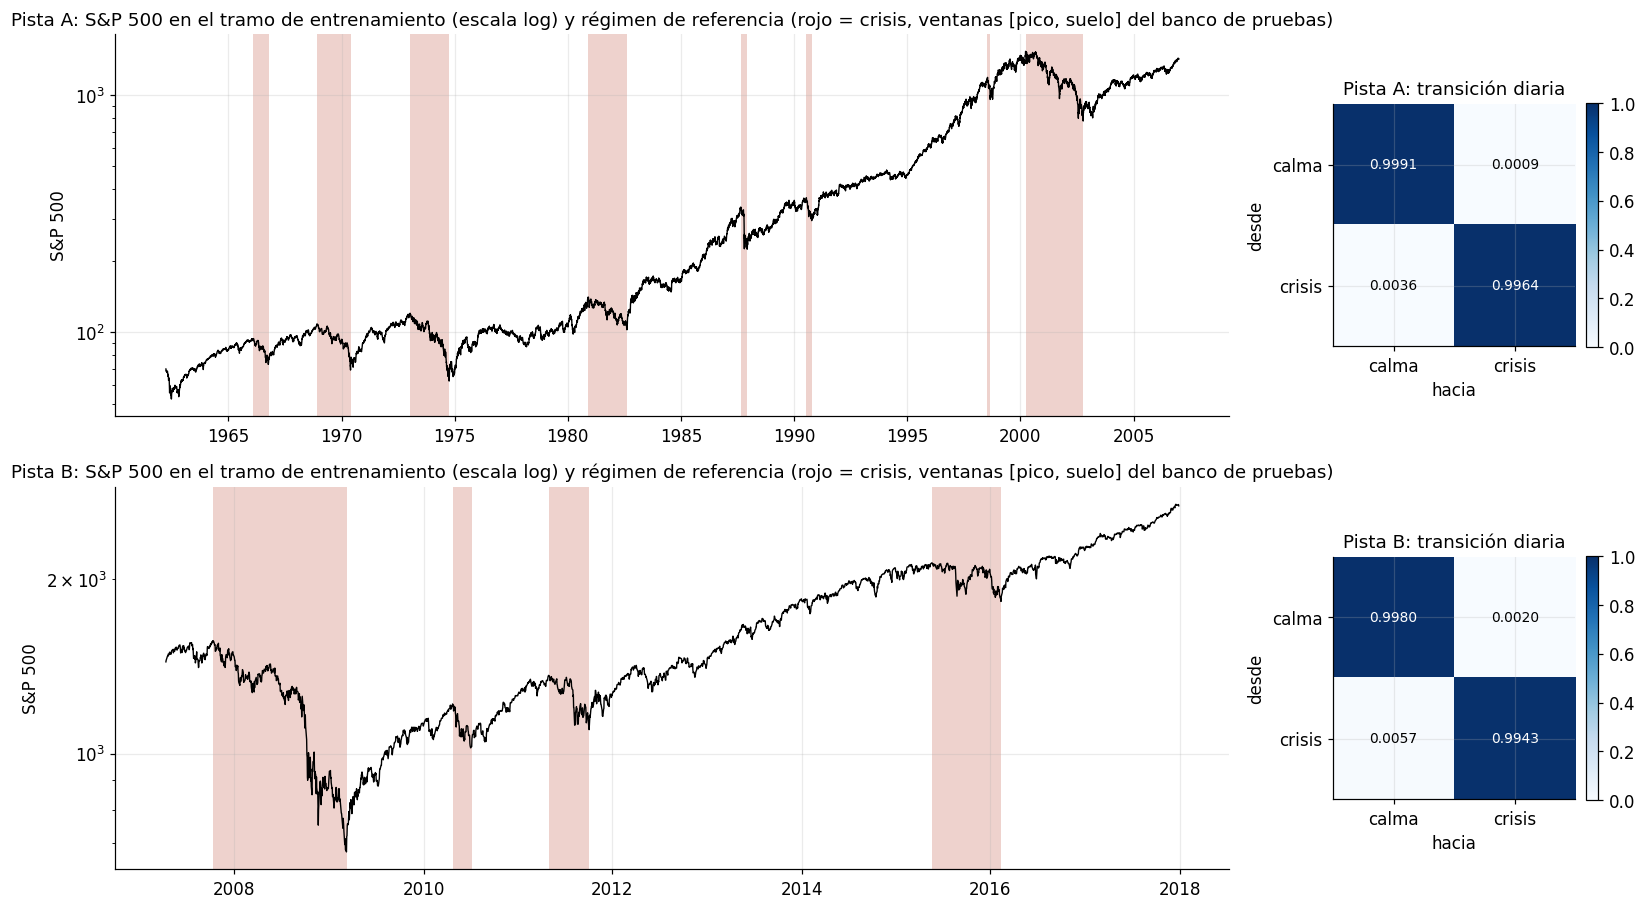

In [5]:
SP500 = inf.precio_sp500()
fig = plt.figure(figsize=(15, 4.2 * len(PISTAS)))
gs = fig.add_gridspec(len(PISTAS), 2, width_ratios=[4.2, 1])
for i, t in enumerate(PISTAS):
    ax = fig.add_subplot(gs[i, 0])
    precio = SP500.loc[PANEL[t].index[0]:PANEL[t].index[-1]]
    ax.plot(precio.index, precio.values, color='black', lw=0.9)
    ax.set_yscale('log')
    viz.shade_regime(ax, REG[t], 1, color=viz.C_CRISIS, alpha=0.22)
    ax.set_title(f'Pista {t}: S&P 500 en el tramo de entrenamiento (escala log) y régimen de referencia '
                 f'(rojo = crisis, ventanas [pico, suelo] del banco de pruebas)')
    ax.set_ylabel('S&P 500')
    ax_p = fig.add_subplot(gs[i, 1])
    viz.plot_transition_matrix(P_TRANS[t], labels=['calma', 'crisis'], ax=ax_p, title=f'Pista {t}: transición diaria')
    # con dos decimales todas las celdas se leen 1.00 / 0.00: se anotan con los decimales que las distinguen
    for texto, p in zip(ax_p.texts, P_TRANS[t].ravel()):
        texto.set_text(f'{p:.4f}')
fig.tight_layout(); guardar(fig, 'train_regimen_referencia'); plt.show()

In [6]:
lineas = []
for t in PISTAS:
    d, ep = DATOS_TRAIN.loc[t], EPISODIOS[t]
    crisis = RACHAS[t].loc[RACHAS[t]['regimen'] == 1, 'duracion']
    lineas.append(
        f"- **Pista {t}**: {d['sesiones']} sesiones ({d['primera fila']} → {d['última fila']}), "
        f"{d['columnas']} columnas, {d['filas posteriores al corte']} filas posteriores al corte y "
        f"{d['episodios partidos por el corte']} episodios partidos. {d['episodios de crisis en train']} episodios "
        f"de crisis que ocupan el {fmt(d['% de días de crisis'], 1)} % de los días; duran entre {crisis.min()} y "
        f"{crisis.max()} sesiones (mediana {fmt(crisis.median(), 0)}), frente a una duración esperada por la matriz "
        f"de {fmt(1 / (1 - P_TRANS[t][1, 1]), 0)} sesiones en crisis y {fmt(1 / (1 - P_TRANS[t][0, 0]), 0)} en calma.")
md('**Lectura (cifras de las celdas anteriores).**', *lineas,
   '- La matriz de transición se estima con tantas transiciones como rachas: cada probabilidad de salida '
   'descansa en un puñado de sucesos, y la dispersión de las duraciones reales de crisis es mucho mayor de '
   'lo que una sola tasa de salida puede describir. Es la primera limitación de todo lo que sigue.')

**Lectura (cifras de las celdas anteriores).**
- **Pista A**: 11267 sesiones (1962-03-29 → 2006-12-29), 10 columnas, 0 filas posteriores al corte y 0 episodios partidos. 8 episodios de crisis que ocupan el 19,6 % de los días; duran entre 32 y 638 sesiones (mediana 269), frente a una duración esperada por la matriz de 276 sesiones en crisis y 1132 en calma.
- **Pista B**: 2702 sesiones (2007-04-11 → 2017-12-29), 15 columnas, 0 filas posteriores al corte y 0 episodios partidos. 4 episodios de crisis que ocupan el 25,9 % de los días; duran entre 50 y 356 sesiones (mediana 146), frente a una duración esperada por la matriz de 175 sesiones en crisis y 500 en calma.
- La matriz de transición se estima con tantas transiciones como rachas: cada probabilidad de salida descansa en un puñado de sucesos, y la dispersión de las duraciones reales de crisis es mucho mayor de lo que una sola tasa de salida puede describir. Es la primera limitación de todo lo que sigue.

<a id="s2x"></a>
### 2.1 La cadena de régimen simulada

Cuando a `sample` no se le impone el régimen, la base común (`GeneradorBase`) simula una cadena
por trayectoria con `datos.simular_regimenes`. Hay dos decisiones, que se pasan como `dict`:

- **`inicial`**: `ultimo` (todas las trayectorias continúan el estado de la última fila de
  entrenamiento) o `estacionaria` (el estado de partida de cada trayectoria se sortea de la
  distribución estacionaria).
- **`duraciones`**: `geometricas` (cadena de Markov de primer orden con la matriz empírica) o
  `empiricas` (semi-Markov: cada racha dura una de las duraciones reales de las rachas de
  entrenamiento de su régimen, remuestreada con reemplazo).

La celda compara los cuatro modos en las dos pistas. Para cada uno mide, con el sorteo que
realmente se usa (mismas trayectorias, longitud y semilla que el muestreo de §6), el porcentaje de
días de crisis con su error estándar entre trayectorias y el número de trayectorias sin ninguna
crisis; y, con un número grande de trayectorias, los valores esperados y la distribución de
duraciones de las rachas de crisis completas (las que no tocan los extremos de la trayectoria),
que se enfrenta a las duraciones reales.

In [7]:
N_GRANDE = 2000   # trayectorias para estimar valores esperados de la cadena (solo regímenes: barato)


def simular_regimenes(t, n_paths, inicial, duraciones, semilla=SEMILLA):
    """La misma llamada que hace GeneradorBase.sample con regimes={'inicial': ..., 'duraciones': ...}."""
    return datos.simular_regimenes(
        n_paths, LENGTH, np.random.default_rng(semilla), P_TRANS[t], RACHAS[t],
        inicial=inicial, duraciones=duraciones, ultimo=int(REG[t].iloc[-1]), frecuencia=FREC[t])


def rachas_matriz(R, k=1):
    """Duraciones de las rachas del régimen k de cada fila de R y si son completas (no tocan los extremos)."""
    durs, completas = [], []
    for fila in R:
        cortes = np.flatnonzero(np.diff(fila) != 0) + 1
        ini, fin = np.r_[0, cortes], np.r_[cortes, fila.size]
        sel = fila[ini] == k
        durs.append((fin - ini)[sel])
        completas.append(((ini > 0) & (fin < fila.size))[sel])
    return np.concatenate(durs), np.concatenate(completas)


filas, DUR_SIM = [], {}
for t in PISTAS:
    reales = RACHAS[t].loc[RACHAS[t]['regimen'] == 1, 'duracion'].to_numpy()
    filas.append({'pista': t, 'inicial': 'REAL (train)', 'duraciones': '', '% crisis (sorteo)': 100 * FREC[t][1],
                  'rachas de crisis: media': reales.mean(), 'mediana': np.median(reales), 'máxima': reales.max()})
    for inicial in datos.INICIALES:
        for duraciones in datos.DURACIONES:
            R = simular_regimenes(t, N_PATHS, inicial, duraciones)
            por_tray = 100 * R.mean(axis=1)
            G = simular_regimenes(t, N_GRANDE, inicial, duraciones, semilla=SEMILLA + 1)
            dur, completa = rachas_matriz(G)
            DUR_SIM[(t, inicial, duraciones)] = dur[completa]
            filas.append({
                'pista': t, 'inicial': inicial, 'duraciones': duraciones,
                '% crisis (sorteo)': por_tray.mean(), 'error estándar': por_tray.std(ddof=1) / np.sqrt(N_PATHS),
                'trayectorias sin crisis (sorteo)': int((R == 0).all(axis=1).sum()),
                '% crisis esperado': 100 * G.mean(), '% trayectorias sin crisis esperado': 100 * (G == 0).all(axis=1).mean(),
                'rachas de crisis: media': dur[completa].mean(), 'mediana': np.median(dur[completa]),
                'máxima': dur[completa].max(),
                '% rachas más largas que la mayor real': 100 * (dur[completa] > reales.max()).mean(),
            })
CADENA = pd.DataFrame(filas).set_index(['pista', 'inicial', 'duraciones'])
display(CADENA.style.format('{:.1f}', na_rep='—').format(
    {'trayectorias sin crisis (sorteo)': '{:.0f}', 'rachas de crisis: media': '{:.0f}', 'mediana': '{:.0f}',
     'máxima': '{:.0f}'}, na_rep='—'))
print(f'«sorteo» = {N_PATHS} trayectorias x {LENGTH} sesiones con la semilla {SEMILLA} (el muestreo de §6); '
      f'«esperado» y duraciones = {N_GRANDE} trayectorias con la semilla {SEMILLA + 1}.')

# La cadena que comparten todos los generadores en §6 (misma semilla => mismo sorteo de regímenes).
REG_SIM = {t: simular_regimenes(t, N_PATHS, **OPC_CADENA) for t in PISTAS}

«sorteo» = 100 trayectorias x 2520 sesiones con la semilla 42 (el muestreo de §6); «esperado» y duraciones = 2000 trayectorias con la semilla 43.


figura -> results/sinteticos/generadores/cadena_duraciones_crisis.png


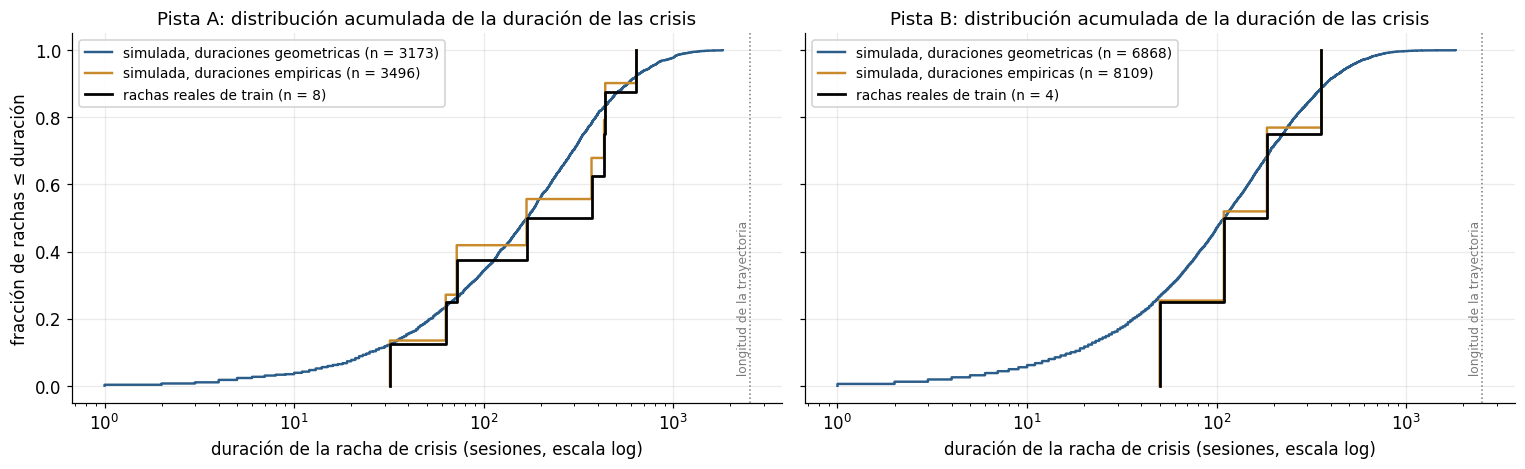

In [8]:
fig, axes = plt.subplots(1, len(PISTAS), figsize=(14, 4.4), sharey=True)
for ax, t in zip(np.atleast_1d(axes), PISTAS):
    reales = np.sort(RACHAS[t].loc[RACHAS[t]['regimen'] == 1, 'duracion'].to_numpy())
    for duraciones, color in (('geometricas', viz.C_LONG), ('empiricas', viz.C_SHORT)):
        d = np.sort(DUR_SIM[(t, OPC_CADENA['inicial'], duraciones)])
        ax.step(d, np.arange(1, d.size + 1) / d.size, where='post', color=color, lw=1.6,
                label=f'simulada, duraciones {duraciones} (n = {d.size})')
    ax.step(np.r_[reales[0], reales], np.r_[0, np.arange(1, reales.size + 1) / reales.size], where='post',
            color='black', lw=1.8, label=f'rachas reales de train (n = {reales.size})')
    ax.axvline(LENGTH, color=viz.C_NEG, ls=':', lw=1)
    ax.text(LENGTH, 0.02, ' longitud de la trayectoria', rotation=90, va='bottom', ha='right', fontsize=8, color=viz.C_NEG)
    ax.set_xscale('log'); ax.set_xlabel('duración de la racha de crisis (sesiones, escala log)')
    ax.set_title(f'Pista {t}: distribución acumulada de la duración de las crisis')
    ax.legend(loc='upper left', framealpha=0.9)
np.atleast_1d(axes)[0].set_ylabel('fracción de rachas ≤ duración')
fig.tight_layout(); guardar(fig, 'cadena_duraciones_crisis'); plt.show()

In [9]:
lineas = []
for t in PISTAS:
    real = CADENA.loc[(t, 'REAL (train)', '')]
    fila = lambda ini, dur: CADENA.loc[(t, ini, dur)]
    ug, eg, ee = fila('ultimo', 'geometricas'), fila('estacionaria', 'geometricas'), fila('estacionaria', 'empiricas')
    lineas.append(
        f"- **Pista {t}** (train: {fmt(real['% crisis (sorteo)'], 1)} % de días de crisis). Con `ultimo` + "
        f"`geometricas` el sorteo da {fmt(ug['% crisis (sorteo)'], 1)} ± {fmt(ug['error estándar'], 1)} % de crisis "
        f"(esperado {fmt(ug['% crisis esperado'], 1)} %) y {int(ug['trayectorias sin crisis (sorteo)'])} trayectorias "
        f"sin crisis; con `estacionaria` + `geometricas`, {fmt(eg['% crisis (sorteo)'], 1)} ± "
        f"{fmt(eg['error estándar'], 1)} % (esperado {fmt(eg['% crisis esperado'], 1)} %) y "
        f"{int(eg['trayectorias sin crisis (sorteo)'])} sin crisis ({fmt(eg['% trayectorias sin crisis esperado'], 1)} % "
        f"esperado); con `estacionaria` + `empiricas`, {fmt(ee['% crisis (sorteo)'], 1)} ± {fmt(ee['error estándar'], 1)} % "
        f"(esperado {fmt(ee['% crisis esperado'], 1)} %) y {int(ee['trayectorias sin crisis (sorteo)'])} sin crisis "
        f"({fmt(ee['% trayectorias sin crisis esperado'], 1)} % esperado). Las rachas geométricas tienen mediana "
        f"{fmt(eg['mediana'], 0)} y máxima {fmt(eg['máxima'], 0)} sesiones (reales: mediana {fmt(real['mediana'], 0)}, "
        f"máxima {fmt(real['máxima'], 0)}); el {fmt(eg['% rachas más largas que la mayor real'], 1)} % supera a la "
        f"crisis real más larga.")
elegido = f"`inicial: {OPC_CADENA['inicial']}` + `duraciones: {OPC_CADENA['duraciones']}`"
md('**Lectura y elección del yaml (cifras de la tabla).**', *lineas,
   f'- **Por qué {elegido}.** El arranque estacionario es el único que hace que la fracción esperada de crisis '
   'sea la de train en cualquier horizonte: continuar el último estado arranca todas las trayectorias en el mismo '
   'régimen (calma, en los dos cortes) y el porcentaje esperado de crisis y el de trayectorias sin ninguna se alejan '
   'de los de train (cifras arriba). Las '
   'duraciones geométricas son la opción que no se limita a repetir un puñado de duraciones observadas: producen '
   'crisis de cualquier duración, incluidas más cortas y más largas que las reales. Sus dos costes quedan medidos '
   'y no se ocultan: siguen saliendo trayectorias sin crisis (contadas en `diagnostico_muestreo()` y en §6; '
   'no sirven para evaluar detección) y la geométrica no reproduce la forma de la distribución real de '
   'duraciones (demasiadas crisis muy cortas y una cola de crisis más largas que ninguna observada). '
   '`empiricas` reduce las trayectorias sin crisis (ninguna calma real llena una trayectoria entera), pero no '
   'genera ninguna duración nueva y desplaza la fracción de crisis respecto a train (cifras arriba); queda '
   'disponible como opción de `sample` para el laboratorio de `17`.',
   '- El error estándar entre trayectorias recuerda que el porcentaje de crisis de un sorteo concreto es una '
   'variable aleatoria: todos los generadores comparten en §6 **el mismo sorteo de regímenes**, de modo que sus '
   'diferencias no se deben a la cadena, pero todas las cifras de §6 están condicionadas a ese sorteo.')

**Lectura y elección del yaml (cifras de la tabla).**
- **Pista A** (train: 19,6 % de días de crisis). Con `ultimo` + `geometricas` el sorteo da 15,8 ± 1,3 % de crisis (esperado 17,9 %) y 14 trayectorias sin crisis; con `estacionaria` + `geometricas`, 16,5 ± 1,4 % (esperado 19,9 %) y 14 sin crisis (8,3 % esperado); con `estacionaria` + `empiricas`, 20,9 ± 1,1 % (esperado 21,2 %) y 0 sin crisis (0,0 % esperado). Las rachas geométricas tienen mediana 169 y máxima 1822 sesiones (reales: mediana 269, máxima 638); el 7,6 % supera a la crisis real más larga.
- **Pista B** (train: 25,9 % de días de crisis). Con `ultimo` + `geometricas` el sorteo da 23,1 ± 1,2 % de crisis (esperado 24,3 %) y 2 trayectorias sin crisis; con `estacionaria` + `geometricas`, 24,8 ± 1,3 % (esperado 25,8 %) y 1 sin crisis (0,8 % esperado); con `estacionaria` + `empiricas`, 31,2 ± 1,1 % (esperado 30,5 %) y 0 sin crisis (0,0 % esperado). Las rachas geométricas tienen mediana 110 y máxima 1822 sesiones (reales: mediana 146, máxima 356); el 11,3 % supera a la crisis real más larga.
- **Por qué `inicial: estacionaria` + `duraciones: geometricas`.** El arranque estacionario es el único que hace que la fracción esperada de crisis sea la de train en cualquier horizonte: continuar el último estado arranca todas las trayectorias en el mismo régimen (calma, en los dos cortes) y el porcentaje esperado de crisis y el de trayectorias sin ninguna se alejan de los de train (cifras arriba). Las duraciones geométricas son la opción que no se limita a repetir un puñado de duraciones observadas: producen crisis de cualquier duración, incluidas más cortas y más largas que las reales. Sus dos costes quedan medidos y no se ocultan: siguen saliendo trayectorias sin crisis (contadas en `diagnostico_muestreo()` y en §6; no sirven para evaluar detección) y la geométrica no reproduce la forma de la distribución real de duraciones (demasiadas crisis muy cortas y una cola de crisis más largas que ninguna observada). `empiricas` reduce las trayectorias sin crisis (ninguna calma real llena una trayectoria entera), pero no genera ninguna duración nueva y desplaza la fracción de crisis respecto a train (cifras arriba); queda disponible como opción de `sample` para el laboratorio de `17`.
- El error estándar entre trayectorias recuerda que el porcentaje de crisis de un sorteo concreto es una variable aleatoria: todos los generadores comparten en §6 **el mismo sorteo de regímenes**, de modo que sus diferencias no se deben a la cadena, pero todas las cifras de §6 están condicionadas a ese sorteo.

<a id="s2y"></a>
### 2.2 Qué significa `regime = 1` en sintético

En los datos reales un episodio de crisis es, por definición, el tramo que va **de un pico a un
suelo** del S&P 500: la etiqueta lleva implícita una caída acumulada, sea cual sea la duración.
Los generadores no aprenden eso. Aprenden la **ley condicional de un día de crisis** —cómo es un
día cualquiera de los que cayeron dentro de alguna ventana— y en sintético `regime = 1` significa
exactamente eso: «día extraído de la ley condicional de crisis», no «día de un tramo pico→suelo».

La diferencia se ve con los propios episodios reales. Si la deriva diaria fuera una propiedad del
régimen, sería parecida en todos los episodios y la caída acumulada crecería en proporción a la
duración. La celda enfrenta la deriva media diaria de cada episodio real con su duración y la
compara con la deriva media del régimen (la que ve un generador que trata los días de crisis como
intercambiables).

figura -> results/sinteticos/generadores/semantica_regimen_deriva_duracion.png


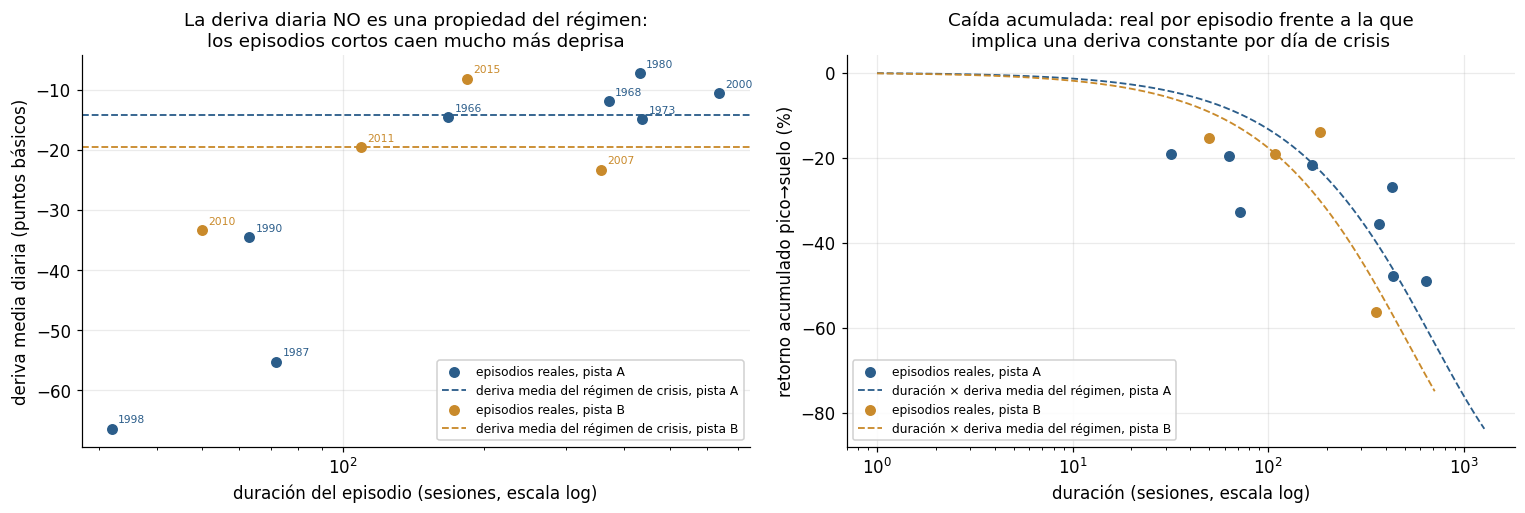

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.8))
DERIVA_CRISIS = {}
for t in PISTAS:
    ep = EPISODIOS[t]
    mu = float(PANEL[t].loc[REG[t] == 1, 'SP500_ret'].mean())
    DERIVA_CRISIS[t] = mu
    ax1.scatter(ep['sesiones'], ep['deriva media diaria (pb)'], color=C_PISTA[t], s=38, zorder=3,
                label=f'episodios reales, pista {t}')
    ax1.axhline(1e4 * mu, color=C_PISTA[t], ls='--', lw=1.2, label=f'deriva media del régimen de crisis, pista {t}')
    ax2.scatter(ep['sesiones'], ep['retorno acumulado (%)'], color=C_PISTA[t], s=38, zorder=3,
                label=f'episodios reales, pista {t}')
    d = np.arange(1, 2 * int(ep['sesiones'].max()))
    ax2.plot(d, 100 * np.expm1(mu * d), color=C_PISTA[t], ls='--', lw=1.2,
             label=f'duración × deriva media del régimen, pista {t}')
    for nombre, fila in ep.iterrows():
        ax1.annotate(str(fila['pico'].year), (fila['sesiones'], fila['deriva media diaria (pb)']),
                     textcoords='offset points', xytext=(4, 4), fontsize=7, color=C_PISTA[t])
ax1.set_xscale('log'); ax2.set_xscale('log')
ax1.set_xlabel('duración del episodio (sesiones, escala log)'); ax1.set_ylabel('deriva media diaria (puntos básicos)')
ax1.set_title('La deriva diaria NO es una propiedad del régimen:\nlos episodios cortos caen mucho más deprisa')
ax2.set_xlabel('duración (sesiones, escala log)'); ax2.set_ylabel('retorno acumulado pico→suelo (%)')
ax2.set_title('Caída acumulada: real por episodio frente a la que\nimplica una deriva constante por día de crisis')
ax1.legend(fontsize=8, framealpha=0.9, loc='lower right'); ax2.legend(fontsize=8, framealpha=0.9, loc='lower left')
fig.tight_layout(); guardar(fig, 'semantica_regimen_deriva_duracion'); plt.show()

In [11]:
lineas = []
for t in PISTAS:
    ep, mu = EPISODIOS[t], DERIVA_CRISIS[t]
    corr = np.corrcoef(np.log(ep['sesiones']), ep['deriva media diaria (pb)'])[0, 1]
    corto, largo = ep.loc[ep['sesiones'].idxmin()], ep.loc[ep['sesiones'].idxmax()]
    dur_sim, _ = rachas_matriz(REG_SIM[t])
    mas_larga = int(dur_sim.max())
    lineas.append(
        f"- **Pista {t}**: la deriva media diaria por episodio va de {fmt(ep['deriva media diaria (pb)'].min(), 1)} a "
        f"{fmt(ep['deriva media diaria (pb)'].max(), 1)} pb (correlación con el logaritmo de la duración: {fmt(corr)}); "
        f"la del régimen en conjunto es {fmt(1e4 * mu, 1)} pb. El episodio más corto ({corto.name}, {corto['sesiones']} "
        f"sesiones) cayó un {fmt(-corto['retorno acumulado (%)'], 1)} %; con la deriva del régimen habría caído un "
        f"{fmt(-100 * np.expm1(mu * corto['sesiones']), 1)} %. El más largo ({largo.name}, {largo['sesiones']} sesiones) "
        f"cayó un {fmt(-largo['retorno acumulado (%)'], 1)} %; con la deriva del régimen, un "
        f"{fmt(-100 * np.expm1(mu * largo['sesiones']), 1)} %. La caída real más profunda es del "
        f"{fmt(-ep['retorno acumulado (%)'].min(), 1)} %; la racha de crisis más larga del sorteo de §6 dura {mas_larga} "
        f"sesiones y, a la deriva del régimen, implica una caída esperada del {fmt(-100 * np.expm1(mu * mas_larga), 1)} %.")
md('**Lectura (cifras de la celda).**', *lineas,
   '- **Consecuencia.** Un generador condicionado a `regime` reproduce la deriva media de un día de crisis, no la '
   'caída pico→suelo de un episodio: una crisis sintética corta cae menos que una real de su duración, y una larga '
   '(las geométricas producen rachas más largas que cualquier crisis observada) acumula una caída que ningún '
   'episodio real alcanzó. La columna re-derivada `SP500_drawdown` lo hereda: los drawdowns sintéticos dependen de '
   'la duración sorteada, no de la definición de crisis. Se mide en §6 (mínimo de drawdown por trayectoria) y se '
   'declara como limitación en §7. No es un defecto de un generador concreto, sino del condicionamiento binario.')

**Lectura (cifras de la celda).**
- **Pista A**: la deriva media diaria por episodio va de -66,4 a -7,3 pb (correlación con el logaritmo de la duración: 0,91); la del régimen en conjunto es -14,3 pb. El episodio más corto (ltcm_russia_1998, 32 sesiones) cayó un 19,1 %; con la deriva del régimen habría caído un 4,5 %. El más largo (dotcom_2000_02, 638 sesiones) cayó un 49,1 %; con la deriva del régimen, un 59,8 %. La caída real más profunda es del 49,1 %; la racha de crisis más larga del sorteo de §6 dura 1070 sesiones y, a la deriva del régimen, implica una caída esperada del 78,3 %.
- **Pista B**: la deriva media diaria por episodio va de -33,4 a -8,2 pb (correlación con el logaritmo de la duración: 0,53); la del régimen en conjunto es -19,5 pb. El episodio más corto (flash_crash_euro1_2010, 50 sesiones) cayó un 15,4 %; con la deriva del régimen habría caído un 9,3 %. El más largo (gfc_2007_09, 356 sesiones) cayó un 56,4 %; con la deriva del régimen, un 50,0 %. La caída real más profunda es del 56,4 %; la racha de crisis más larga del sorteo de §6 dura 915 sesiones y, a la deriva del régimen, implica una caída esperada del 83,2 %.
- **Consecuencia.** Un generador condicionado a `regime` reproduce la deriva media de un día de crisis, no la caída pico→suelo de un episodio: una crisis sintética corta cae menos que una real de su duración, y una larga (las geométricas producen rachas más largas que cualquier crisis observada) acumula una caída que ningún episodio real alcanzó. La columna re-derivada `SP500_drawdown` lo hereda: los drawdowns sintéticos dependen de la duración sorteada, no de la definición de crisis. Se mide en §6 (mínimo de drawdown por trayectoria) y se declara como limitación en §7. No es un defecto de un generador concreto, sino del condicionamiento binario.

<a id="s3"></a>
## 3. Espacio de generación

Varias columnas del núcleo son **funciones deterministas de la senda del S&P 500**: el z-score del
retorno, el z-score de la volatilidad realizada, el momentum y el drawdown. Si un generador las
modelara como variables libres produciría paneles imposibles —un drawdown que no corresponde a los
retornos generados, una volatilidad realizada incoherente con ellos— y un detector vería una
inconsistencia que en datos reales no existe. Por eso los generadores trabajan en dos espacios
(`regimenes.sinteticos.espacio.EspacioGeneracion`):

- **Espacio de trabajo** (lo que se modela): el log-retorno crudo del S&P 500 más el resto de
  columnas, estandarizadas con la media y la desviación **solo del tramo de entrenamiento**.
- **Vuelta al espacio público** (lo que se entrega): se deshace la estandarización y las columnas
  deterministas se **re-derivan** con las mismas primitivas causales del preprocesado sobre
  [historia real del S&P 500 hasta el corte] + [retornos sintéticos]. Cada trayectoria es así una
  continuación hipotética del mercado tras el corte: su drawdown parte del máximo histórico real
  y sus z-scores expansivos, de la historia real.

La prueba de que la vuelta usa la misma receta que `03_preprocesado` es el **error de
re-derivación**: la diferencia máxima, sobre todo el tramo de entrenamiento, entre cada columna
real del panel y su re-derivación desde el precio crudo. Debe ser nula o del orden del redondeo.

In [12]:
UMBRAL_PERSISTENTE = 0.9     # autocorrelación a 1 día de train a partir de la cual una columna se trata como persistente
UMBRAL_ESCALON = 0.5         # fracción de días sin cambio a partir de la cual una columna se trata como escalón mensual

ESP, COLS_MOD, COLS_DER, PERSISTENTES, MENSUALES = {}, {}, {}, {}, {}
for t in PISTAS:
    esp = espacio.EspacioGeneracion()
    X = esp.ajustar(PANEL[t])
    ESP[t] = esp
    COLS_MOD[t], COLS_DER[t] = list(esp.columnas_trabajo_), list(esp.derivadas_)
    acf1 = PANEL[t].apply(lambda s: s.autocorr(1))
    sin_cambio = (PANEL[t].diff().iloc[1:] == 0).mean()
    PERSISTENTES[t] = [c for c in COLS_MOD[t] if acf1[c] > UMBRAL_PERSISTENTE]
    MENSUALES[t] = [c for c in COLS_MOD[t] if sin_cambio[c] > UMBRAL_ESCALON]
    tabla = pd.DataFrame({
        'papel': pd.Series(['re-derivada' if c in COLS_DER[t] else 'modelada' for c in PANEL[t].columns],
                           index=PANEL[t].columns),   # Serie con índice: una lista se alinearía por posición con el índice ordenado
        'error máx. de re-derivación': pd.Series(esp.error_rederivacion_),
        'media (train)': PANEL[t].mean(), 'desviación (train)': PANEL[t].std(ddof=0),
        'autocorr. a 1 día': acf1, 'días sin cambio': sin_cambio,
    }).reindex(PANEL[t].columns)
    tabla['clase'] = ['escalón mensual' if c in MENSUALES[t] else 'persistente' if c in PERSISTENTES[t]
                      else '' for c in tabla.index]
    display(Markdown(f'**Pista {t}** — {len(COLS_MOD[t])} columnas modeladas, {len(COLS_DER[t])} re-derivadas'))
    display(tabla.style.format({'error máx. de re-derivación': '{:.1e}', 'media (train)': '{:.4f}',
                                'desviación (train)': '{:.4f}', 'autocorr. a 1 día': '{:.3f}',
                                'días sin cambio': '{:.1%}'}, na_rep='—'))
    # --- estandarización solo con train y calendario sintético
    cols = COLS_MOD[t]
    assert np.allclose(esp.media_, PANEL[t][cols].mean().to_numpy()) and np.allclose(X.mean(axis=0), 0, atol=1e-9)
    assert np.allclose(X.std(axis=0), 1) and esp.historia_.index.max() == PANEL[t].index[-1]
    indice = esp.indice_sintetico(LENGTH)
    habiles = pd.bdate_range(PANEL[t].index[0], PANEL[t].index[-1])
    anios = (PANEL[t].index[-1] - PANEL[t].index[0]).days / 365.25
    print(f'Pista {t}: error máximo de re-derivación = {max(esp.error_rederivacion_.values()):.1e}; '
          f'estandarización con media/desviación de train (comprobado); historia de precios retenida hasta '
          f'{esp.historia_.index.max().date()}.')
    print(f'  calendario sintético: {indice[0].date()} → {indice[-1].date()} ({len(indice)} días hábiles de lunes a viernes, '
          f'{len(indice) / ((indice[-1] - indice[0]).days / 365.25):.1f} por año); el tramo real tiene '
          f'{len(PANEL[t]) / anios:.1f} sesiones por año: {(len(habiles) - len(PANEL[t])) / anios:.1f} días hábiles '
          f'por año del calendario sintético no son sesiones de mercado.')

**Pista A** — 6 columnas modeladas, 4 re-derivadas

,papel,error máx. de re-derivación,media (train),desviación (train),autocorr. a 1 día,días sin cambio,clase
SP500_ret_z,re-derivada,0.0e+00,0.0074,0.7605,0.069,0.0%,
SP500_vol_z,re-derivada,0.0e+00,-0.2276,0.6242,0.989,0.0%,
SP500_momentum,re-derivada,0.0e+00,0.0605,0.1443,0.996,0.0%,
SP500_drawdown,re-derivada,0.0e+00,-0.1095,0.1071,0.997,3.9%,
FF_MKT_z,modelada,—,-0.0065,0.8535,0.119,0.0%,
DGS10_change_z,modelada,—,0.0007,1.3359,0.141,1.1%,
credit_BaaAaa_mensual_z,modelada,—,-0.3269,0.5298,0.999,95.2%,escalón mensual
term_spread_hist_z,modelada,—,0.2240,1.3659,0.998,95.2%,escalón mensual
INDPRO_yoy_z,modelada,—,-0.1070,0.3225,0.999,95.2%,escalón mensual
SP500_ret,modelada,0.0e+00,0.0003,0.0094,0.076,0.0%,


Pista A: error máximo de re-derivación = 0.0e+00; estandarización con media/desviación de train (comprobado); historia de precios retenida hasta 2006-12-29.
  calendario sintético: 2007-01-01 → 2016-08-26 (2520 días hábiles de lunes a viernes, 261.1 por año); el tramo real tiene 251.8 sesiones por año: 9.2 días hábiles por año del calendario sintético no son sesiones de mercado.


**Pista B** — 11 columnas modeladas, 4 re-derivadas

,papel,error máx. de re-derivación,media (train),desviación (train),autocorr. a 1 día,días sin cambio,clase
SP500_ret_z,re-derivada,0.0e+00,0.0010,1.0615,-0.105,0.0%,
SP500_vol_z,re-derivada,0.0e+00,0.0862,1.0916,0.995,0.0%,
SP500_momentum,re-derivada,0.0e+00,0.0508,0.1782,0.995,0.0%,
SP500_drawdown,re-derivada,0.0e+00,-0.1227,0.1356,0.998,3.7%,
FF_MKT_z,modelada,—,0.0092,1.2059,-0.089,0.0%,
DGS10_change_z,modelada,—,-0.0075,0.8827,-0.017,0.8%,
credit_BaaAaa_mensual_z,modelada,—,-0.0731,0.7347,0.998,95.3%,escalón mensual
term_spread_hist_z,modelada,—,0.5889,0.7003,0.998,95.3%,escalón mensual
INDPRO_yoy_z,modelada,—,-0.3321,0.4372,0.999,95.3%,escalón mensual
VIX_level_z,modelada,—,0.0298,1.2882,0.981,0.0%,persistente


Pista B: error máximo de re-derivación = 0.0e+00; estandarización con media/desviación de train (comprobado); historia de precios retenida hasta 2017-12-29.
  calendario sintético: 2018-01-01 → 2027-08-27 (2520 días hábiles de lunes a viernes, 261.1 por año); el tramo real tiene 252.1 sesiones por año: 9.0 días hábiles por año del calendario sintético no son sesiones de mercado.


**Lectura.** El error de re-derivación que imprime la celda confirma que la vuelta al espacio
público reproduce las columnas del preprocesado: una trayectoria sintética es coherente por
construcción entre retorno, volatilidad realizada, momentum y drawdown. El precio de esa coherencia
es que las columnas re-derivadas **no las controla el generador**: son una función de muchas
sesiones de retornos (una ventana de volatilidad, un año de momentum, toda la senda para el
drawdown), de modo que cualquier defecto en la dinámica de `SP500_ret` —agrupamiento de
volatilidad, deriva por régimen— se amplifica en ellas. Por eso §6 mide por separado las columnas
modeladas y las re-derivadas.

**Calendario.** Las trayectorias se fechan con días hábiles de lunes a viernes a partir del
siguiente al corte, que **no es el calendario de la NYSE** (incluye los festivos de mercado; la
celda cuenta cuántos por año). Las fechas sintéticas son una etiqueta ordenada de sesiones, no
fechas de mercado: no deben cruzarse por fecha con datos reales (ni `join` ni `reindex` contra un
panel real); la comparación con el tramo real posterior se hace por posición o por distribución.

<a id="s4"></a>
## 4. Generadores paramétricos

Los generadores solo implementan dos métodos sobre matrices estandarizadas (`_fit` y `_sample`);
la validación de entradas, el espacio de generación, la cadena de regímenes, las semillas y la
persistencia son comunes (`GeneradorBase`). La celda siguiente define la mecánica que usan todas
las subsecciones de §4 y §5:

- `obtener(nombre, pista)`: carga el generador ajustado o, con `EJECUTAR = True`, lo ajusta y
  guarda modelo, ficha e historial.
- `muestrear(nombre, pista)`: carga o genera las trayectorias en los dos modos de §6 —cadena
  simulada con las opciones del yaml y una **secuencia impuesta común** a todos los generadores
  (calma, crisis corta, calma, crisis larga, calma)— con la semilla del proyecto.
- `procesar(nombre)`: hace ambas cosas en las dos pistas y calcula las métricas de sanidad de §6,
  de modo que las trayectorias no se quedan en memoria.

Cada subsección sigue el mismo guion: (a) idea y supuestos, (b) ajuste o carga con sus tiempos,
(c) el diagnóstico de convergencia **propio** del generador, leído desde su `historial`, y (d)
límites conocidos. El detalle se da en la pista principal; la secundaria entra con una tabla
compacta. Los barridos de los generadores paramétricos cuestan segundos y se recalculan siempre.

In [13]:
# ---------------------------------------------------------------- secuencia impuesta común
# Fracciones de la longitud: calma, crisis corta, calma, crisis larga, calma.
TRAMOS_IMPUESTOS = [(0, 0.20), (1, 0.025), (0, 0.275), (1, 0.20), (0, 0.30)]
limites = np.round(np.cumsum([0.0] + [f for _, f in TRAMOS_IMPUESTOS]) * LENGTH).astype(int)
SECUENCIA = np.concatenate([np.full(b - a, k, dtype=int) for (k, _), a, b in zip(TRAMOS_IMPUESTOS, limites[:-1], limites[1:])])
assert SECUENCIA.shape == (LENGTH,)
SEGMENTOS = [[int(k), int(b - a)] for (k, _), a, b in zip(TRAMOS_IMPUESTOS, limites[:-1], limites[1:])]
ESPEC_MUESTREO = {'n_paths': N_PATHS, 'length': LENGTH, 'semilla': SEMILLA, **OPC_CADENA, 'secuencia_impuesta': SEGMENTOS}
MODOS = {'simulada': dict(OPC_CADENA), 'impuesta': SECUENCIA}
FICHERO_TRAY = {'simulada': persistencia.FICHERO_TRAYECTORIAS, 'impuesta': 'trayectorias_impuesto.parquet'}
# comprobación corta de reproducibilidad: 2 trayectorias con una transición calma -> crisis
N_CONTROL = (2, 126)
SEC_CONTROL = np.r_[np.zeros(N_CONTROL[1] // 2, dtype=int), np.ones(N_CONTROL[1] - N_CONTROL[1] // 2, dtype=int)]
BANDA = (0.8, 1.25)   # banda de SANIDAD de los cocientes sintético/real (no es un umbral de admisión: eso es 16)

print('Secuencia impuesta (régimen, sesiones):', ', '.join(f'{ETIQ_REG[k]} {n}' for k, n in SEGMENTOS),
      f'→ {100 * SECUENCIA.mean():.1f} % de días de crisis')

GEN, ORIGEN, DIAG, SANIDAD, EJEMPLOS, DD_MIN, TIEMPOS, CONTRATO = {}, {}, {}, {}, {}, {}, {}, {}
INSTRUCCION = ('Pon EJECUTAR = True en la primera celda de código y ejecuta el notebook de arriba abajo: ajusta los '
               'generadores y guarda modelos, fichas y trayectorias (minutos en CPU).')


def carpeta_modelo(nombre, t):
    """data/sinteticos/<nombre>/pista<X>/ (modelo y trayectorias; gitignored)."""
    return persistencia.dir_trayectorias(nombre, t)


def ruta_ficha(nombre, t):
    return RES_DIR / f'{nombre}_pista{t}_resumen.json'


def vigente(gen, nombre, t):
    """El generador guardado corresponde a la configuración y a los datos actuales."""
    return (gen.params == {**registro.clase(nombre).PARAMS, **PARAMS[nombre]} and gen.random_state == SEMILLA
            and gen.fin_train_ == PANEL[t].index[-1] and gen.n_train_ == len(PANEL[t])
            and gen.columnas_ == list(PANEL[t].columns))


def obtener(nombre, t):
    """Generador ajustado de (nombre, pista): cargado de disco o, con EJECUTAR, ajustado y guardado."""
    clave = (t, nombre)
    if clave in GEN:
        return GEN[clave]
    ruta = carpeta_modelo(nombre, t) / FICHERO_MODELO
    gen = None
    if ruta.exists() and not (EJECUTAR and FORZAR):
        gen = registro.clase(nombre).cargar(ruta.parent)
        if not vigente(gen, nombre, t):
            if not EJECUTAR:
                raise RuntimeError(f'{rel(ruta)} no corresponde a configs/sinteticos.yaml ni a los datos actuales. '
                                   + INSTRUCCION)
            gen = None
    if gen is None:
        if not EJECUTAR:
            raise FileNotFoundError(f'Falta el generador ajustado {rel(ruta)}. ' + INSTRUCCION)
        gen = registro.crear(nombre, random_state=SEMILLA, **PARAMS[nombre])
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            gen.fit(PANEL[t], REG[t])
        gen.guardar(ruta.parent)
        persistencia.guardar_resumen(gen, t)   # ficha sin muestreo: invalida trayectorias anteriores
        ORIGEN[clave] = 'ajustado'
    else:
        ORIGEN[clave] = 'cargado'
    GEN[clave] = gen
    return gen


def control(gen):
    """Suma de control de una muestra corta con régimen impuesto y la semilla del proyecto."""
    tray = gen.sample(N_CONTROL[0], N_CONTROL[1], SEC_CONTROL, random_state=SEMILLA)
    return float(np.abs(np.stack([tr.to_numpy() for tr in tray])).sum())


def muestrear(nombre, t):
    """Trayectorias de los dos modos, su diagnóstico y sus tiempos: cargados o, con EJECUTAR, generados."""
    gen = obtener(nombre, t)
    ficha = json.loads(ruta_ficha(nombre, t).read_text(encoding='utf-8')) if ruta_ficha(nombre, t).exists() else {}
    destino = {m: carpeta_modelo(nombre, t) / f for m, f in FICHERO_TRAY.items()}
    al_dia = (ORIGEN[(t, nombre)] == 'cargado' and ficha.get('muestreo') == ESPEC_MUESTREO
              and all(r.exists() for r in destino.values()))
    if al_dia and not (EJECUTAR and FORZAR):
        tray = {'simulada': persistencia.cargar_trayectorias(nombre, t),
                'impuesta': persistencia.largo_a_trayectorias(pd.read_parquet(destino['impuesta']))}
        return tray, ficha['diagnostico_muestreo'], ficha['tiempo_muestreo_s'], ficha['control'], 'cargado'
    if not EJECUTAR:
        raise FileNotFoundError(f'Faltan las trayectorias de {nombre} (pista {t}) en {rel(carpeta_modelo(nombre, t))}, '
                                'o no corresponden al muestreo de configs/sinteticos.yaml. ' + INSTRUCCION)
    tray, diag, tiempos = {}, {}, {}
    for modo, regimenes in MODOS.items():
        ini = time.perf_counter()
        tray[modo] = gen.sample(N_PATHS, LENGTH, regimenes, random_state=SEMILLA)
        tiempos[modo] = time.perf_counter() - ini
        diag[modo] = gen.diagnostico_muestreo()
    persistencia.guardar_trayectorias(tray['simulada'], nombre, t)
    persistencia.trayectorias_a_largo(tray['impuesta']).to_parquet(destino['impuesta'], index=False)
    suma = control(gen)
    persistencia.guardar_resumen(gen, t, muestreo=ESPEC_MUESTREO, diagnostico_muestreo=diag,
                                 tiempo_muestreo_s=tiempos, control=suma)
    return tray, diag, tiempos, suma, 'generado'


# ---------------------------------------------------------------- referencias reales y métricas de sanidad
def a_cubo(tray, columnas):
    """Lista de trayectorias -> (valores (n_paths, length, n_columnas), regímenes (n_paths, length))."""
    return (np.stack([tr[columnas].to_numpy(dtype=float) for tr in tray]),
            np.stack([tr[datos.COL_REGIMEN].to_numpy() for tr in tray]))


def autocorr(x, retardo=1):
    """Autocorrelación al retardo dado de cada fila de x (n, T); NaN en filas constantes."""
    a, b = x[:, :-retardo], x[:, retardo:]
    a, b = a - a.mean(axis=1, keepdims=True), b - b.mean(axis=1, keepdims=True)
    den = np.sqrt((a * a).sum(axis=1) * (b * b).sum(axis=1))
    return np.divide((a * b).sum(axis=1), den, out=np.full(len(x), np.nan), where=den > 0)


def ventanas_reales(valores, largo, paso=252):
    """Ventanas de `largo` sesiones del tramo real cada `paso` sesiones: (n_ventanas, largo, ...)."""
    inicios = np.arange(0, max(len(valores) - largo, 0) + 1, paso)
    return np.stack([valores[i:i + largo] for i in inicios])


def momentos(V, R):
    """Media y desviación por régimen de un cubo (o de un panel 2-D con su régimen)."""
    return {k: (V[R == k].mean(axis=0), V[R == k].std(axis=0, ddof=1)) for k in (0, 1) if (R == k).any()}


REAL = {}
for t in PISTAS:
    cols = list(PANEL[t].columns)
    valores, reg = PANEL[t].to_numpy(), REG[t].to_numpy()
    ventanas = ventanas_reales(valores, LENGTH)
    ipers = [cols.index(c) for c in PERSISTENTES[t]]
    dd_ventana = PANEL[t]['SP500_drawdown'].rolling(LENGTH).min().dropna()
    REAL[t] = {
        'cols': cols, 'mom': momentos(valores, reg), 'n_ventanas': len(ventanas),
        'acf1_pers': float(np.mean([np.nanmean(autocorr(ventanas[:, :, i])) for i in ipers])),
        'sin_cambio': float(np.mean([(np.diff(valores[:, cols.index(c)]) == 0).mean() for c in MENSUALES[t]])),
        'dd_peor': float(PANEL[t]['SP500_drawdown'].min()), 'dd_ventana_mediana': float(dd_ventana.median()),
        'dd_ventanas': dd_ventana.to_numpy(), 'dd_final': float(PANEL[t]['SP500_drawdown'].iloc[-1]),
    }


def sanidad(tray, t):
    """Métricas de sanidad de una lista de trayectorias frente al tramo real de la pista."""
    cols, ref = REAL[t]['cols'], REAL[t]
    V, R = a_cubo(tray, cols)
    i = cols.index
    mom = momentos(V, R)
    out = {'finito': bool(np.isfinite(V).all()), 'frac_crisis': float((R == 1).mean()),
           'n_sin_crisis': int((R == 0).all(axis=1).sum())}
    for k, etiqueta in ETIQ_REG.items():
        if k not in mom:
            continue
        coc = pd.Series(mom[k][1] / ref['mom'][k][1], index=cols)
        mod = coc[COLS_MOD[t]]
        out.update({f'sd_mod_{etiqueta}': float(mod.median()), f'sd_mod_min_{etiqueta}': float(mod.min()),
                    f'sd_mod_max_{etiqueta}': float(mod.max()), f'sd_ret_{etiqueta}': float(coc['SP500_ret']),
                    f'sd_volz_{etiqueta}': float(coc['SP500_vol_z']), f'sd_mom_{etiqueta}': float(coc['SP500_momentum']),
                    f'sd_dd_{etiqueta}': float(coc['SP500_drawdown']),
                    f'ret_{etiqueta}_pb': float(1e4 * mom[k][0][i('SP500_ret')])})
        # media por régimen de las columnas modeladas, en desviaciones reales del régimen
        err = np.abs(mom[k][0] - ref['mom'][k][0]) / ref['mom'][k][1]
        out[f'err_media_{etiqueta}'] = float(pd.Series(err, index=cols)[COLS_MOD[t]].mean())
    if 0 in mom and 1 in mom:
        out['sep_vol'] = float(mom[1][1][i('SP500_ret')] / mom[0][1][i('SP500_ret')])
        out['sep_volz'] = float(mom[1][0][i('SP500_vol_z')] - mom[0][0][i('SP500_vol_z')])
    out['acf1_pers'] = float(np.mean([np.nanmean(autocorr(V[:, :, i(c)])) for c in PERSISTENTES[t]]))
    out['acf1_abs_ret'] = float(np.nanmean(autocorr(np.abs(V[:, :, i('SP500_ret')]))))
    out['sin_cambio'] = float(np.mean([(np.diff(V[:, :, i(c)], axis=1) == 0).mean() for c in MENSUALES[t]]))
    dd = V[:, :, i('SP500_drawdown')].min(axis=1)
    out.update({'dd_mediana': float(np.median(dd)), 'dd_peor': float(dd.min()),
                'pct_supera_real': float(100 * (dd < ref['dd_peor']).mean())})
    return out, dd, V, R


def fila_real(t):
    """Los mismos campos de `sanidad` medidos en el tramo real (cocientes = 1 por definición)."""
    ref, cols = REAL[t], REAL[t]['cols']
    i = cols.index
    out = {'finito': True, 'frac_crisis': float(FREC[t][1])}
    for k, etiqueta in ETIQ_REG.items():
        out.update({f'sd_{x}_{etiqueta}': 1.0 for x in ('mod', 'mod_min', 'mod_max', 'ret', 'volz', 'mom', 'dd')})
        out[f'ret_{etiqueta}_pb'] = float(1e4 * ref['mom'][k][0][i('SP500_ret')])
        out[f'err_media_{etiqueta}'] = 0.0
    out['sep_vol'] = float(ref['mom'][1][1][i('SP500_ret')] / ref['mom'][0][1][i('SP500_ret')])
    out['sep_volz'] = float(ref['mom'][1][0][i('SP500_vol_z')] - ref['mom'][0][0][i('SP500_vol_z')])
    ventanas = ventanas_reales(PANEL[t]['SP500_ret'].to_numpy(), LENGTH)
    out.update({'acf1_pers': ref['acf1_pers'], 'acf1_abs_ret': float(np.nanmean(autocorr(np.abs(ventanas)))),
                'sin_cambio': ref['sin_cambio'], 'dd_mediana': ref['dd_ventana_mediana'], 'dd_peor': ref['dd_peor']})
    return out


def procesar(nombre):
    """Obtiene y muestrea `nombre` en las dos pistas, guarda sus métricas de sanidad y devuelve el resumen de coste."""
    filas = []
    for t in PISTAS:
        gen = obtener(nombre, t)
        tray, diag, tiempos, suma, origen_tray = muestrear(nombre, t)
        for modo in MODOS:
            metricas, dd, V, R = sanidad(tray[modo], t)
            SANIDAD[(t, nombre, modo)], DIAG[(t, nombre, modo)] = metricas, diag[modo]
            if modo == 'simulada':
                DD_MIN[(t, nombre)] = dd
                cadena_comun = bool(np.array_equal(R, REG_SIM[t]))
            else:
                respetado = bool((R == SECUENCIA[None, :]).all())
                cols = REAL[t]['cols']
                EJEMPLOS[(t, nombre)] = {c: V[:3, :, cols.index(c)].copy() for c in ('SP500_drawdown', 'SP500_ret')}
        fechas_ok = all(tr.index[0] > PANEL[t].index[-1] and list(tr.columns) == REAL[t]['cols'] + [datos.COL_REGIMEN]
                        for m in MODOS for tr in tray[m][:3])
        # reproducibilidad: misma semilla => misma muestra; otra semilla => otra; y el generador cargado
        # reproduce la suma de control que dejó el que se ajustó
        a, b = control(gen), control(gen)
        otra = gen.sample(N_CONTROL[0], N_CONTROL[1], SEC_CONTROL, random_state=SEMILLA + 1)
        otra = float(np.abs(np.stack([tr.to_numpy() for tr in otra])).sum())
        CONTRATO[(t, nombre)] = {
            'regimen_respetado': respetado, 'cadena_compartida': cadena_comun, 'fechas_y_columnas': fechas_ok,
            'reproducible': bool(a == b and a != otra), 'control_coincide': bool(np.isclose(a, suma, rtol=1e-9, atol=0.0)),
        }
        TIEMPOS[(t, nombre)] = {'ajuste_s': float(gen.tiempo_ajuste_), 'muestreo_simulada_s': float(tiempos['simulada']),
                                'muestreo_impuesta_s': float(tiempos['impuesta'])}
        filas.append({'pista': t, 'generador': ORIGEN[(t, nombre)], 'trayectorias': origen_tray,
                      **TIEMPOS[(t, nombre)], 'finito': SANIDAD[(t, nombre, 'simulada')]['finito'],
                      **CONTRATO[(t, nombre)]})
        del tray
    return pd.DataFrame(filas).set_index('pista')


def historial(nombre, t):
    return GEN[(t, nombre)].historial


def historiales(nombre):
    """Historial de las dos pistas apilado (índice: pista)."""
    return pd.concat({t: historial(nombre, t) for t in PISTAS}, names=['pista']).reset_index(level=0)


# tramo común de los barridos paramétricos: las primeras trayectorias de la cadena compartida
N_BARRIDO = min(20, N_PATHS)
print(f'Barridos paramétricos: {N_BARRIDO} trayectorias x {LENGTH} sesiones de la cadena compartida, pista {PISTA_PRINCIPAL}.')

Secuencia impuesta (régimen, sesiones): calma 504, crisis 63, calma 693, crisis 504, calma 756 → 22.5 % de días de crisis
Barridos paramétricos: 20 trayectorias x 2520 sesiones de la cadena compartida, pista A.


<a id="s4-1"></a>
### 4.1 `jitter` — tramos reales más ruido

**(a) Idea y supuestos.** Es el modelo más simple posible, «datos reales más ruido»: copia tramos
reales contiguos del régimen pedido (con la mecánica del bootstrap de §4.2, pero con bloques
largos) y suma a cada día ruido gaussiano independiente,

$$
\tilde x_t = x_{\tau(t)} + \sigma\, s \odot \varepsilon_t,\qquad \varepsilon_t \sim \mathcal N(0, I),
$$

donde $\tau(t)$ es el día real copiado y $s$ la desviación típica de cada columna en el tramo de
entrenamiento, de modo que $\sigma$ es relativa a la escala de cada columna. No supone nada sobre
la distribución: no aprende, perturba. Es una técnica estándar de aumento de datos en series
temporales (Um et al., 2017; Iwana y Uchida, 2021) sobre el bootstrap estacionario (Politis y
Romano, 1994). Su papel aquí es doble: **suelo de comparación** (un generador que no mejore a
«real más ruido» no ha aportado nada) y **control positivo de memorización** (memoriza por diseño:
si una métrica de `16` no lo marca como copia, la métrica no sirve).

In [14]:
display(procesar('jitter'))
display(historiales('jitter').set_index(['pista', 'regimen']).T)

,generador,trayectorias,ajuste_s,muestreo_simulada_s,muestreo_impuesta_s,finito,regimen_respetado,cadena_compartida,fechas_y_columnas,reproducible,control_coincide
pista,,,,,,,,,,,
A,cargado,cargado,0.001949,0.875315,0.885971,True,True,True,True,True,True
B,cargado,cargado,0.000843,0.990783,0.957769,True,True,True,True,True,True


pista                              A                         B            
regimen                            0            1            0           1
n_obs                    9056.000000  2211.000000  2003.000000  699.000000
n_rachas                    9.000000     8.000000     5.000000    4.000000
racha_media              1006.222222   276.375000   400.600000  174.750000
longitud_media             63.000000    63.000000    63.000000   63.000000
bloque_medio_efectivo      59.119078    51.257075    53.602441   44.448706
sigma                       0.100000     0.100000     0.100000    0.100000
desviacion_relativa         0.244949     0.244949     0.331662    0.331662
ruido_sobre_regimen         0.108447     0.084449     0.127240    0.089781
ruido_sobre_regimen_max     0.114403     0.098800     0.171054    0.166448

**(c) Diagnóstico propio: barrido de $\sigma$.** No hay nada que converja; el diagnóstico es la
elección de $\sigma$. Se barre en la pista principal y se miden, en el espacio de trabajo
estandarizado, dos cosas que tiran en sentidos opuestos: la **distancia de cada día sintético al
día real más cercano** (cuánto se aleja de la copia) y la **distorsión** de lo que se quería
conservar (correlaciones entre columnas dentro de cada régimen, autocorrelación de las columnas
persistentes, escalones mensuales). La referencia $\sigma\sqrt{d}$ es la distancia esperada de un
día perturbado a su original; el vecino más cercano nunca queda más lejos.

,distancia al real más cercano (mediana),percentil 5,referencia sigma·raíz(d),% de días a distancia 0,distorsión de correlaciones,autocorr. a 1 día (persistentes),días sin cambio (mensuales)
sigma,,,,,,,
0.000000,0.000000,0.000000,0.000000,100.0,0.021053,0.977351,93.5%
0.020000,0.046140,0.025394,0.048990,0.0,0.021062,0.976845,0.0%
0.050000,0.114192,0.062874,0.122474,0.0,0.021132,0.974300,0.0%
0.100000,0.216056,0.119885,0.244949,0.0,0.021509,0.965401,0.0%
0.200000,0.354977,0.191887,0.489898,0.0,0.023649,0.931590,0.0%
0.500000,0.636373,0.290449,1.224745,0.0,0.041516,0.750614,0.0%
1.000000,1.157646,0.455358,2.449490,0.0,0.088281,0.448203,0.0%


figura -> results/sinteticos/generadores/jitter_barrido_sigma.png


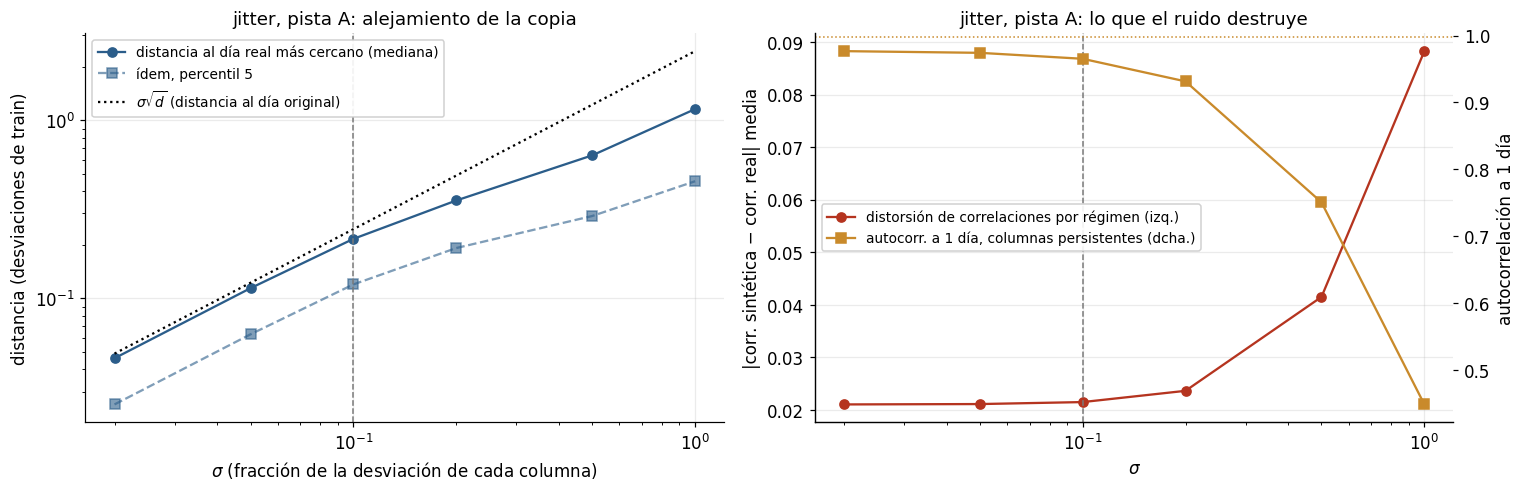

In [15]:
t = PISTA_PRINCIPAL
X_REAL = ESP[t].a_trabajo(PANEL[t])
arbol = cKDTree(X_REAL)
REG_BARRIDO = REG_SIM[t][:N_BARRIDO]
ipers = [COLS_MOD[t].index(c) for c in PERSISTENTES[t]]
imens = [COLS_MOD[t].index(c) for c in MENSUALES[t]]
reg_real = REG[t].to_numpy()


def distorsion_correlacion(Z, R):
    """Media, sobre regímenes, de |corr sintética - corr real| fuera de la diagonal (espacio de trabajo)."""
    fuera = ~np.eye(Z.shape[-1], dtype=bool)
    return float(np.mean([np.abs(np.corrcoef(Z[R == k], rowvar=False) - np.corrcoef(X_REAL[reg_real == k], rowvar=False))[fuera].mean()
                          for k in (0, 1)]))


sigma_yaml = float(PARAMS['jitter']['sigma'])
filas = []
for sigma in sorted({0.0, 0.02, 0.05, 0.1, 0.2, 0.5, 1.0, sigma_yaml}):
    g = registro.crear('jitter', random_state=SEMILLA, **{**PARAMS['jitter'], 'sigma': sigma}).fit(PANEL[t], REG[t])
    tray = g.sample(N_BARRIDO, LENGTH, REG_BARRIDO, random_state=SEMILLA)
    Z = np.stack([g.espacio_.a_trabajo(tr) for tr in tray])
    dist = arbol.query(Z.reshape(-1, Z.shape[-1]))[0]
    filas.append({
        'sigma': sigma, 'distancia al real más cercano (mediana)': np.median(dist), 'percentil 5': np.quantile(dist, 0.05),
        'referencia sigma·raíz(d)': sigma * np.sqrt(Z.shape[-1]), '% de días a distancia 0': 100 * (dist < 1e-12).mean(),
        'distorsión de correlaciones': distorsion_correlacion(Z, REG_BARRIDO),
        'autocorr. a 1 día (persistentes)': np.mean([np.nanmean(autocorr(Z[:, :, i])) for i in ipers]),
        'días sin cambio (mensuales)': np.mean([(np.diff(Z[:, :, i], axis=1) == 0).mean() for i in imens]),
    })
BARRIDO_JITTER = pd.DataFrame(filas).set_index('sigma')
ACF_PERS_BARRIDO = float(np.mean([np.nanmean(autocorr(ventanas_reales(X_REAL, LENGTH)[:, :, i])) for i in ipers]))
display(BARRIDO_JITTER.style.format('{:.3f}').format({'% de días a distancia 0': '{:.1f}', 'días sin cambio (mensuales)': '{:.1%}'}))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.6))
b = BARRIDO_JITTER[BARRIDO_JITTER.index > 0]
ax1.loglog(b.index, b['distancia al real más cercano (mediana)'], 'o-', color=viz.C_LONG, label='distancia al día real más cercano (mediana)')
ax1.loglog(b.index, b['percentil 5'], 's--', color=viz.C_LONG, alpha=0.6, label='ídem, percentil 5')
ax1.loglog(b.index, b['referencia sigma·raíz(d)'], ':', color='black', label=r'$\sigma\sqrt{d}$ (distancia al día original)')
ax1.set_xlabel(r'$\sigma$ (fracción de la desviación de cada columna)'); ax1.set_ylabel('distancia (desviaciones de train)')
ax1.set_title(f'jitter, pista {t}: alejamiento de la copia')
ax2.semilogx(b.index, b['distorsión de correlaciones'], 'o-', color=viz.C_CRISIS, label='distorsión de correlaciones por régimen (izq.)')
ax2.set_xlabel(r'$\sigma$'); ax2.set_ylabel('|corr. sintética − corr. real| media')
eje = ax2.twinx(); eje.grid(False)
eje.semilogx(b.index, b['autocorr. a 1 día (persistentes)'], 's-', color=viz.C_SHORT, label='autocorr. a 1 día, columnas persistentes (dcha.)')
eje.axhline(ACF_PERS_BARRIDO, color=viz.C_SHORT, ls=':', lw=1); eje.set_ylabel('autocorrelación a 1 día')
ax2.set_title(f'jitter, pista {t}: lo que el ruido destruye')
for ax in (ax1, ax2):
    ax.axvline(sigma_yaml, color=viz.C_NEG, ls='--', lw=1)
ax1.legend(loc='upper left', framealpha=0.9)
lineas_leyenda = ax2.get_legend_handles_labels(); otras = eje.get_legend_handles_labels()
ax2.legend(lineas_leyenda[0] + otras[0], lineas_leyenda[1] + otras[1], loc='center left', framealpha=0.9)
fig.tight_layout(); guardar(fig, 'jitter_barrido_sigma'); plt.show()

In [16]:
b0, by = BARRIDO_JITTER.loc[0.0], BARRIDO_JITTER.loc[sigma_yaml]
h = historial('jitter', PISTA_PRINCIPAL).set_index('regimen')
md(f'**Lectura (pista {PISTA_PRINCIPAL}; línea vertical = σ del yaml, {fmt(sigma_yaml)}).**',
   f"- Con σ = 0 el jitter es el bootstrap: el {fmt(b0['% de días a distancia 0'], 1)} % de los días sintéticos son "
   f"copias exactas de un día real. Con el σ del yaml la distancia mediana al día real más cercano es "
   f"{fmt(by['distancia al real más cercano (mediana)'], 3)} desviaciones (referencia σ√d = "
   f"{fmt(by['referencia sigma·raíz(d)'], 3)}): cada día sintético sigue pegado a un día real concreto, que es "
   f"exactamente lo que se quiere de un control de memorización.",
   f"- A ese σ la distorsión de correlaciones pasa de {fmt(b0['distorsión de correlaciones'], 3)} (suelo de muestreo, "
   f"σ = 0) a {fmt(by['distorsión de correlaciones'], 3)}, y la autocorrelación a 1 día de las columnas persistentes de "
   f"{fmt(b0['autocorr. a 1 día (persistentes)'], 3)} a {fmt(by['autocorr. a 1 día (persistentes)'], 3)} (real: "
   f"{fmt(ACF_PERS_BARRIDO, 3)}). Con el σ más alto del barrido caen a "
   f"{fmt(BARRIDO_JITTER['autocorr. a 1 día (persistentes)'].iloc[-1], 3)}: el ruido blanco se come la persistencia.",
   f"- **Resultado negativo, a cualquier σ > 0**: los escalones mensuales desaparecen. Los días sin cambio de las "
   f"columnas mensuales pasan del {fmt(100 * b0['días sin cambio (mensuales)'], 1)} % al "
   f"{fmt(100 * by['días sin cambio (mensuales)'], 1)} %, porque el ruido es independiente día a día.",
   f"- El ruido es relativo a la desviación de train, no a la del régimen: equivale a "
   f"{fmt(h.loc[0, 'ruido_sobre_regimen'], 3)} desviaciones propias en calma y {fmt(h.loc[1, 'ruido_sobre_regimen'], 3)} "
   f"en crisis (media entre columnas; `historial`). El bloque efectivo es de {fmt(h.loc[0, 'bloque_medio_efectivo'], 1)} "
   f"sesiones en calma y {fmt(h.loc[1, 'bloque_medio_efectivo'], 1)} en crisis, menor que el nominal porque un bloque "
   f"nunca cruza el final de una racha real.")

**Lectura (pista A; línea vertical = σ del yaml, 0,10).**
- Con σ = 0 el jitter es el bootstrap: el 100,0 % de los días sintéticos son copias exactas de un día real. Con el σ del yaml la distancia mediana al día real más cercano es 0,216 desviaciones (referencia σ√d = 0,245): cada día sintético sigue pegado a un día real concreto, que es exactamente lo que se quiere de un control de memorización.
- A ese σ la distorsión de correlaciones pasa de 0,021 (suelo de muestreo, σ = 0) a 0,022, y la autocorrelación a 1 día de las columnas persistentes de 0,977 a 0,965 (real: 0,998). Con el σ más alto del barrido caen a 0,448: el ruido blanco se come la persistencia.
- **Resultado negativo, a cualquier σ > 0**: los escalones mensuales desaparecen. Los días sin cambio de las columnas mensuales pasan del 93,5 % al 0,0 %, porque el ruido es independiente día a día.
- El ruido es relativo a la desviación de train, no a la del régimen: equivale a 0,108 desviaciones propias en calma y 0,084 en crisis (media entre columnas; `historial`). El bloque efectivo es de 59,1 sesiones en calma y 51,3 en crisis, menor que el nominal porque un bloque nunca cruza el final de una racha real.

**(d) Límites conocidos.** Memoriza por diseño y no genera configuraciones de mercado nuevas: solo
puntos en una bola alrededor de los observados. Hereda las costuras del bootstrap entre bloques,
rompe los escalones mensuales y añade a las columnas persistentes una componente sin
autocorrelación; el ruido sobre `SP500_ret` se acumula en el precio y, con él, en las columnas
re-derivadas.

<a id="s4-2"></a>
### 4.2 `bootstrap_regimen` — bootstrap estacionario condicionado a régimen

**(a) Idea y supuestos.** No ajusta ningún modelo: guarda la matriz de entrenamiento y rellena la
secuencia de régimen pedida con **bloques contiguos de días reales de ese mismo régimen**. El día
de inicio de cada bloque es uniforme entre los días reales del régimen y su longitud es geométrica
de media $\ell$,

$$
L \sim \mathrm{Geom}(p),\qquad p = 1/\ell,\qquad \mathbb E[L] = \ell,
$$

que es el bootstrap estacionario de Politis y Romano (1994); la longitud aleatoria evita el
artefacto de periodicidad de los bloques de longitud fija (Künsch, 1989), y la elección de $\ell$
es el compromiso clásico entre sesgo y varianza (Politis y White, 2004). A diferencia del original
no hay vuelta al principio de la muestra: un bloque nunca cruza el final de una racha real, porque
el día siguiente pertenece a otro régimen. Supone que, condicionado al régimen, el proceso es
estacionario (un día de una crisis es intercambiable con uno de otra) y que la dependencia
temporal relevante cabe en un bloque.

In [17]:
display(procesar('bootstrap_regimen'))
display(historiales('bootstrap_regimen').set_index(['pista', 'regimen']).T)

,generador,trayectorias,ajuste_s,muestreo_simulada_s,muestreo_impuesta_s,finito,regimen_respetado,cadena_compartida,fechas_y_columnas,reproducible,control_coincide
pista,,,,,,,,,,,
A,cargado,cargado,0.000854,0.931944,0.799026,True,True,True,True,True,True
B,cargado,cargado,0.000300,0.896445,0.856929,True,True,True,True,True,True


pista                            A                        B            
regimen                          0            1           0           1
n_obs                  9056.000000  2211.000000  2003.00000  699.000000
n_rachas                  9.000000     8.000000     5.00000    4.000000
racha_media            1006.222222   276.375000   400.60000  174.750000
longitud_media           21.000000    21.000000    21.00000   21.000000
bloque_medio_efectivo    20.582597    19.534692    19.95203   18.651985

**(c) Diagnóstico propio: barrido de la longitud media de bloque.** El único parámetro es $\ell$.
Bloques cortos recombinan más (más diversidad) pero cortan la dependencia temporal en cada
**costura** —el salto entre el último día de un bloque y el primero del siguiente—; bloques
largos la conservan a costa de repetir tramos enteros. Se mide, en la pista principal y con la
cadena compartida, la fracción de días que abren bloque y cuánta autocorrelación sobrevive:
la del valor absoluto del retorno (agrupamiento de volatilidad) a varios retardos y la de las
columnas persistentes, ambas como cociente sobre la real.

,fracción de costuras,bloque efectivo medido,"bloque efectivo (historial, calma)","bloque efectivo (historial, crisis)",% de días de train usados,autocorr. persistentes (coc.),autocorr. |ret| retardo 1 (coc.),autocorr. |ret| retardo 5 (coc.),autocorr. |ret| retardo 21 (coc.)
longitud media,,,,,,,,,
1,0.999861,1.0,1.0,1.0,98.7,0.032677,0.113852,0.098457,0.132659
5,0.201945,5.0,5.0,4.9,98.5,0.808729,0.885883,0.355192,0.189629
10,0.101608,9.8,9.9,9.7,98.3,0.899428,0.880823,0.586242,0.154160
21,0.049702,20.1,20.6,19.5,98.6,0.950905,0.931948,0.810950,0.506055
42,0.027868,35.9,40.3,36.5,96.9,0.971969,0.854028,0.823942,0.659557
63,0.018142,55.1,59.1,51.3,96.5,0.979368,0.880988,0.830041,0.711758
126,0.011374,87.9,110.5,85.6,96.1,0.987066,0.819445,0.845516,0.806412
252,0.007126,140.3,192.8,125.8,93.1,0.991152,0.875064,0.863166,0.930307


Autocorrelación real de |SP500_ret| (media de ventanas de la misma longitud): retardo 1: 0.190, retardo 5: 0.209, retardo 21: 0.118


figura -> results/sinteticos/generadores/bootstrap_barrido_longitud.png


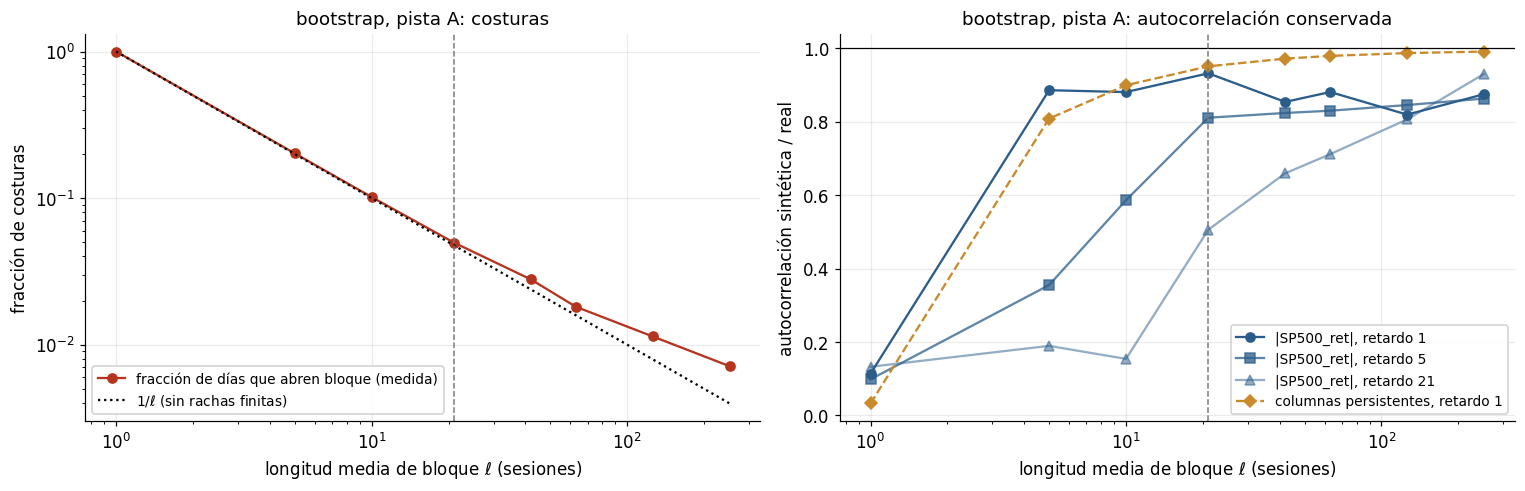

In [18]:
t = PISTA_PRINCIPAL
iret = COLS_MOD[t].index('SP500_ret')
RETARDOS = (1, 5, 21)
reales_v = ventanas_reales(X_REAL, LENGTH)
acf_abs_real = {k: float(np.nanmean(autocorr(np.abs(reales_v[:, :, iret]), k))) for k in RETARDOS}
l_yaml = float(PARAMS['bootstrap_regimen']['longitud_media'])
filas = []
for largo in sorted({1, 5, 10, 21, 42, 63, 126, 252, l_yaml}):
    g = registro.crear('bootstrap_regimen', random_state=SEMILLA, longitud_media=largo).fit(PANEL[t], REG[t])
    idx = g.muestrear_indices(REG_BARRIDO, np.random.default_rng(SEMILLA))
    Z = g.X_[idx]
    costura = np.diff(idx, axis=1) != 1
    hb = g.historial.set_index('regimen')['bloque_medio_efectivo']
    fila = {'longitud media': largo, 'fracción de costuras': costura.mean(), 'bloque efectivo medido': 1.0 / costura.mean(),
            'bloque efectivo (historial, calma)': hb[0], 'bloque efectivo (historial, crisis)': hb[1],
            '% de días de train usados': 100 * np.unique(idx).size / len(g.X_),
            'autocorr. persistentes (coc.)': np.mean([np.nanmean(autocorr(Z[:, :, i])) for i in ipers]) / ACF_PERS_BARRIDO}
    for k in RETARDOS:
        fila[f'autocorr. |ret| retardo {k} (coc.)'] = np.nanmean(autocorr(np.abs(Z[:, :, iret]), k)) / acf_abs_real[k]
    filas.append(fila)
BARRIDO_BOOT = pd.DataFrame(filas).set_index('longitud media')
display(BARRIDO_BOOT.style.format('{:.3f}').format({'bloque efectivo medido': '{:.1f}', '% de días de train usados': '{:.1f}',
                                                    'bloque efectivo (historial, calma)': '{:.1f}',
                                                    'bloque efectivo (historial, crisis)': '{:.1f}'}))
print('Autocorrelación real de |SP500_ret| (media de ventanas de la misma longitud):',
      ', '.join(f'retardo {k}: {v:.3f}' for k, v in acf_abs_real.items()))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.6))
ax1.loglog(BARRIDO_BOOT.index, BARRIDO_BOOT['fracción de costuras'], 'o-', color=viz.C_CRISIS, label='fracción de días que abren bloque (medida)')
ax1.loglog(BARRIDO_BOOT.index, 1.0 / BARRIDO_BOOT.index, ':', color='black', label=r'$1/\ell$ (sin rachas finitas)')
ax1.set_xlabel(r'longitud media de bloque $\ell$ (sesiones)'); ax1.set_ylabel('fracción de costuras')
ax1.set_title(f'bootstrap, pista {t}: costuras'); ax1.legend(framealpha=0.9)
for k, estilo in zip(RETARDOS, ('o-', 's-', '^-')):
    ax2.semilogx(BARRIDO_BOOT.index, BARRIDO_BOOT[f'autocorr. |ret| retardo {k} (coc.)'], estilo, color=viz.C_LONG,
                 alpha=1.0 - 0.25 * RETARDOS.index(k), label=f'|SP500_ret|, retardo {k}')
ax2.semilogx(BARRIDO_BOOT.index, BARRIDO_BOOT['autocorr. persistentes (coc.)'], 'D--', color=viz.C_SHORT, label='columnas persistentes, retardo 1')
ax2.axhline(1.0, color='black', lw=0.8)
ax2.set_xlabel(r'longitud media de bloque $\ell$ (sesiones)'); ax2.set_ylabel('autocorrelación sintética / real')
ax2.set_title(f'bootstrap, pista {t}: autocorrelación conservada'); ax2.legend(loc='lower right', framealpha=0.9)
for ax in (ax1, ax2):
    ax.axvline(l_yaml, color=viz.C_NEG, ls='--', lw=1)
fig.tight_layout(); guardar(fig, 'bootstrap_barrido_longitud'); plt.show()

In [19]:
by, b1, bmax = BARRIDO_BOOT.loc[l_yaml], BARRIDO_BOOT.iloc[0], BARRIDO_BOOT.iloc[-1]
k_largo = RETARDOS[-1]
md(f'**Lectura (pista {PISTA_PRINCIPAL}; línea vertical = ℓ del yaml, {fmt(l_yaml, 0)} sesiones).**',
   f"- Con el ℓ del yaml el {fmt(100 * by['fracción de costuras'], 1)} % de los días abre bloque (bloque efectivo de "
   f"{fmt(by['bloque efectivo medido'], 1)} sesiones; el `historial` predice {fmt(by['bloque efectivo (historial, calma)'], 1)} "
   f"en calma y {fmt(by['bloque efectivo (historial, crisis)'], 1)} en crisis) y se usa el "
   f"{fmt(by['% de días de train usados'], 1)} % de los días de train.",
   f"- Autocorrelación conservada con el ℓ del yaml, como cociente sobre la real: "
   + ', '.join(f"{fmt(by[f'autocorr. |ret| retardo {k} (coc.)'])} en |ret| a retardo {k}" for k in RETARDOS)
   + f" y {fmt(by['autocorr. persistentes (coc.)'], 3)} en las columnas persistentes. Con bloques de una sesión "
   f"(ℓ mínimo del barrido) el agrupamiento a retardo 1 queda en {fmt(b1['autocorr. |ret| retardo 1 (coc.)'])} y las "
   f"columnas persistentes en {fmt(b1['autocorr. persistentes (coc.)'], 3)}: lo que sobrevive entonces es solo la "
   f"diferencia de nivel entre regímenes.",
   f"- La dependencia a un retardo del orden del bloque es la que paga: a retardo {k_largo} el cociente es "
   f"{fmt(by[f'autocorr. |ret| retardo {k_largo} (coc.)'])} con el ℓ del yaml y {fmt(bmax[f'autocorr. |ret| retardo {k_largo} (coc.)'])} "
   f"con el ℓ máximo del barrido, a costa de usar solo el {fmt(bmax['% de días de train usados'], 1)} % de los días "
   f"(menos recombinación). El ℓ del yaml es un compromiso, no un óptimo estimado.")

**Lectura (pista A; línea vertical = ℓ del yaml, 21 sesiones).**
- Con el ℓ del yaml el 5,0 % de los días abre bloque (bloque efectivo de 20,1 sesiones; el `historial` predice 20,6 en calma y 19,5 en crisis) y se usa el 98,6 % de los días de train.
- Autocorrelación conservada con el ℓ del yaml, como cociente sobre la real: 0,93 en |ret| a retardo 1, 0,81 en |ret| a retardo 5, 0,51 en |ret| a retardo 21 y 0,951 en las columnas persistentes. Con bloques de una sesión (ℓ mínimo del barrido) el agrupamiento a retardo 1 queda en 0,11 y las columnas persistentes en 0,033: lo que sobrevive entonces es solo la diferencia de nivel entre regímenes.
- La dependencia a un retardo del orden del bloque es la que paga: a retardo 21 el cociente es 0,51 con el ℓ del yaml y 0,93 con el ℓ máximo del barrido, a costa de usar solo el 93,1 % de los días (menos recombinación). El ℓ del yaml es un compromiso, no un óptimo estimado.

**(d) Límites conocidos.** No crea días nuevos: el soporte de lo generado es el de entrenamiento y
en las métricas de memorización aparecerá como copia literal. Las columnas persistentes saltan en
cada costura y la primera fila no continúa el último día real. No reproduce la dinámica propia del
cambio de régimen (un bloque de crisis puede empezar en mitad de un episodio real) y, con tan pocos
episodios, las trayectorias largas repiten los mismos tramos de crisis.

<a id="s4-3"></a>
### 4.3 `gaussiano_regimen` — normal multivariante por régimen

**(a) Idea y supuestos.** La línea base de «solo segundo orden». Con las filas de cada régimen $k$
se estiman un vector de medias y una matriz de covarianzas, y cada día sintético es una extracción
independiente

$$
x_t \mid s_t = k \;\sim\; \mathcal N(\mu_k, \Sigma_k),\qquad
\hat\Sigma_k = (1-\delta_k)\,S_k + \delta_k\,\tfrac{\operatorname{tr}(S_k)}{d}\,I ,
$$

donde $S_k$ es la covarianza muestral y $\delta_k$ el peso de contracción de Ledoit y Wolf
(2004), estimado de los propios datos. Es la mezcla gaussiana con régimen de Markov de Hamilton
(1989) con el régimen observado. Supone normalidad e independencia temporal **dentro** de cada
régimen. Esa pobreza es su propósito: cuantifica cuánto de la fidelidad y de la utilidad aguas
abajo se explica solo con medias y covarianzas por régimen; lo que los demás ganen sobre él es
atribuible a dinámica o a colas.

In [20]:
display(procesar('gaussiano_regimen'))
HIST_GAUSS = historiales('gaussiano_regimen').assign(regimen=lambda d: d['regimen'].map(ETIQ_REG)).set_index(['pista', 'regimen'])
display(HIST_GAUSS.T)

,generador,trayectorias,ajuste_s,muestreo_simulada_s,muestreo_impuesta_s,finito,regimen_respetado,cadena_compartida,fechas_y_columnas,reproducible,control_coincide
pista,,,,,,,,,,,
A,cargado,cargado,0.548186,1.010973,0.894082,True,True,True,True,True,True
B,cargado,cargado,0.002069,0.958112,0.965223,True,True,True,True,True,True


pista                      A                        B             
regimen                calma      crisis        calma       crisis
n_obs                   9056        2211         2003          699
respaldo               False       False        False        False
shrinkage           0.003337    0.028429      0.01263     0.021719
cond_ledoit_wolf  126.411744   51.464911   215.740438   156.740222
cond_muestral     160.169009  121.227271  1286.123375  1192.355184
autovalor_min       0.013453    0.071778     0.010609     0.038537
saltos_cholesky            0           0            0            0

**(c) Diagnóstico propio: condicionamiento de la covarianza.** Tampoco aquí hay iteración: lo que
puede fallar es que la covarianza esté mal condicionada (columnas casi colineales, pocos días
efectivos en crisis) y el factor de Cholesky con el que se muestrea amplifique ruido. El historial
registra el número de condición de la covarianza muestral y de la contraída, el peso de
contracción y cuántos reintentos necesitó la factorización. La figura añade qué es lo que este
generador sabe del cambio de régimen: la diferencia de correlaciones entre crisis y calma.

figura -> results/sinteticos/generadores/gaussiano_condicionamiento.png


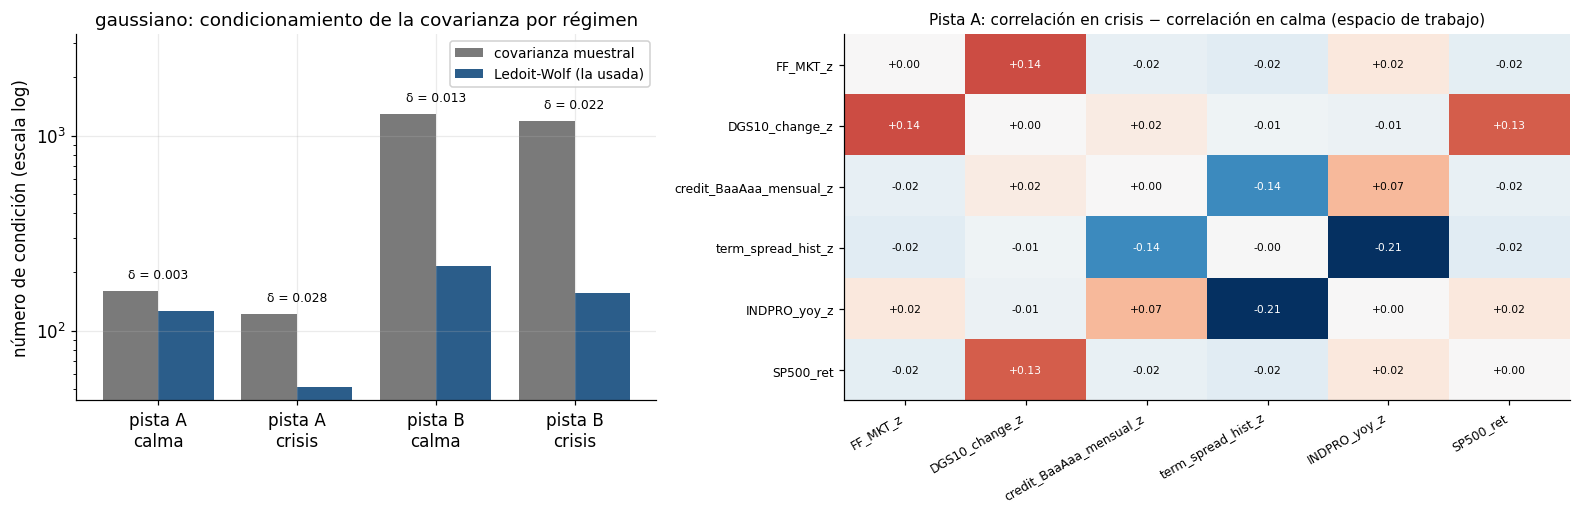

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14.5, 4.8), gridspec_kw={'width_ratios': [1, 1.25]})
pos = np.arange(len(HIST_GAUSS))
ax1.bar(pos - 0.2, HIST_GAUSS['cond_muestral'], 0.4, color=viz.C_NEG, label='covarianza muestral')
ax1.bar(pos + 0.2, HIST_GAUSS['cond_ledoit_wolf'], 0.4, color=viz.C_LONG, label='Ledoit-Wolf (la usada)')
ax1.set_yscale('log'); ax1.set_xticks(pos, [f'pista {a}\n{b}' for a, b in HIST_GAUSS.index])
for x, d, alto in zip(pos, HIST_GAUSS['shrinkage'], HIST_GAUSS[['cond_muestral', 'cond_ledoit_wolf']].max(axis=1)):
    ax1.text(x, alto * 1.12, f'δ = {d:.3f}', ha='center', va='bottom', fontsize=8)   # encima de las barras, no sobre ellas
ax1.set_ylim(top=ax1.get_ylim()[1] * 2.2)
ax1.set_ylabel('número de condición (escala log)'); ax1.set_title('gaussiano: condicionamiento de la covarianza por régimen')
ax1.legend(framealpha=0.9)
g = GEN[(PISTA_PRINCIPAL, 'gaussiano_regimen')]
desv = [np.sqrt(np.diag(g.cov_[k])) for k in (0, 1)]
corr = [g.cov_[k] / np.outer(desv[k], desv[k]) for k in (0, 1)]
inf.dibujar_heatmap(ax2, pd.DataFrame(corr[1] - corr[0], index=g.columnas_trabajo_, columns=g.columnas_trabajo_),
                    cmap='RdBu_r', vmin=None, vmax=None, fmt='{:+.2f}',
                    titulo=f'Pista {PISTA_PRINCIPAL}: correlación en crisis − correlación en calma (espacio de trabajo)')
ax2.grid(False); plt.setp(ax2.get_xticklabels(), rotation=30, ha='right')
fig.tight_layout(); guardar(fig, 'gaussiano_condicionamiento'); plt.show()

In [22]:
lineas = []
for (t, r), f in HIST_GAUSS.iterrows():
    lineas.append(f"- Pista {t}, {r}: {int(f['n_obs'])} días; contracción δ = {fmt(f['shrinkage'], 4)}; número de condición "
                  f"{fmt(f['cond_muestral'], 0)} (muestral) → {fmt(f['cond_ledoit_wolf'], 0)} (Ledoit-Wolf); "
                  f"{int(f['saltos_cholesky'])} reintentos de Cholesky; régimen de respaldo: {'sí' if f['respaldo'] else 'no'}.")
dif = pd.DataFrame(corr[1] - corr[0], index=g.columnas_trabajo_, columns=g.columnas_trabajo_).where(~np.eye(g.d_, dtype=bool)).stack()
par = dif.abs().idxmax()
md('**Lectura.**', *lineas,
   f"- La contracción es pequeña en todos los casos (muchos más días que dimensiones), pero no es inocua: mejora el "
   f"condicionamiento sobre todo donde la covarianza muestral está peor. Reintentos de la factorización de Cholesky: "
   f"como máximo {int(HIST_GAUSS['saltos_cholesky'].max())} (cero = la covarianza contraída factoriza sin ayuda).",
   f"- Lo único que este generador sabe del cambio de régimen son dos medias y dos covarianzas. En la pista "
   f"{PISTA_PRINCIPAL} la correlación que más cambia entre regímenes es la de `{par[0]}` con `{par[1]}` "
   f"({fmt(dif[par], 2)} de crisis menos calma).")

**Lectura.**
- Pista A, calma: 9056 días; contracción δ = 0,0033; número de condición 160 (muestral) → 126 (Ledoit-Wolf); 0 reintentos de Cholesky; régimen de respaldo: no.
- Pista A, crisis: 2211 días; contracción δ = 0,0284; número de condición 121 (muestral) → 51 (Ledoit-Wolf); 0 reintentos de Cholesky; régimen de respaldo: no.
- Pista B, calma: 2003 días; contracción δ = 0,0126; número de condición 1286 (muestral) → 216 (Ledoit-Wolf); 0 reintentos de Cholesky; régimen de respaldo: no.
- Pista B, crisis: 699 días; contracción δ = 0,0217; número de condición 1192 (muestral) → 157 (Ledoit-Wolf); 0 reintentos de Cholesky; régimen de respaldo: no.
- La contracción es pequeña en todos los casos (muchos más días que dimensiones), pero no es inocua: mejora el condicionamiento sobre todo donde la covarianza muestral está peor. Reintentos de la factorización de Cholesky: como máximo 0 (cero = la covarianza contraída factoriza sin ayuda).
- Lo único que este generador sabe del cambio de régimen son dos medias y dos covarianzas. En la pista A la correlación que más cambia entre regímenes es la de `term_spread_hist_z` con `INDPRO_yoy_z` (-0,21 de crisis menos calma).

**(d) Límites conocidos.** Dentro de cada régimen la curtosis es la gaussiana y la asimetría nula:
los extremos reales no aparecen nunca, solo inflan la varianza del régimen donde cayeron. No hay
ninguna dependencia temporal dentro de régimen: ni agrupamiento de volatilidad ni persistencia, de
modo que las columnas de nivel y las mensuales salen como ruido blanco alrededor de la media del
régimen (se mide en §6). La trayectoria no continúa desde el último día real.

<a id="s4-4"></a>
### 4.4 `var_regimen` — VAR por régimen observado

**(a) Idea y supuestos.** Dentro de cada régimen $k$ el panel estandarizado sigue un vector
autorregresivo con coeficientes propios,

$$
x_t = c_k + A_k\, x_{t-1} + e_t,\qquad s_t = k,
$$

que es el VAR con cambio de régimen de Hamilton (1989) y Krolzig (1997) con una diferencia que lo
simplifica todo: el régimen **no es latente**, así que no hace falta filtro ni EM; la
verosimilitud se separa por régimen y el estimador es de mínimos cuadrados, con una penalización
ridge pequeña cuya función es numérica (Lütkepohl, 2005, para la forma compañera y la condición de
estabilidad). Dos decisiones propias: (i) si el radio espectral de la matriz compañera alcanza el
máximo admitido, los coeficientes se contraen para que la simulación no explote; (ii) con
`anclar_media` la constante se fija como $c_k = (I - A_k)\,m_k$, de modo que el punto fijo del VAR
de cada régimen sea exactamente la media muestral $m_k$ del régimen. Las innovaciones se
remuestrean por filas enteras de los residuos reales del régimen, lo que conserva su dependencia
cruzada, sus colas y el carácter de las columnas mensuales (residuo casi siempre nulo y, de vez en
cuando, un salto).

In [23]:
from regimenes.sinteticos.parametricos.var_regimen import matriz_companera

display(procesar('var_regimen'))
HIST_VAR = historiales('var_regimen').assign(regimen=lambda d: d['regimen'].map(ETIQ_REG)).set_index(['pista', 'regimen'])
HIST_VAR['semivida (sesiones)'] = np.log(0.5) / np.log(HIST_VAR['radio_espectral'])
display(HIST_VAR.T)

,generador,trayectorias,ajuste_s,muestreo_simulada_s,muestreo_impuesta_s,finito,regimen_respetado,cadena_compartida,fechas_y_columnas,reproducible,control_coincide
pista,,,,,,,,,,,
A,cargado,cargado,0.00439,1.001484,0.846043,True,True,True,True,True,True
B,cargado,cargado,0.00225,0.931106,0.904960,True,True,True,True,True,True


pista                           A                      B            
regimen                     calma      crisis      calma      crisis
n_obs                        9047        2203       1998         695
n_dias                       9056        2211       2003         699
respaldo                    False       False      False       False
radio_original           0.998162    0.998198   0.996455    1.005356
radio_espectral          0.998162    0.998198   0.996455    0.998999
contraido                   False       False      False        True
factor_contraccion            1.0         1.0        1.0    0.993677
r2_medio                 0.505319    0.509925   0.635957    0.644354
r2_min                   0.007228    0.014513   0.008287    0.020035
desv_residuo_media       0.469773    0.694745   0.326039    0.587257
anclar_media                 True        True       True        True
desvio_punto_fijo_max         0.0         0.0        0.0         0.0
deriva_constante_max     0.002138    0.003328   0.004086    0.012448
saltos_cholesky                 0           0          0           0
semivida (sesiones)    376.860894  384.301326  195.20693  692.108094

**(c) Diagnóstico propio: estabilidad, ajuste y efecto de `anclar_media`.** El estimador es
cerrado; lo que hay que vigilar es (i) el **radio espectral** de cada régimen —por encima de uno la
simulación explota, y muy cerca de uno el ajuste hacia la media del régimen tarda más que la propia
racha—, (ii) el **R²** por columna (cuánta dinámica lineal hay que aprender) y (iii) qué hace la
constante. Para esto último se ajusta el mismo VAR con la opción contraria a la del yaml y se
comparan, con la cadena compartida, las medias por régimen de las columnas modeladas con las
reales (error en desviaciones reales del régimen).

figura -> results/sinteticos/generadores/var_estabilidad_y_ancla.png


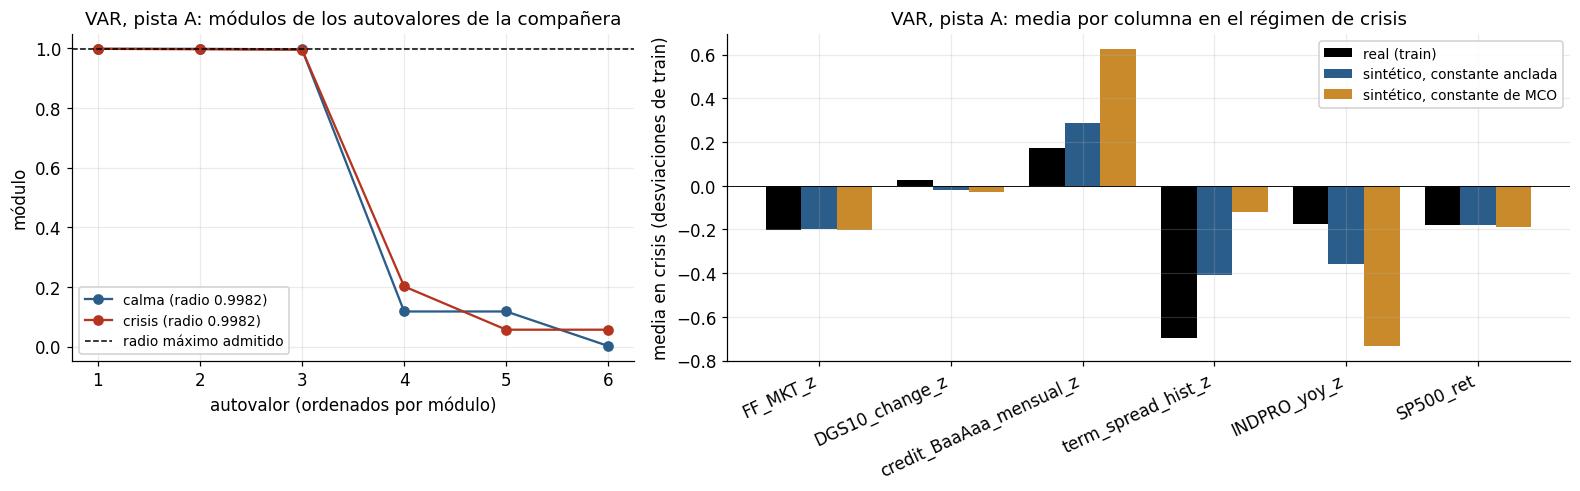

In [24]:
alterna = not bool(PARAMS['var_regimen'].get('anclar_media', True))
nombre_opc = {True: 'anclada', False: 'MCO'}
filas, MEDIAS_VAR = [], {}
for t in PISTAS:
    ref = momentos(ESP[t].a_trabajo(PANEL[t]), REG[t].to_numpy())
    for anclar in (not alterna, alterna):
        g = registro.crear('var_regimen', random_state=SEMILLA, **{**PARAMS['var_regimen'], 'anclar_media': anclar}).fit(PANEL[t], REG[t])
        tray = g.sample(N_BARRIDO, LENGTH, REG_SIM[t][:N_BARRIDO], random_state=SEMILLA)
        Z = np.stack([g.espacio_.a_trabajo(tr) for tr in tray])
        mom = momentos(Z, REG_SIM[t][:N_BARRIDO])
        h = g.historial.set_index('regimen')
        for k in (0, 1):
            MEDIAS_VAR[(t, nombre_opc[anclar], k)] = mom[k][0]
            filas.append({'pista': t, 'constante': nombre_opc[anclar] + (' (yaml)' if anclar != alterna else ''),
                          'régimen': ETIQ_REG[k],
                          'error de media (desv. del régimen)': np.mean(np.abs(mom[k][0] - ref[k][0]) / ref[k][1]),
                          'error de dispersión |log cociente|': np.mean(np.abs(np.log(mom[k][1] / ref[k][1]))),
                          'desvío máx. punto fijo − media': h.loc[k, 'desvio_punto_fijo_max']})
    MEDIAS_VAR[(t, 'real')] = ref
ANCLA_VAR = pd.DataFrame(filas).set_index(['pista', 'constante', 'régimen'])
display(ANCLA_VAR.unstack('régimen').style.format('{:.3f}'))

t = PISTA_PRINCIPAL
g = GEN[(t, 'var_regimen')]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14.5, 4.6), gridspec_kw={'width_ratios': [1, 1.5]})
for k, color in ((0, viz.C_LONG), (1, viz.C_CRISIS)):
    modulos = np.sort(np.abs(np.linalg.eigvals(matriz_companera(g.A_[k], int(g.orden)))))[::-1]
    ax1.plot(np.arange(1, modulos.size + 1), modulos, 'o-', color=color, label=f'{ETIQ_REG[k]} (radio {modulos[0]:.4f})')
ax1.axhline(float(g.radio_max), color='black', ls='--', lw=1, label='radio máximo admitido')
ax1.set_xlabel('autovalor (ordenados por módulo)'); ax1.set_ylabel('módulo')
ax1.set_title(f'VAR, pista {t}: módulos de los autovalores de la compañera'); ax1.legend(loc='lower left', framealpha=0.9)
pos = np.arange(len(COLS_MOD[t]))
ax2.bar(pos - 0.27, MEDIAS_VAR[(t, 'real')][1][0], 0.27, color='black', label='real (train)')
ax2.bar(pos, MEDIAS_VAR[(t, 'anclada', 1)], 0.27, color=viz.C_LONG, label='sintético, constante anclada')
ax2.bar(pos + 0.27, MEDIAS_VAR[(t, 'MCO', 1)], 0.27, color=viz.C_SHORT, label='sintético, constante de MCO')
ax2.set_xticks(pos, COLS_MOD[t], rotation=25, ha='right'); ax2.axhline(0, color='black', lw=0.6)
ax2.set_ylabel('media en crisis (desviaciones de train)')
ax2.set_title(f'VAR, pista {t}: media por columna en el régimen de crisis'); ax2.legend(framealpha=0.9)
fig.tight_layout(); guardar(fig, 'var_estabilidad_y_ancla'); plt.show()

In [25]:
lineas = []
for (t, r), f in HIST_VAR.iterrows():
    contr = (f"**contraído** desde {fmt(f['radio_original'], 4)}, factor {fmt(f['factor_contraccion'], 4)}"
             if f['contraido'] else 'sin contraer')
    lineas.append(f"- Pista {t}, {r}: radio espectral {fmt(f['radio_espectral'], 4)} ({contr}), semivida del ajuste "
                  f"{fmt(f['semivida (sesiones)'], 0)} sesiones; R² medio {fmt(f['r2_medio'])} y mínimo {fmt(f['r2_min'], 3)}; "
                  f"{int(f['n_obs'])} observaciones.")
filas_txt = []
for t in PISTAS:
    e = ANCLA_VAR.loc[t]['error de media (desv. del régimen)'].unstack('régimen')
    e.index = [i.replace(' (yaml)', '') for i in e.index]
    mejor = 'mejora' if e.loc['anclada', 'crisis'] < e.loc['MCO', 'crisis'] else 'EMPEORA'
    filas_txt.append(f"- Pista {t}: error de media en crisis {fmt(e.loc['anclada', 'crisis'], 3)} con la constante anclada "
                     f"frente a {fmt(e.loc['MCO', 'crisis'], 3)} con la de MCO (anclar {mejor}); en calma, "
                     f"{fmt(e.loc['anclada', 'calma'], 3)} frente a {fmt(e.loc['MCO', 'calma'], 3)}.")
cr = RACHAS[PISTA_PRINCIPAL].loc[RACHAS[PISTA_PRINCIPAL]['regimen'] == 1, 'duracion'].median()
md('**Lectura.**', *lineas,
   f"- Los radios están pegados a uno: las columnas de nivel y las mensuales son casi integradas. La semivida del "
   f"ajuste hacia el punto fijo es del orden de la duración de una crisis o mayor (mediana real en la pista "
   f"{PISTA_PRINCIPAL}: {fmt(cr, 0)} sesiones): tras un cambio de régimen las columnas persistentes **van hacia** la "
   f"media del nuevo régimen sin llegar a alcanzarla. La media sintética dentro de régimen no es, por tanto, la "
   f"muestral aunque el punto fijo lo sea.",
   f"- El R² mínimo, cercano a cero, es el del retorno y los cambios diarios: ahí el VAR no tiene casi nada que "
   f"predecir y reproduce la media del régimen sin problema; el R² medio lo sostienen las columnas persistentes.",
   '- **Efecto de `anclar_media`** (tabla y figura; cadena compartida):', *filas_txt,
   '- El resultado no es uniforme entre pistas ni entre regímenes y así se declara: anclar fija el punto fijo (desvío '
   'nulo en la tabla) pero elimina la deriva media dentro de la racha que la constante de MCO sí recoge. Se mantiene '
   'la opción del yaml en ambas pistas para no ajustar hiperparámetros por pista mirando el resultado.')

**Lectura.**
- Pista A, calma: radio espectral 0,9982 (sin contraer), semivida del ajuste 377 sesiones; R² medio 0,51 y mínimo 0,007; 9047 observaciones.
- Pista A, crisis: radio espectral 0,9982 (sin contraer), semivida del ajuste 384 sesiones; R² medio 0,51 y mínimo 0,015; 2203 observaciones.
- Pista B, calma: radio espectral 0,9965 (sin contraer), semivida del ajuste 195 sesiones; R² medio 0,64 y mínimo 0,008; 1998 observaciones.
- Pista B, crisis: radio espectral 0,9990 (**contraído** desde 1,0054, factor 0,9937), semivida del ajuste 692 sesiones; R² medio 0,64 y mínimo 0,020; 695 observaciones.
- Los radios están pegados a uno: las columnas de nivel y las mensuales son casi integradas. La semivida del ajuste hacia el punto fijo es del orden de la duración de una crisis o mayor (mediana real en la pista A: 269 sesiones): tras un cambio de régimen las columnas persistentes **van hacia** la media del nuevo régimen sin llegar a alcanzarla. La media sintética dentro de régimen no es, por tanto, la muestral aunque el punto fijo lo sea.
- El R² mínimo, cercano a cero, es el del retorno y los cambios diarios: ahí el VAR no tiene casi nada que predecir y reproduce la media del régimen sin problema; el R² medio lo sostienen las columnas persistentes.
- **Efecto de `anclar_media`** (tabla y figura; cadena compartida):
- Pista A: error de media en crisis 0,099 con la constante anclada frente a 0,258 con la de MCO (anclar mejora); en calma, 0,073 frente a 0,083.
- Pista B: error de media en crisis 0,192 con la constante anclada frente a 0,043 con la de MCO (anclar EMPEORA); en calma, 0,055 frente a 0,097.
- El resultado no es uniforme entre pistas ni entre regímenes y así se declara: anclar fija el punto fijo (desvío nulo en la tabla) pero elimina la deriva media dentro de la racha que la constante de MCO sí recoge. Se mantiene la opción del yaml en ambas pistas para no ajustar hiperparámetros por pista mirando el resultado.

**(d) Límites conocidos.** Las innovaciones son i.i.d. dado el régimen: no hay agrupamiento de
volatilidad dentro de régimen y toda la heterocedasticidad viene del cambio de régimen. La media
condicional es lineal. Los saltos de las columnas mensuales llegan en días al azar y el nivel
decae entre saltos, así que no son escalones. La dispersión incondicional de una columna casi
integrada depende de un coeficiente cercano a uno estimado con error, y la estabilidad está
garantizada régimen a régimen, no para productos arbitrarios de matrices de regímenes distintos.

<a id="s4-5"></a>
### 4.5 `garch_regimen` — GJR-GARCH-t con régimen observado

**(a) Idea y supuestos.** Es el único generador paramétrico que reproduce **dentro** de cada
régimen los tres hechos estilizados del retorno diario: agrupamiento de volatilidad,
apalancamiento y colas pesadas. El retorno de mercado sigue

$$
r_t = \mu_{s_t} + e_t,\quad e_t = \sqrt{h_t}\,z_t,\quad z_t \sim t_{\nu_{s_t}},\qquad
h_t = \omega_{s_t} + \big(\alpha_{s_t} + \gamma_{s_t}\,\mathbb 1\{e_{t-1}<0\}\big)\,e_{t-1}^2 + \beta_{s_t}\,h_{t-1},
$$

el GJR-GARCH de Glosten, Jagannathan y Runkle (1993) con innovación t de Student (Bollerslev,
1987) y **todos** los parámetros dependientes del régimen. Como el régimen es observado, la
varianza condicional es una única recursión que atraviesa los cambios de régimen y la
verosimilitud es exacta: no hace falta ni el colapso de la varianza de Gray (1996) ni las
recursiones en paralelo de Haas, Mittnik y Paolella (2004). El resto de columnas sigue un VAR por
régimen con el mercado contemporáneo como regresor, de modo que heredan su heterocedasticidad. La
persistencia de cada régimen es $\alpha + \gamma/2 + \beta$, acotada por debajo de uno. Dos
salvaguardas de simulación quedan declaradas y contadas: un **techo de varianza** (un cuantil alto
de la varianza filtrada en el propio régimen) y un techo de nivel por columna.

In [26]:
from regimenes.sinteticos.parametricos import garch_regimen as mod_garch

display(procesar('garch_regimen'))
HIST_GARCH = historiales('garch_regimen').assign(regimen=lambda d: d['regimen'].map(ETIQ_REG)).set_index(['pista', 'regimen'])
HIST_GARCH['semivida de un shock (sesiones)'] = np.log(0.5) / np.log(HIST_GARCH['persistencia'])
HIST_GARCH['vol. incondicional diaria (%)'] = 100 * HIST_GARCH['vol_incondicional_original']
HIST_GARCH['vol. diaria en el techo (%)'] = [
    100 * np.sqrt(f['techo_h']) * ESP[t].escala_[COLS_MOD[t].index('SP500_ret')] for (t, _), f in HIST_GARCH.iterrows()]
for modo in MODOS:
    HIST_GARCH[f'recorte de varianza, {modo} (% celdas)'] = [
        100 * DIAG[(t, 'garch_regimen', modo)]['fraccion_recorte_varianza_regimen'][0 if r == 'calma' else 1]
        for t, r in HIST_GARCH.index]
cols_garch = ['n_obs', 'origen', 'convergencia', 'mu', 'omega', 'alfa', 'gamma', 'beta', 'persistencia',
              'semivida de un shock (sesiones)', 'nu', 'vol. incondicional diaria (%)', 'vol. diaria en el techo (%)',
              'frac_train_sobre_techo', 'recorte de varianza, simulada (% celdas)', 'recorte de varianza, impuesta (% celdas)',
              'loglik_conjunta', 'loglik_conjunta_inicial', 'radio_espectral_var', 'radio_recortado', 'r2_var_medio']
display(HIST_GARCH[cols_garch].T)
RECORTES_GARCH = pd.DataFrame({(t, modo): {k: 100 * v for k, v in DIAG[(t, 'garch_regimen', modo)].items()
                                          if k.startswith('fraccion_recorte') and not isinstance(v, list)}
                               for t in PISTAS for modo in MODOS})
RECORTES_GARCH.columns.names = ['pista', 'cadena']
display(RECORTES_GARCH.style.format('{:.4f}').set_caption('Celdas que tocan cada techo al muestrear (% del total)'))

,generador,trayectorias,ajuste_s,muestreo_simulada_s,muestreo_impuesta_s,finito,regimen_respetado,cadena_compartida,fechas_y_columnas,reproducible,control_coincide
pista,,,,,,,,,,,
A,cargado,cargado,2.249707,1.117339,1.042840,True,True,True,True,True,True
B,cargado,cargado,0.450073,1.181838,1.150079,True,True,True,True,True,True


pista                                                A                          B             
regimen                                          calma        crisis        calma       crisis
n_obs                                             9056          2211         2003          699
origen                                        conjunto      conjunto     conjunto     conjunto
convergencia                                      True          True         True         True
mu                                            0.032122     -0.149633     0.038013    -0.133078
omega                                         0.004316      0.021589     0.013268     0.035395
alfa                                          0.029285           0.0          0.0          0.0
gamma                                         0.056742      0.162415     0.269429     0.214493
beta                                          0.936434      0.912141     0.844116     0.883537
persistencia                                  0.994091      0.993349      0.97883     0.990784
semivida de un shock (sesiones)             116.949729    103.869819    32.394831    74.861539
nu                                            7.783957     13.619432     5.016025    15.233743
vol. incondicional diaria (%)                 0.803095      1.693031     1.009355     2.498521
vol. diaria en el techo (%)                   2.105105      4.101251     2.078736      5.37414
frac_train_sobre_techo                        0.010049      0.010403     0.010484     0.010014
recorte de varianza, simulada (% celdas)      0.117422      0.062429     0.480526      0.20828
recorte de varianza, impuesta (% celdas)      0.120328       0.10582     0.432156     0.255732
loglik_conjunta                          -13817.033858 -13817.033858 -2866.546075 -2866.546075
loglik_conjunta_inicial                  -13827.263333 -13827.263333 -2875.409626 -2875.409626
radio_espectral_var                           0.998142      0.998258      0.99651        0.999
radio_recortado                                  False         False        False         True
r2_var_medio                                  0.804662      0.798999     0.810238     0.835341

**(c) Diagnóstico propio: parámetros por régimen, persistencia, colas y techo de varianza.** El
ajuste es de máxima verosimilitud; `origen` y `convergencia` dicen si el óptimo conjunto mejoró
el punto de partida y si el optimizador terminó bien. Lo interpretable son los parámetros: la
persistencia (y la semivida de un shock de volatilidad que implica), los grados de libertad de la
t y la asimetría $\gamma$. La figura muestra la volatilidad condicional **filtrada** en el tramo de
entrenamiento con la misma recursión que después se simula, el techo de cada régimen y la curva
de impacto de noticias (la varianza del día siguiente en función del shock de hoy).

figura -> results/sinteticos/generadores/garch_volatilidad_filtrada.png


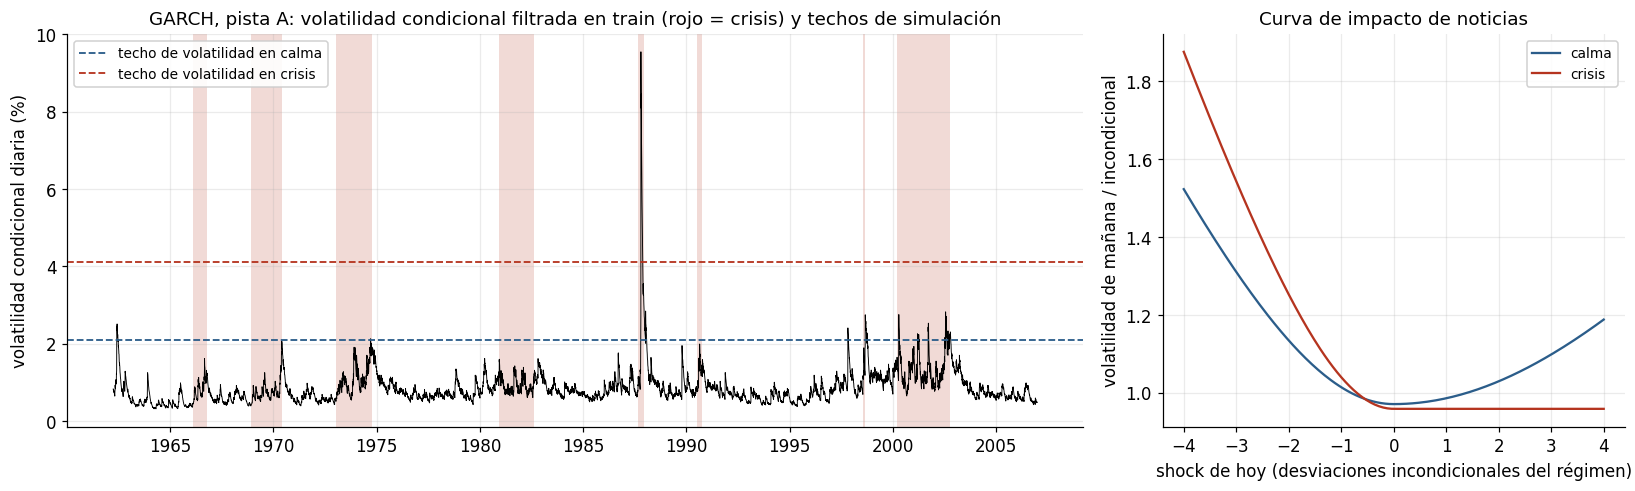

In [27]:
t = PISTA_PRINCIPAL
g = GEN[(t, 'garch_regimen')]
r_std = ESP[t].a_trabajo(PANEL[t])[:, g.i_mercado_]
reg_np = REG[t].to_numpy()
h_filtrada, _ = mod_garch._filtrar(r_std, reg_np, g.garch_, g._h0(r_std, reg_np))   # misma recursión que el generador
escala = 100 * float(ESP[t].escala_[g.i_mercado_])                                   # a % diario
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4.6), gridspec_kw={'width_ratios': [2.2, 1]})
ax1.plot(PANEL[t].index, escala * np.sqrt(h_filtrada), color='black', lw=0.6)
viz.shade_regime(ax1, REG[t], 1, color=viz.C_CRISIS, alpha=0.18)
for k, color in ((0, viz.C_LONG), (1, viz.C_CRISIS)):
    ax1.axhline(escala * np.sqrt(g.h_max_[k]), color=color, ls='--', lw=1.2, label=f'techo de volatilidad en {ETIQ_REG[k]}')
ax1.set_ylabel('volatilidad condicional diaria (%)'); ax1.legend(loc='upper left', framealpha=0.9)
ax1.set_title(f'GARCH, pista {t}: volatilidad condicional filtrada en train (rojo = crisis) y techos de simulación')
shock = np.linspace(-4, 4, 201)
for k, color in ((0, viz.C_LONG), (1, viz.C_CRISIS)):
    p = g.garch_[k]
    h_inc = p[mod_garch.OMEGA] / (1.0 - mod_garch._persistencia(p))
    e = shock * np.sqrt(h_inc)
    h_sig = p[mod_garch.OMEGA] + (p[mod_garch.ALFA] + p[mod_garch.GAMMA] * (e < 0)) * e ** 2 + p[mod_garch.BETA] * h_inc
    ax2.plot(shock, np.sqrt(h_sig / h_inc), color=color, label=ETIQ_REG[k])
ax2.set_xlabel('shock de hoy (desviaciones incondicionales del régimen)')
ax2.set_ylabel('volatilidad de mañana / incondicional'); ax2.legend(framealpha=0.9)
ax2.set_title('Curva de impacto de noticias')
fig.tight_layout(); guardar(fig, 'garch_volatilidad_filtrada'); plt.show()

In [28]:
lineas = []
for (t, r), f in HIST_GARCH.iterrows():
    lineas.append(
        f"- Pista {t}, {r}: α = {fmt(f['alfa'], 3)}, γ = {fmt(f['gamma'], 3)}, β = {fmt(f['beta'], 3)} → persistencia "
        f"{fmt(f['persistencia'], 4)} (semivida {fmt(f['semivida de un shock (sesiones)'], 0)} sesiones); ν = {fmt(f['nu'], 1)}; "
        f"volatilidad incondicional {fmt(f['vol. incondicional diaria (%)'])} % diario y techo en "
        f"{fmt(f['vol. diaria en el techo (%)'])} %; origen `{f['origen']}`, convergencia {'sí' if f['convergencia'] else 'NO'}; "
        f"el techo recorta el {fmt(f['recorte de varianza, simulada (% celdas)'], 3)} % de las celdas del régimen con la cadena "
        f"simulada y el {fmt(f['recorte de varianza, impuesta (% celdas)'], 3)} % con la impuesta.")
cota = float(PARAMS['garch_regimen'].get('persistencia_max', registro.clase('garch_regimen').PARAMS['persistencia_max']))
en_cota = [f'pista {t}, {r}' for (t, r), f in HIST_GARCH.iterrows() if f['persistencia'] > cota - 1e-4]
gana = HIST_GARCH.groupby(level='pista').first().eval('loglik_conjunta - loglik_conjunta_inicial')
md('**Lectura.**', *lineas,
   f"- La verosimilitud conjunta con régimen observado mejora a la del punto de partida (rachas concatenadas) en "
   + ' y '.join(f"{fmt(v, 1)} unidades logarítmicas en la pista {t}" for t, v in gana.items()) + '.',
   (f"- Persistencias en la cota ({fmt(cota, 3)}): {', '.join(en_cota)}. Ahí la restricción "
    f"está activa y el dato pediría un proceso más persistente."
    if en_cota else f"- Ninguna persistencia toca la cota ({fmt(cota, 3)}); la mayor es {fmt(HIST_GARCH['persistencia'].max(), 4)} y "
    f"la menor {fmt(HIST_GARCH['persistencia'].min(), 4)}: las semividas de un shock de volatilidad van de "
    f"{fmt(HIST_GARCH['semivida de un shock (sesiones)'].min(), 0)} a {fmt(HIST_GARCH['semivida de un shock (sesiones)'].max(), 0)} sesiones."),
   '- La asimetría γ domina a α en los regímenes donde α queda cerca de cero: la volatilidad reacciona a las caídas, '
   'apenas a las subidas (curva de impacto de noticias). Los grados de libertad miden el grosor de la cola '
   '*condicional*; un valor alto en crisis no dice que la crisis tenga colas finas, sino que la varianza '
   'condicional ya explica sus extremos.',
   '- El techo de varianza actúa en una fracción pequeña de las celdas (tabla de recortes), pero es una decisión de '
   'modelado, no un detalle numérico: por construcción el generador no produce volatilidad condicional por encima '
   'del cuantil elegido de su régimen en train. Si esas fracciones crecieran, el techo estaría haciendo de modelo.')

**Lectura.**
- Pista A, calma: α = 0,029, γ = 0,057, β = 0,936 → persistencia 0,9941 (semivida 117 sesiones); ν = 7,8; volatilidad incondicional 0,80 % diario y techo en 2,11 %; origen `conjunto`, convergencia sí; el techo recorta el 0,117 % de las celdas del régimen con la cadena simulada y el 0,120 % con la impuesta.
- Pista A, crisis: α = 0,000, γ = 0,162, β = 0,912 → persistencia 0,9933 (semivida 104 sesiones); ν = 13,6; volatilidad incondicional 1,69 % diario y techo en 4,10 %; origen `conjunto`, convergencia sí; el techo recorta el 0,062 % de las celdas del régimen con la cadena simulada y el 0,106 % con la impuesta.
- Pista B, calma: α = 0,000, γ = 0,269, β = 0,844 → persistencia 0,9788 (semivida 32 sesiones); ν = 5,0; volatilidad incondicional 1,01 % diario y techo en 2,08 %; origen `conjunto`, convergencia sí; el techo recorta el 0,481 % de las celdas del régimen con la cadena simulada y el 0,432 % con la impuesta.
- Pista B, crisis: α = 0,000, γ = 0,214, β = 0,884 → persistencia 0,9908 (semivida 75 sesiones); ν = 15,2; volatilidad incondicional 2,50 % diario y techo en 5,37 %; origen `conjunto`, convergencia sí; el techo recorta el 0,208 % de las celdas del régimen con la cadena simulada y el 0,256 % con la impuesta.
- La verosimilitud conjunta con régimen observado mejora a la del punto de partida (rachas concatenadas) en 10,2 unidades logarítmicas en la pista A y 8,9 unidades logarítmicas en la pista B.
- Ninguna persistencia toca la cota (0,995); la mayor es 0,9941 y la menor 0,9788: las semividas de un shock de volatilidad van de 32 a 117 sesiones.
- La asimetría γ domina a α en los regímenes donde α queda cerca de cero: la volatilidad reacciona a las caídas, apenas a las subidas (curva de impacto de noticias). Los grados de libertad miden el grosor de la cola *condicional*; un valor alto en crisis no dice que la crisis tenga colas finas, sino que la varianza condicional ya explica sus extremos.
- El techo de varianza actúa en una fracción pequeña de las celdas (tabla de recortes), pero es una decisión de modelado, no un detalle numérico: por construcción el generador no produce volatilidad condicional por encima del cuantil elegido de su régimen en train. Si esas fracciones crecieran, el techo estaría haciendo de modelo.

**(d) Límites conocidos.** La innovación es simétrica; no produce un día del tamaño del mayor
desplome de la muestra ni volatilidad condicional por encima del techo de su régimen; la memoria
de la volatilidad decae geométricamente (sin memoria larga); las columnas mensuales no salen como
escalones; la dependencia entre columnas es lineal y constante por régimen, y el resto de columnas
no tiene heterocedasticidad propia que no venga del mercado.

<a id="s4-6"></a>
### 4.6 `rbig` — gaussianización iterativa por régimen sobre bloques

**(a) Idea y supuestos.** RBIG (*Rotation-Based Iterative Gaussianization*; Laparra, Camps-Valls y
Malo, 2011, sobre la gaussianización de Chen y Gopinath, 2000) es un flujo normalizante que no se
entrena por gradiente. Cada capa encadena dos operaciones cerradas e invertibles,

$$
x^{(l+1)} = R_l\;\Phi^{-1}\!\big(\hat F_l(x^{(l)})\big),
$$

una gaussianización marginal (función de distribución empírica y probit, dimensión a dimensión) y
una rotación por componentes principales, que destruyen capa a capa la dependencia entre
dimensiones hasta dejar un vector gaussiano factorizado; generar es muestrear una normal y
desandar las capas. RBIG modela un vector, no una serie, así que aquí el vector es un **bloque**
de sesiones consecutivas aplanado, hay un modelo por régimen, y la dependencia con el pasado entra
como una media condicional gaussiana del bloque dado el contexto (complemento de Schur en el
espacio gaussianizado); lo que RBIG gaussianiza es la innovación que el contexto no explica. Las
trayectorias largas salen de encadenar bloques. Supone que el pasado solo desplaza la media del
bloque y que el régimen es exógeno.

In [29]:
display(procesar('rbig'))
RES_RBIG = pd.concat({t: GEN[(t, 'rbig')].resumen_regimenes_ for t in PISTAS}, names=['pista']).reset_index(level=0)
RES_RBIG = RES_RBIG.assign(regimen=RES_RBIG['regimen'].map(ETIQ_REG)).set_index(['pista', 'regimen'])
display(RES_RBIG.T)
print('Regímenes sin modelo propio (heredan el de otro):', {t: GEN[(t, 'rbig')].sustituidos_ for t in PISTAS})

,generador,trayectorias,ajuste_s,muestreo_simulada_s,muestreo_impuesta_s,finito,regimen_respetado,cadena_compartida,fechas_y_columnas,reproducible,control_coincide
pista,,,,,,,,,,,
A,cargado,cargado,1.957734,1.973710,1.613110,True,True,True,True,True,True
B,cargado,cargado,2.066437,2.979094,2.310964,True,True,True,True,True,True


pista                      A                   B          
regimen                calma    crisis     calma    crisis
criterio               puros     puros     puros     puros
n_bloques               8871      2051      1898       619
dim_bloque               126       126       231       231
n_componentes             64        64        64        64
varianza_explicada  0.983997  0.982459  0.927319  0.932341
capas                      3         3         3         8
reduccion_total     1.136717  0.698653  0.581357  7.622819
r2_contexto          0.48397  0.464488  0.575853  0.562219

Regímenes sin modelo propio (heredan el de otro): {'A': {}, 'B': {}}


**(c) Diagnóstico propio: reducción de información por capa.** No hay pérdida. El equivalente es
la **multi-información destruida por cada capa** (en nats): si las capas sucesivas dejan de
reducirla, la innovación ya es gaussiana a efectos del estimador y añadir capas solo ajusta ruido.
El ajuste se detiene cuando una capa reduce menos que la tolerancia o tras varias capas sin
mejorar. La altura de la curva solo es comparable a igual número de muestras (el estimador se
sesga al alza con pocas); lo interpretable es dónde se aplana. El R² del contexto dice cuánta
varianza del bloque explica el pasado antes de que RBIG intervenga.

figura -> results/sinteticos/generadores/rbig_reduccion_informacion.png


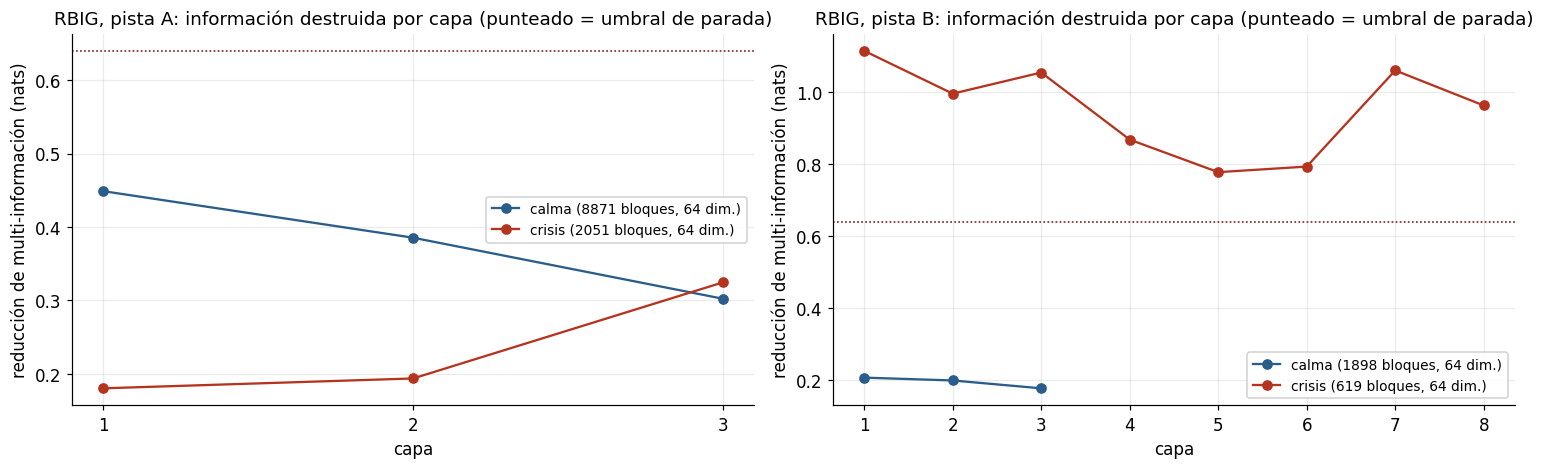

In [30]:
fig, axes = plt.subplots(1, len(PISTAS), figsize=(14, 4.4))
for ax, t in zip(np.atleast_1d(axes), PISTAS):
    h = historial('rbig', t)
    for k, color in ((0, viz.C_LONG), (1, viz.C_CRISIS)):
        hk = h[h['regimen'] == k]
        if hk.empty:
            continue
        ax.plot(hk['capa'], hk['reduccion_info'], 'o-', color=color,
                label=f"{ETIQ_REG[k]} ({int(hk['n_muestras'].iloc[0])} bloques, {int(hk['n_componentes'].iloc[0])} dim.)")
        ax.axhline(float(GEN[(t, 'rbig')].tolerancia) * int(hk['n_componentes'].iloc[0]), color=color, ls=':', lw=1)
    ax.set_xlabel('capa'); ax.set_ylabel('reducción de multi-información (nats)')
    ax.set_title(f'RBIG, pista {t}: información destruida por capa (punteado = umbral de parada)')
    ax.xaxis.get_major_locator().set_params(integer=True); ax.legend(framealpha=0.9)
fig.tight_layout(); guardar(fig, 'rbig_reduccion_informacion'); plt.show()

In [31]:
lineas = []
for (t, r), f in RES_RBIG.iterrows():
    lineas.append(f"- Pista {t}, {r}: {int(f['n_bloques'])} bloques ({f['criterio']}) de dimensión {int(f['dim_bloque'])} "
                  f"reducidos a {int(f['n_componentes'])} componentes ({fmt(100 * f['varianza_explicada'], 1)} % de la "
                  f"varianza de la innovación); {int(f['capas'])} capas, reducción total {fmt(f['reduccion_total'])} nats; "
                  f"R² del contexto {fmt(f['r2_contexto'])}.")
tope = int(registro.clase('rbig').PARAMS['max_capas'])
min_capas = int(registro.clase('rbig').PARAMS['min_capas'])
en_minimo = [f'pista {t}, {r}' for (t, r), f in RES_RBIG.iterrows() if int(f['capas']) <= min_capas]
md('**Lectura.**', *lineas,
   f"- Capas usadas frente al tope de {tope}: máximo {int(RES_RBIG['capas'].max())}. "
   + (f"Paran en el mínimo de {min_capas} capas: {', '.join(en_minimo)}; ahí la regla de parada actúa en cuanto se le "
      f"permite, es decir, tras la condicional gaussiana y la gaussianización por columna queda poca dependencia "
      f"que el estimador distinga del ruido. " if en_minimo else '')
   + 'Donde la curva no baja del umbral punteado la parada es por estancamiento (suelo de ruido del estimador con '
   'pocas muestras), no por haber agotado la dependencia: en esos casos la reducción total mide sobre todo el '
   'sesgo del estimador y no debe leerse como estructura aprendida.',
   f"- El contexto explica entre el {fmt(100 * RES_RBIG['r2_contexto'].min(), 0)} y el {fmt(100 * RES_RBIG['r2_contexto'].max(), 0)} % "
   f"de la varianza del bloque en el espacio gaussianizado: es la persistencia de las columnas de nivel. Lo que RBIG "
   f"modela es el resto.",
   '- La comparación entre regímenes y entre pistas de la altura de las curvas no es válida (distinto número de '
   'bloques); la del número de capas, sí.')

**Lectura.**
- Pista A, calma: 8871 bloques (puros) de dimensión 126 reducidos a 64 componentes (98,4 % de la varianza de la innovación); 3 capas, reducción total 1,14 nats; R² del contexto 0,48.
- Pista A, crisis: 2051 bloques (puros) de dimensión 126 reducidos a 64 componentes (98,2 % de la varianza de la innovación); 3 capas, reducción total 0,70 nats; R² del contexto 0,46.
- Pista B, calma: 1898 bloques (puros) de dimensión 231 reducidos a 64 componentes (92,7 % de la varianza de la innovación); 3 capas, reducción total 0,58 nats; R² del contexto 0,58.
- Pista B, crisis: 619 bloques (puros) de dimensión 231 reducidos a 64 componentes (93,2 % de la varianza de la innovación); 8 capas, reducción total 7,62 nats; R² del contexto 0,56.
- Capas usadas frente al tope de 30: máximo 8. Paran en el mínimo de 3 capas: pista A, calma, pista A, crisis, pista B, calma; ahí la regla de parada actúa en cuanto se le permite, es decir, tras la condicional gaussiana y la gaussianización por columna queda poca dependencia que el estimador distinga del ruido. Donde la curva no baja del umbral punteado la parada es por estancamiento (suelo de ruido del estimador con pocas muestras), no por haber agotado la dependencia: en esos casos la reducción total mide sobre todo el sesgo del estimador y no debe leerse como estructura aprendida.
- El contexto explica entre el 46 y el 58 % de la varianza del bloque en el espacio gaussianizado: es la persistencia de las columnas de nivel. Lo que RBIG modela es el resto.
- La comparación entre regímenes y entre pistas de la altura de las curvas no es válida (distinto número de bloques); la del número de capas, sí.

**(d) Límites conocidos.** Soporte acotado: la inversa satura en el mínimo y el máximo de cada
columna en el régimen, así que no inventa un día peor que el peor observado (y esa misma
saturación es la que impide que el encadenado explote). El pasado solo desplaza la media del
bloque: la volatilidad no se hereda de un bloque al siguiente. En las columnas persistentes el
nivel lo arrastra el contexto, así que la media por régimen no se reproduce; los escalones
mensuales salen como derivas suaves; la varianza que descarta la reducción de dimensión vuelve
como ruido sin estructura, y el modelo de crisis interpola entre muy pocos episodios.

<a id="s5"></a>
## 5. Generadores neuronales

Los cuatro comparten la misma formulación de **«siguiente bloque»**: aprenden la distribución del
bloque de sesiones siguiente condicionada a un contexto de sesiones anteriores y al régimen de
cada día del bloque, $p(\text{bloque} \mid \text{contexto}, \text{régimen})$, y una trayectoria
larga se obtiene encadenando bloques de forma autorregresiva (`regimenes.sinteticos.bloques`),
arrancando del último tramo real. La razón es de tamaño de muestra: una red no puede generar de
una vez una trayectoria de varios años con un solo tramo histórico del que aprender. Comparten
también la representación: las columnas persistentes se modelan como diferencia respecto a la
última fila del contexto (ancla de nivel) y las colas se comprimen con un `arcsinh` invertible.
Flow matching y difusión usan literalmente la misma red y el mismo bucle (`_redes_flujo`); cVAE y
cGAN, el mismo preprocesado (`_redes_latentes`). Así, lo que se compara es el modelo.

Todos se entrenan en CPU con un solo hilo de torch (resultados idénticos con la misma semilla) y
**no se reentrenan para barridos**: los diagnósticos salen del `historial` que el ajuste dejó
guardado. Una advertencia vale para los cuatro: una curva de pérdida sana dice que el optimizador
ha hecho su trabajo, no que las muestras sean buenas; el error se integra a lo largo del muestreo
y después a lo largo de los bloques encadenados.

In [32]:
def tabla_ruido_a_bloque(nombre):
    """Ficha de convergencia de flow matching / difusión en las dos pistas (todo desde lo guardado)."""
    filas = {}
    for t in PISTAS:
        g, h = GEN[(t, nombre)], historial(nombre, t)
        mejor = h.loc[h['perdida_val'].idxmin()] if h['perdida_val'].notna().any() else None
        rep = g.reparto_
        filas[f'pista {t}'] = {
            'parámetros de la red': g.n_parametros_, 'épocas': len(h), 'pasos por época': rep['pasos_por_epoca'],
            'ventanas de ajuste': rep['ventanas_ajuste'], 'ventanas de validación': rep['ventanas_validacion'],
            'validación: calma / crisis / mixtas': ' / '.join(str(x) for x in rep['categorias_validacion']),
            **{f'ancla: {k}': v for k, v in g.anclas_.items() if k in ('predictor_trivial', 'sin_estructura', 'red_nula', 'perdida_val_inicial')},
            'pérdida de ajuste: primera época': h['perdida'].iloc[0], 'pérdida de ajuste: última época': h['perdida'].iloc[-1],
            'pérdida de validación: mínima': np.nan if mejor is None else mejor['perdida_val'],
            'pérdida de validación: última época': h['perdida_val'].iloc[-1],
            'validación en calma (época restaurada)': np.nan if mejor is None else mejor['perdida_val_calma'],
            'validación en crisis (época restaurada)': np.nan if mejor is None else mejor['perdida_val_crisis'],
            'época restaurada': g.epoca_restaurada_,
            'coordenadas recortadas, simulada (%)': 100 * DIAG[(t, nombre, 'simulada')]['fraccion_recortada'],
            'coordenadas recortadas, impuesta (%)': 100 * DIAG[(t, nombre, 'impuesta')]['fraccion_recortada'],
        }
    return pd.DataFrame(filas)


def figura_ruido_a_bloque(nombre, titulo, anclas):
    """Pérdida de ajuste y de validación por época frente a sus anclas, en las dos pistas."""
    fig, axes = plt.subplots(1, len(PISTAS), figsize=(14.5, 4.6))
    for ax, t in zip(np.atleast_1d(axes), PISTAS):
        g, h = GEN[(t, nombre)], historial(nombre, t)
        ax.plot(h['epoca'], h['perdida'], color=viz.C_NEG, lw=1.6, label='ajuste (pesos en curso, lotes equilibrados)')
        ax.plot(h['epoca'], h['perdida_val'], color='black', lw=1.8, label='validación (pesos EMA)')
        ax.plot(h['epoca'], h['perdida_val_calma'], color=viz.C_LONG, lw=1.1, ls='--', label='validación, ventanas en calma')
        if h['perdida_val_crisis'].notna().any():
            ax.plot(h['epoca'], h['perdida_val_crisis'], color=viz.C_CRISIS, lw=1.1, ls='--', label='validación, ventanas con crisis')
        for clave, (etiqueta, estilo) in anclas.items():
            ax.axhline(g.anclas_[clave], color='black', ls=estilo, lw=0.9, label=etiqueta)
        ax.axvline(g.epoca_restaurada_, color=viz.C_SHORT, ls='-.', lw=1.2, label=f'época restaurada ({g.epoca_restaurada_})')
        ax.set_xlabel('época'); ax.set_ylabel('pérdida (error cuadrático por coordenada)')
        ax.set_ylim(top=ax.get_ylim()[0] + 1.45 * (ax.get_ylim()[1] - ax.get_ylim()[0]))   # hueco para la leyenda
        ax.set_title(f'{titulo}, pista {t}'); ax.legend(fontsize=8, framealpha=0.9, loc='upper right', ncol=2)
    fig.tight_layout(); guardar(fig, f'{nombre}_perdida'); plt.show()


def lectura_ruido_a_bloque(nombre, tabla, ancla_superior):
    """Frases por pista sobre la curva de pérdida (cifras de la tabla)."""
    lineas = []
    for t in PISTAS:
        c = tabla[f'pista {t}']
        ultima = int(c['épocas'])
        sin_crisis = not np.isfinite(c['validación en crisis (época restaurada)'])
        lineas.append(
            f"- Pista {t}: la red recién creada mide {fmt(c['ancla: perdida_val_inicial'], 3)} en validación (ancla "
            f"{fmt(c[f'ancla: {ancla_superior}'], 3)}); el ajuste baja de {fmt(c['pérdida de ajuste: primera época'], 3)} a "
            f"{fmt(c['pérdida de ajuste: última época'], 3)} y la validación toca su mínimo, "
            f"{fmt(c['pérdida de validación: mínima'], 3)}, en la época {int(c['época restaurada'])} de {ultima} "
            f"(última época: {fmt(c['pérdida de validación: última época'], 3)}). "
            + ('**La cola de validación no contiene ninguna ventana con crisis**: la época se elige sin ver el régimen '
               'que más importa. ' if sin_crisis else
               f"Por régimen, en la época restaurada: {fmt(c['validación en calma (época restaurada)'], 3)} en calma y "
               f"{fmt(c['validación en crisis (época restaurada)'], 3)} en ventanas con crisis. ")
            + f"Coordenadas que tocan el tope de seguridad al muestrear: {fmt(c['coordenadas recortadas, simulada (%)'], 4)} % "
            f"(cadena simulada) y {fmt(c['coordenadas recortadas, impuesta (%)'], 4)} % (impuesta).")
    return lineas


def formato_mixto(tabla):
    """Tabla de fichas con enteros y decimales mezclados."""
    return tabla.style.format(lambda v: v if isinstance(v, str) else ('—' if pd.isna(v) else
                              (f'{v:.0f}' if float(v).is_integer() and abs(v) >= 1 else f'{v:.4f}')))

<a id="s5-1"></a>
### 5.1 `flow_matching` — flow matching condicional (caminos rectos)

**(a) Idea y supuestos.** Aprende el **campo de velocidades** que transporta ruido gaussiano hasta
el siguiente bloque. Para entrenar no hay que integrar nada: por cada ventana se sortean un ruido
$x_0 \sim \mathcal N(0, I)$ y un instante $t \sim \mathcal U(0,1)$, se toma el punto del segmento
$x_t = (1-t)\,x_0 + t\,x_1$ y se hace regresión de mínimos cuadrados sobre la velocidad del
segmento,

$$
\mathcal L(\theta) = \mathbb E_{t,\,x_0,\,x_1}\,\big\lVert v_\theta(x_t, t \mid c) - (x_1 - x_0)\big\rVert^2 ,
$$

con $c$ el contexto y el régimen (Lipman et al., 2023; Liu, Gong y Liu, 2023). Muestrear es soltar
una partícula en $x_0$ e integrar $\dot x = v_\theta(x, t \mid c)$ hasta $t = 1$. Supone que el
bloque siguiente depende del pasado solo a través del contexto y del régimen del propio bloque, y
usa una red densa sobre el bloque aplanado, sin sesgo inductivo temporal.

**Cómo leer la pérdida.** Es un error cuadrático por coordenada sobre datos de varianza unidad y
tiene dos referencias que el propio generador guarda (`anclas_`): la del **predictor trivial**
$v = 0$ (la red recién creada) y la de unos **datos sin ninguna estructura**, para los que el
mejor predictor sigue fallando. Por debajo de la segunda se está aprendiendo dependencia real. La
pérdida no tiende a cero: su mínimo es la varianza condicional de la velocidad dado $x_t$.

,generador,trayectorias,ajuste_s,muestreo_simulada_s,muestreo_impuesta_s,finito,regimen_respetado,cadena_compartida,fechas_y_columnas,reproducible,control_coincide
pista,,,,,,,,,,,
A,cargado,cargado,49.305591,17.521895,17.662549,True,True,True,True,True,True
B,cargado,cargado,13.404954,19.515450,19.486986,True,True,True,True,True,True


,pista A,pista B
parámetros de la red,781948,889678
épocas,40,40
pasos por época,38,9
ventanas de ajuste,9500,2220
ventanas de validación,1684,399
validación: calma / crisis / mixtas,1044 / 618 / 22,399 / 0 / 0
ancla: predictor_trivial,2,2
ancla: sin_estructura,1.5708,1.5708
ancla: perdida_val_inicial,1.9366,1.4303
pérdida de ajuste: primera época,1.6941,1.9084


figura -> results/sinteticos/generadores/flow_matching_perdida.png


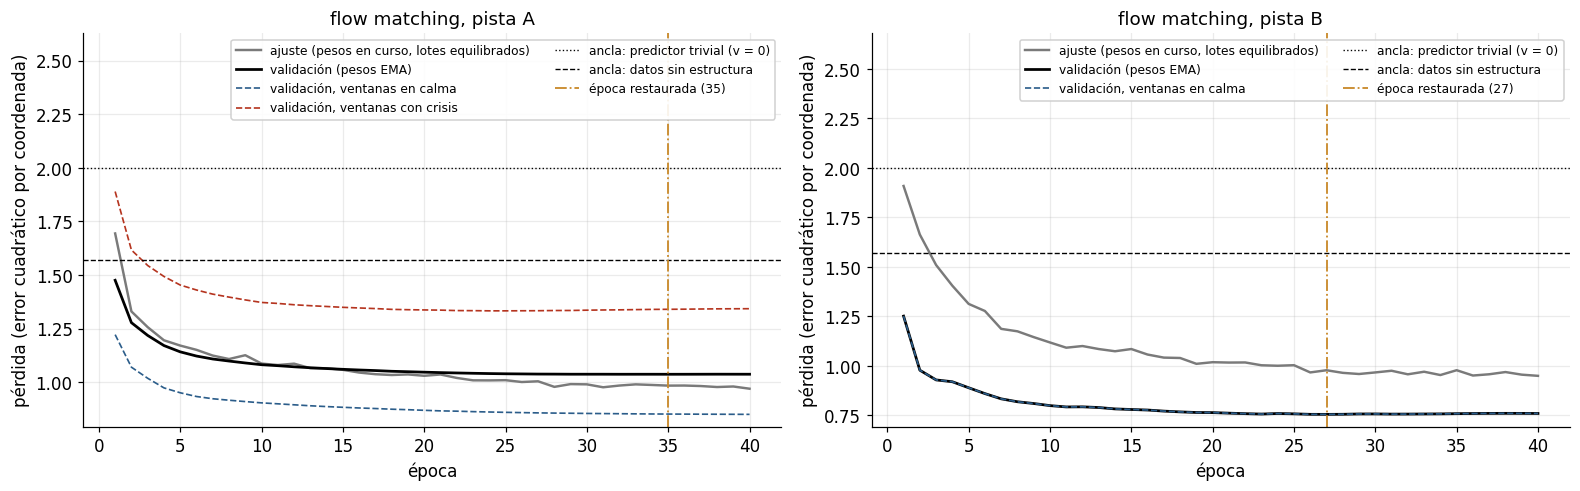

In [33]:
display(procesar('flow_matching'))
TABLA_FM = tabla_ruido_a_bloque('flow_matching')
display(formato_mixto(TABLA_FM))
figura_ruido_a_bloque('flow_matching', 'flow matching',
                      {'predictor_trivial': ('ancla: predictor trivial (v = 0)', ':'),
                       'sin_estructura': ('ancla: datos sin estructura', '--')})

In [34]:
lineas = lectura_ruido_a_bloque('flow_matching', TABLA_FM, 'predictor_trivial')
bajo = [t for t in PISTAS if TABLA_FM.loc['pérdida de validación: mínima', f'pista {t}'] < TABLA_FM.loc['ancla: sin_estructura', f'pista {t}']]
sube = [t for t in PISTAS if TABLA_FM.loc['pérdida de validación: última época', f'pista {t}']
        > 1.01 * TABLA_FM.loc['pérdida de validación: mínima', f'pista {t}']]
md('**(c) Lectura de la convergencia.**', *lineas,
   f"- La validación queda por debajo del ancla de datos sin estructura ({fmt(TABLA_FM.loc['ancla: sin_estructura'].iloc[0], 3)}) "
   f"en: {', '.join('pista ' + t for t in bajo) or 'ninguna pista'}. Ahí la red ha aprendido dependencia entre días, "
   f"entre columnas y con el contexto.",
   (f"- La validación vuelve a subir más de un 1 % tras su mínimo en: {', '.join('pista ' + t for t in sube)}. Es la señal "
    f"de sobreajuste que motiva conservar los pesos de la época restaurada y no los últimos."
    if sube else '- La validación no vuelve a subir de forma apreciable tras su mínimo: no hay señal de sobreajuste en las '
    'épocas configuradas.'),
   '- La pérdida en ventanas con crisis es mayor que en calma donde se puede medir: hay menos ventanas de las que '
   'aprender y más varianza que explicar.')

**(c) Lectura de la convergencia.**
- Pista A: la red recién creada mide 1,937 en validación (ancla 2,000); el ajuste baja de 1,694 a 0,970 y la validación toca su mínimo, 1,038, en la época 35 de 40 (última época: 1,038). Por régimen, en la época restaurada: 0,852 en calma y 1,340 en ventanas con crisis. Coordenadas que tocan el tope de seguridad al muestrear: 0,0056 % (cadena simulada) y 0,0050 % (impuesta).
- Pista B: la red recién creada mide 1,430 en validación (ancla 2,000); el ajuste baja de 1,908 a 0,950 y la validación toca su mínimo, 0,755, en la época 27 de 40 (última época: 0,760). **La cola de validación no contiene ninguna ventana con crisis**: la época se elige sin ver el régimen que más importa. Coordenadas que tocan el tope de seguridad al muestrear: 0,1683 % (cadena simulada) y 0,2119 % (impuesta).
- La validación queda por debajo del ancla de datos sin estructura (1,571) en: pista A, pista B. Ahí la red ha aprendido dependencia entre días, entre columnas y con el contexto.
- La validación no vuelve a subir de forma apreciable tras su mínimo: no hay señal de sobreajuste en las épocas configuradas.
- La pérdida en ventanas con crisis es mayor que en calma donde se puede medir: hay menos ventanas de las que aprender y más varianza que explicar.

**(d) Límites conocidos.** La época se elige con una cola cronológica del propio tramo de
entrenamiento, que no se usa para ajustar y puede no contener crisis. Las colas en calma quedan
cortas y ningún evento del tamaño del mayor desplome se aprende de una sola observación; el
agrupamiento de volatilidad se reproduce a medias y, con él, la volatilidad realizada
re-derivada; los escalones mensuales salen como series suaves.

<a id="s5-2"></a>
### 5.2 `difusion` — difusión condicional (predicción de ruido, muestreo DDIM)

**(a) Idea y supuestos.** Aprende a **quitar ruido** al siguiente bloque. El proceso directo tiene
forma cerrada (Ho, Jain y Abbeel, 2020),

$$
x_t = \sqrt{\bar\alpha_t}\,x_0 + \sqrt{1-\bar\alpha_t}\,\varepsilon,\qquad
\mathcal L(\theta) = \mathbb E\,\big\lVert \varepsilon_\theta(x_t, t \mid c) - \varepsilon \big\rVert^2 ,
$$

con un planificador coseno de los niveles de ruido (Nichol y Dhariwal, 2021); la red predice el
ruido inyectado. Se muestrea con DDIM determinista (Song, Meng y Ermon, 2021) sobre una
subsecuencia de niveles. El régimen se anula en una fracción de los ejemplos de cada lote para
poder extrapolar entre el modelo con y sin régimen al muestrear (guiado sin clasificador; Ho y
Salimans, 2022), aunque con la configuración por defecto se usa el condicional puro. Es el mismo
transporte de ruido a datos que el flow matching con otra parametrización: comparten red,
preprocesado y bucle, de modo que la comparación mide solo esa diferencia.

**Cómo leer la pérdida.** Es el error cuadrático del ruido por coordenada. El ancla es la **red
nula**: recién creada predice cero y la pérdida vale la varianza del ruido. Tampoco tiende a cero:
en los niveles de mucho ruido $x_t$ apenas informa del ruido inyectado. La pérdida de difusión y
la de flow matching **no son comparables entre sí**, y esta curva no dice nada de los parámetros
de muestreo, que son los que deciden la calidad. El tope de seguridad de la cadena inversa (la
fracción de coordenadas que lo tocan) es el segundo indicador: si crece, el modelo no ha aprendido
el soporte.

,generador,trayectorias,ajuste_s,muestreo_simulada_s,muestreo_impuesta_s,finito,regimen_respetado,cadena_compartida,fechas_y_columnas,reproducible,control_coincide
pista,,,,,,,,,,,
A,cargado,cargado,67.442118,18.456888,18.046567,True,True,True,True,True,True
B,cargado,cargado,19.895292,19.677005,19.816440,True,True,True,True,True,True


,pista A,pista B
parámetros de la red,781948,889678
épocas,60,60
pasos por época,38,9
ventanas de ajuste,9500,2220
ventanas de validación,1684,399
validación: calma / crisis / mixtas,1044 / 618 / 22,399 / 0 / 0
ancla: red_nula,1,1
ancla: perdida_val_inicial,0.9996,1.0025
pérdida de ajuste: primera época,0.6165,0.9267
pérdida de ajuste: última época,0.2958,0.2886


figura -> results/sinteticos/generadores/difusion_perdida.png


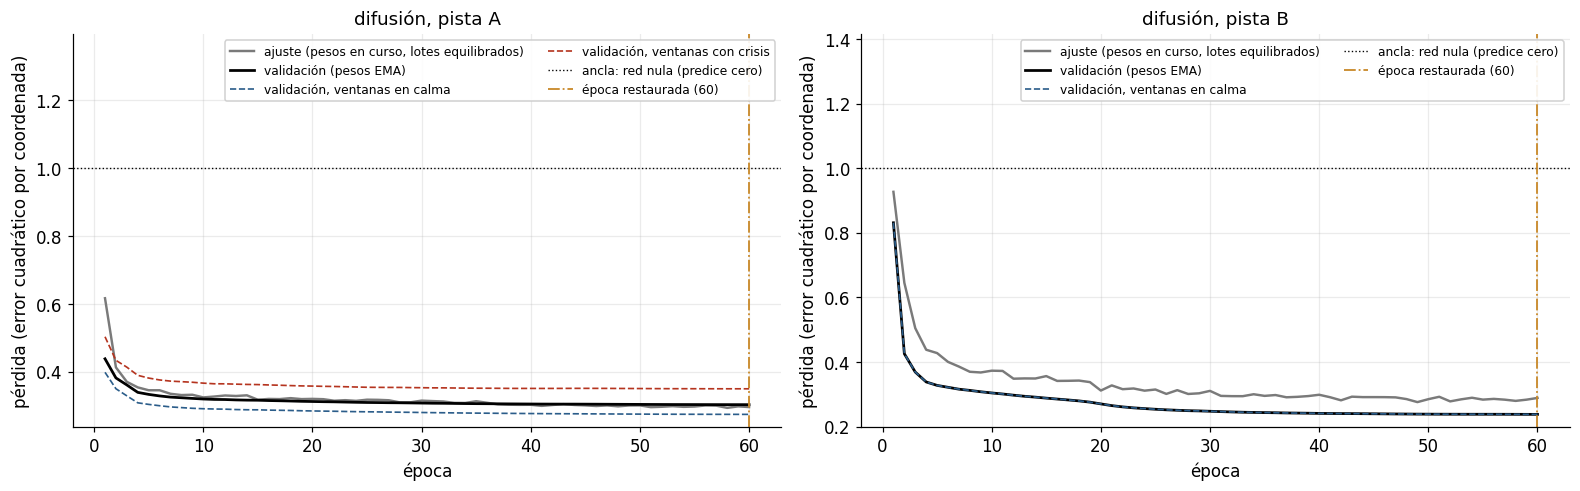

In [35]:
display(procesar('difusion'))
TABLA_DIF = tabla_ruido_a_bloque('difusion')
display(formato_mixto(TABLA_DIF))
figura_ruido_a_bloque('difusion', 'difusión', {'red_nula': ('ancla: red nula (predice cero)', ':')})

In [36]:
lineas = lectura_ruido_a_bloque('difusion', TABLA_DIF, 'red_nula')
monotona = [t for t in PISTAS if TABLA_DIF.loc['pérdida de validación: última época', f'pista {t}']
            <= 1.01 * TABLA_DIF.loc['pérdida de validación: mínima', f'pista {t}']]
rec = {t: {m: 100 * DIAG[(t, n, m)]['fraccion_recortada'] for n in ('flow_matching', 'difusion') for m in ('simulada',)}
       for t in PISTAS}
md('**(c) Lectura de la convergencia.**', *lineas,
   (f"- La validación termina en su mínimo (o a menos de un 1 %) en: {', '.join('pista ' + t for t in monotona)}: curva "
    f"monótona, sin señal de sobreajuste en las épocas configuradas."
    if monotona else '- La validación termina por encima de su mínimo en las dos pistas: hay sobreajuste y la época '
    'restaurada importa.'),
   '- Fracción de coordenadas recortadas, difusión frente a flow matching (cadena simulada): '
   + '; '.join(f"pista {t}: {fmt(100 * DIAG[(t, 'difusion', 'simulada')]['fraccion_recortada'], 4)} % frente a "
               f"{fmt(100 * DIAG[(t, 'flow_matching', 'simulada')]['fraccion_recortada'], 4)} %" for t in PISTAS)
   + '. El tope acota cada coordenada a un múltiplo de su extremo histórico: no mutila ningún valor observado, solo '
   'impide que un bloque desbocado saque el contexto de lo que la red ha visto.')

**(c) Lectura de la convergencia.**
- Pista A: la red recién creada mide 1,000 en validación (ancla 1,000); el ajuste baja de 0,617 a 0,296 y la validación toca su mínimo, 0,303, en la época 60 de 60 (última época: 0,303). Por régimen, en la época restaurada: 0,274 en calma y 0,350 en ventanas con crisis. Coordenadas que tocan el tope de seguridad al muestrear: 0,0176 % (cadena simulada) y 0,0248 % (impuesta).
- Pista B: la red recién creada mide 1,002 en validación (ancla 1,000); el ajuste baja de 0,927 a 0,289 y la validación toca su mínimo, 0,238, en la época 60 de 60 (última época: 0,238). **La cola de validación no contiene ninguna ventana con crisis**: la época se elige sin ver el régimen que más importa. Coordenadas que tocan el tope de seguridad al muestrear: 0,1700 % (cadena simulada) y 0,1912 % (impuesta).
- La validación termina en su mínimo (o a menos de un 1 %) en: pista A, pista B: curva monótona, sin señal de sobreajuste en las épocas configuradas.
- Fracción de coordenadas recortadas, difusión frente a flow matching (cadena simulada): pista A: 0,0176 % frente a 0,0056 %; pista B: 0,1700 % frente a 0,1683 %. El tope acota cada coordenada a un múltiplo de su extremo histórico: no mutila ningún valor observado, solo impide que un bloque desbocado saque el contexto de lo que la red ha visto.

**(d) Límites conocidos.** La calidad depende de dónde arranca la cadena inversa y de cuántos
pasos tiene más que de la pérdida. Las colas quedan cortas en los dos regímenes, el agrupamiento
de volatilidad es débil, los escalones salen suavizados y, como en el flow matching, la selección
de época usa una cola de validación que puede no contener crisis.

<a id="s5-3"></a>
### 5.3 `cvae` — autoencoder variacional condicional

**(a) Idea y supuestos.** Modelo de variable latente (Kingma y Welling, 2014) condicionado en
codificador y decodificador (Sohn, Lee y Yan, 2015). Se maximiza la cota inferior de la evidencia

$$
\mathcal L(x, c) = \mathbb E_{q_\phi(z \mid x, c)}\big[\log p_\theta(x \mid z, c)\big]
 - \beta\,\mathrm{KL}\big(q_\phi(z \mid x, c)\,\Vert\,\mathcal N(0, I)\big),
$$

con rampa lineal del peso $\beta$ (Bowman et al., 2016; el peso es el de Higgins et al., 2017) y
un suelo por dimensión latente para evitar el colapso. La diferencia con el cVAE del taller
previo es que el decodificador emite **media y varianza** por dimensión y al muestrear se añade el
ruido de observación: muestrear solo la media, como se hacía, promedia todo lo que el latente no
explica y produce trayectorias infradispersas. Supone una gaussiana diagonal condicionada al
latente: la dependencia entre columnas y entre días del bloque solo puede pasar por el latente y
por la media.

**Cómo leer el historial.** La reconstrucción es una log-verosimilitud negativa (con varianza
aprendida puede ser negativa: no es un error cuadrático). Un ajuste sano baja la reconstrucción
hasta aplanarla, **sube** la divergencia KL desde casi cero hasta una meseta positiva y mantiene
unidades latentes activas; KL nula con ninguna unidad activa es colapso del posterior. La cota de
validación baja y después sube: su mínimo fija la **mejor época** de la primera fase, y la segunda
fase reentrena desde cero con todo el tramo durante ese número de épocas. El **cociente de
dispersión** (desviación sintética sobre real, media sobre dimensiones) se registra con y sin
ruido de observación.

,generador,trayectorias,ajuste_s,muestreo_simulada_s,muestreo_impuesta_s,finito,regimen_respetado,cadena_compartida,fechas_y_columnas,reproducible,control_coincide
pista,,,,,,,,,,,
A,cargado,cargado,139.437087,1.075704,1.044908,True,True,True,True,True,True
B,cargado,cargado,21.312768,1.321465,1.545291,True,True,True,True,True,True


,pista A,pista B
épocas fase 1 (con validación),120,58
mejor época (índice desde 0),111,32
épocas fase 2 (todo train),112,33
cota de validación no finita,False,False
cota de validación: primera época,153.7787,634.1624
cota de validación: mínima,31.6747,133.1898
cota de validación: última época de la fase 1,32.6478,155.9226
reconstrucción de ajuste en la mejor época (fase 1),12.9799,135.1649
reconstrucción de validación en la mejor época,16.9666,117.9131
reconstrucción final,15.4626,117.2553


figura -> results/sinteticos/generadores/cvae_convergencia.png


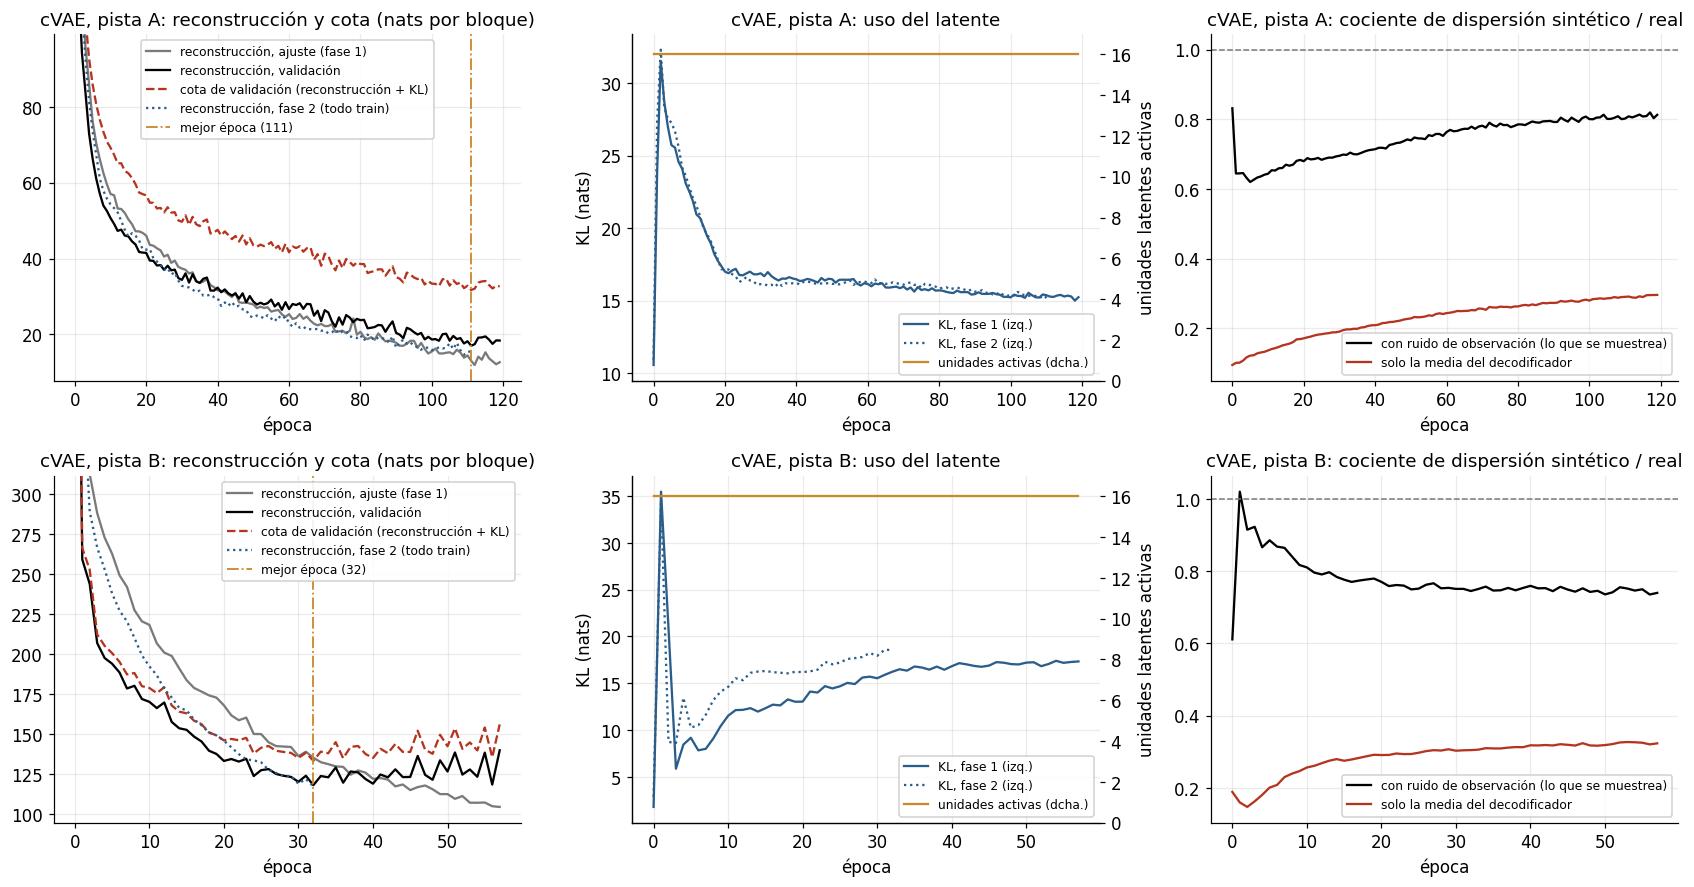

In [37]:
display(procesar('cvae'))
filas = {}
for t in PISTAS:
    g, h = GEN[(t, 'cvae')], historial('cvae', t)
    f1, f2 = h[h['fase'] == 1], h[h['fase'] == 2]
    ultima = (f2 if len(f2) else f1).iloc[-1]
    filas[f'pista {t}'] = {
        'épocas fase 1 (con validación)': len(f1), 'mejor época (índice desde 0)': g.mejor_epoca_,
        'épocas fase 2 (todo train)': len(f2), 'cota de validación no finita': str(bool(g.val_elbo_invalido_)),
        'cota de validación: primera época': f1['val_elbo'].iloc[0], 'cota de validación: mínima': f1['val_elbo'].min(),
        'cota de validación: última época de la fase 1': f1['val_elbo'].iloc[-1],
        'reconstrucción de ajuste en la mejor época (fase 1)': f1['reconstruccion'].iloc[int(g.mejor_epoca_)],
        'reconstrucción de validación en la mejor época': f1['val_reconstruccion'].iloc[int(g.mejor_epoca_)],
        'reconstrucción final': ultima['reconstruccion'], 'KL final (nats)': ultima['kl'],
        'unidades latentes activas (final)': ultima['unidades_activas'], 'dimensión latente': g.dim_latente,
        'desviación media del ruido de observación': ultima['sigma_decoder'],
        'cociente de dispersión con ruido (final)': ultima['cociente_dispersion'],
        'cociente de dispersión solo media (final)': ultima['cociente_dispersion_media'],
    }
TABLA_CVAE = pd.DataFrame(filas)
display(formato_mixto(TABLA_CVAE))

fig, axes = plt.subplots(len(PISTAS), 3, figsize=(15.5, 4.1 * len(PISTAS)))
for fila_ax, t in zip(np.atleast_2d(axes), PISTAS):
    g, h = GEN[(t, 'cvae')], historial('cvae', t)
    f1, f2 = h[h['fase'] == 1], h[h['fase'] == 2]
    ax = fila_ax[0]
    ax.plot(f1['epoca'], f1['reconstruccion'], color=viz.C_NEG, label='reconstrucción, ajuste (fase 1)')
    ax.plot(f1['epoca'], f1['val_reconstruccion'], color='black', label='reconstrucción, validación')
    ax.plot(f1['epoca'], f1['val_elbo'], color=viz.C_CRISIS, ls='--', label='cota de validación (reconstrucción + KL)')
    if len(f2):
        ax.plot(f2['epoca'], f2['reconstruccion'], color=viz.C_LONG, ls=':', label='reconstrucción, fase 2 (todo train)')
    ax.axvline(g.mejor_epoca_, color=viz.C_SHORT, ls='-.', lw=1.2, label=f'mejor época ({g.mejor_epoca_})')
    recorte_y = np.nanpercentile(np.r_[f1['val_elbo'], f1['reconstruccion']], [0, 97])
    ax.set_ylim(recorte_y[0] - 0.05 * np.ptp(recorte_y), recorte_y[1] + 0.05 * np.ptp(recorte_y))
    ax.set_title(f'cVAE, pista {t}: reconstrucción y cota (nats por bloque)'); ax.set_xlabel('época'); ax.legend(fontsize=8, framealpha=0.9)
    ax = fila_ax[1]
    ax.plot(f1['epoca'], f1['kl'], color=viz.C_LONG, label='KL, fase 1 (izq.)')
    if len(f2):
        ax.plot(f2['epoca'], f2['kl'], color=viz.C_LONG, ls=':', label='KL, fase 2 (izq.)')
    ax.set_ylabel('KL (nats)'); ax.set_xlabel('época')
    eje = ax.twinx(); eje.grid(False)
    eje.step(f1['epoca'], f1['unidades_activas'], color=viz.C_SHORT, where='post', label='unidades activas (dcha.)')
    eje.set_ylim(0, g.dim_latente + 1); eje.set_ylabel('unidades latentes activas')
    a, b = ax.get_legend_handles_labels(), eje.get_legend_handles_labels()
    ax.legend(a[0] + b[0], a[1] + b[1], fontsize=8, framealpha=0.9, loc='lower right')
    ax.set_title(f'cVAE, pista {t}: uso del latente')
    ax = fila_ax[2]
    ax.plot(f1['epoca'], f1['cociente_dispersion'], color='black', label='con ruido de observación (lo que se muestrea)')
    ax.plot(f1['epoca'], f1['cociente_dispersion_media'], color=viz.C_CRISIS, label='solo la media del decodificador')
    ax.axhline(1.0, color=viz.C_NEG, ls='--', lw=1)
    ax.set_title(f'cVAE, pista {t}: cociente de dispersión sintético / real'); ax.set_xlabel('época'); ax.legend(fontsize=8, framealpha=0.9)
fig.tight_layout(); guardar(fig, 'cvae_convergencia'); plt.show()

In [38]:
lineas = []
for t in PISTAS:
    c = TABLA_CVAE[f'pista {t}']
    brecha = c['reconstrucción de validación en la mejor época'] - c['reconstrucción de ajuste en la mejor época (fase 1)']
    lineas.append(
        f"- Pista {t}: la cota de validación baja de {fmt(c['cota de validación: primera época'], 1)} a un mínimo de "
        f"{fmt(c['cota de validación: mínima'], 1)} nats en la época {int(c['mejor época (índice desde 0)'])} "
        f"({int(c['épocas fase 1 (con validación)'])} épocas ejecutadas en la fase 1; última: "
        f"{fmt(c['cota de validación: última época de la fase 1'], 1)}) y la fase 2 reentrena {int(c['épocas fase 2 (todo train)'])} "
        f"épocas. En la mejor época la reconstrucción de validación queda {fmt(abs(brecha), 1)} nats "
        f"{'por encima' if brecha > 0 else 'por DEBAJO'} de la de ajuste. "
        f"KL final {fmt(c['KL final (nats)'], 1)} nats con {int(c['unidades latentes activas (final)'])} de "
        f"{int(c['dimensión latente'])} unidades activas. Cociente de dispersión: {fmt(c['cociente de dispersión con ruido (final)'])} "
        f"con ruido de observación y {fmt(c['cociente de dispersión solo media (final)'])} muestreando solo la media.")
colapso = [t for t in PISTAS if TABLA_CVAE.loc['unidades latentes activas (final)', f'pista {t}'] == 0]
md('**(c) Lectura de la convergencia.**', *lineas,
   ('- **Colapso del posterior** (ninguna unidad activa) en: ' + ', '.join('pista ' + t for t in colapso) + '.'
    if colapso else '- No hay colapso del posterior: el latente se usa en las dos pistas (unidades activas al final: '
    + ', '.join(f"{int(TABLA_CVAE.loc['unidades latentes activas (final)', f'pista {t}'])} de "
                f"{int(TABLA_CVAE.loc['dimensión latente', f'pista {t}'])} en la pista {t}" for t in PISTAS) + ').'),
   '- **Infradispersión residual**: aun con el ruido de observación, el cociente de dispersión del diagnóstico queda en '
   + ' y '.join(f"{fmt(TABLA_CVAE.loc['cociente de dispersión con ruido (final)', f'pista {t}'])} en la pista {t}" for t in PISTAS)
   + ' (uno sería la dispersión real).',
   '- La diferencia entre los dos cocientes de dispersión es el defecto que se corrige respecto al taller previo: la '
   'media del decodificador sola es infradispersa, y el ruido de observación repone la varianza que el latente no '
   'explica. El coste es que ese ruido es independiente por día y por dimensión de la representación: añade una '
   'vibración diaria a las columnas que en el dato real son escalones.',
   '- La brecha entre reconstrucción de validación y de ajuste mide el sobreajuste que queda pese a la '
   'regularización; la mejor época se elige dentro del propio tramo de entrenamiento y hereda ese sesgo.')

**(c) Lectura de la convergencia.**
- Pista A: la cota de validación baja de 153,8 a un mínimo de 31,7 nats en la época 111 (120 épocas ejecutadas en la fase 1; última: 32,6) y la fase 2 reentrena 112 épocas. En la mejor época la reconstrucción de validación queda 4,0 nats por encima de la de ajuste. KL final 15,3 nats con 16 de 16 unidades activas. Cociente de dispersión: 0,83 con ruido de observación y 0,30 muestreando solo la media.
- Pista B: la cota de validación baja de 634,2 a un mínimo de 133,2 nats en la época 32 (58 épocas ejecutadas en la fase 1; última: 155,9) y la fase 2 reentrena 33 épocas. En la mejor época la reconstrucción de validación queda 17,3 nats por DEBAJO de la de ajuste. KL final 18,6 nats con 16 de 16 unidades activas. Cociente de dispersión: 0,75 con ruido de observación y 0,31 muestreando solo la media.
- No hay colapso del posterior: el latente se usa en las dos pistas (unidades activas al final: 16 de 16 en la pista A, 16 de 16 en la pista B).
- **Infradispersión residual**: aun con el ruido de observación, el cociente de dispersión del diagnóstico queda en 0,83 en la pista A y 0,75 en la pista B (uno sería la dispersión real).
- La diferencia entre los dos cocientes de dispersión es el defecto que se corrige respecto al taller previo: la media del decodificador sola es infradispersa, y el ruido de observación repone la varianza que el latente no explica. El coste es que ese ruido es independiente por día y por dimensión de la representación: añade una vibración diaria a las columnas que en el dato real son escalones.
- La brecha entre reconstrucción de validación y de ajuste mide el sobreajuste que queda pese a la regularización; la mejor época se elige dentro del propio tramo de entrenamiento y hereda ese sesgo.

**(d) Límites conocidos.** Si el latente se usa poco, el modelo degenera hacia ruido independiente
por día alrededor de una media que solo depende del contexto. No garantiza los escalones de las
columnas mensuales ni el agrupamiento de volatilidad dentro del bloque más allá de lo que capture
el latente. La estandarización y la elección de la época usan el propio tramo de entrenamiento
(validación interna, no un tramo independiente).

<a id="s5-4"></a>
### 5.4 `cgan` — GAN condicional entrenada como WGAN-GP

**(a) Idea y supuestos.** Aprende a muestrear sin densidad explícita (Goodfellow et al., 2014): un
generador $G(z, c)$ transforma ruido y condición en el siguiente bloque y un crítico $D(x, c)$
compara bloques reales y generados **con la misma condición** (Mirza y Osindero, 2014). Se entrena
con la pérdida de Wasserstein con penalización de gradiente (Arjovsky, Chintala y Bottou, 2017;
Gulrajani et al., 2017),

$$
\min_G \max_D\; \mathbb E\big[D(x, c)\big] - \mathbb E\big[D(G(z, c), c)\big]
 - \lambda\,\mathbb E\Big[\big(\lVert \nabla_{\hat x} D(\hat x, c)\rVert_2 - 1\big)^2\Big],
$$

que da gradiente útil al generador aunque las dos distribuciones no se solapen, justo donde la
entropía cruzada de la cGAN del taller previo se saturaba. Sin normalización por lotes, con
varios pasos del crítico por cada paso del generador, media móvil de los pesos del generador y
abandono del contexto en parte de cada lote para que la etiqueta de régimen importe. El generador
es determinista dado $(z, c)$: nada le obliga a usar $z$, y con una condición tan informativa el
riesgo específico es el **colapso condicional** (una continuación plausible por contexto,
ignorando el ruido).

**Cómo leer el historial.** La distancia de Wasserstein estimada debe **decrecer hacia una meseta
baja y positiva**; la penalización de gradiente debe quedar pequeña (si no, la restricción de
Lipschitz no se cumple y la distancia no lo es); el acierto del crítico mide si separa real de
generado (un medio es indistinguible *para este crítico*); el cociente de dispersión cerca de uno
descarta el colapso de modos y la **diversidad** entre dos muestras con la misma condición y
distinto ruido, claramente positiva, descarta el colapso condicional. No hay verosimilitud ni
selección de época: se usa la última.

,generador,trayectorias,ajuste_s,muestreo_simulada_s,muestreo_impuesta_s,finito,regimen_respetado,cadena_compartida,fechas_y_columnas,reproducible,control_coincide
pista,,,,,,,,,,,
A,cargado,cargado,110.907551,1.014034,0.991007,True,True,True,True,True,True
B,cargado,cargado,41.607141,1.204158,1.207521,True,True,True,True,True,True


,pista A,pista B
épocas,150,150
Wasserstein: primera época,0.5823,0.0957
Wasserstein: máximo,12.5183,16.0234
Wasserstein: media de las últimas 10,3.8203,10.2191
Wasserstein: desviación en las últimas,0.0405,0.1771
penalización de gradiente (últimas),0.0431,0.1452
acierto del crítico (últimas),0.5564,0.5470
cociente de dispersión (últimas),0.8879,0.6755
cociente de dispersión: mínimo y máximo,"0,10 – 1,03","0,09 – 0,68"
diversidad entre ruidos (últimas),0.8292,0.5195


figura -> results/sinteticos/generadores/cgan_convergencia.png


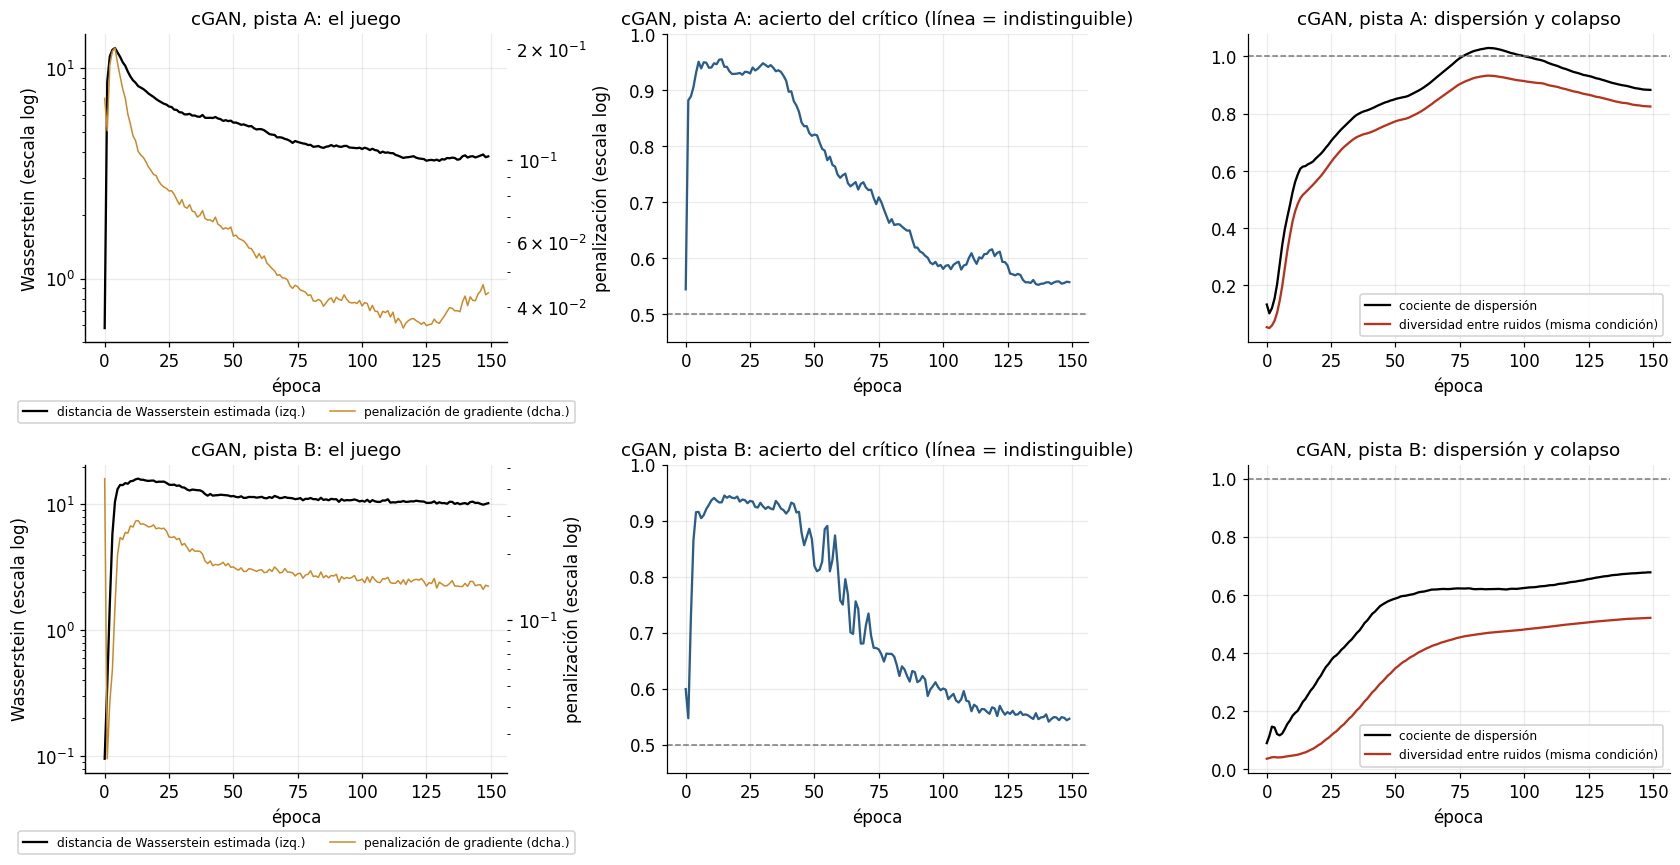

In [39]:
display(procesar('cgan'))
N_FINAL = 10   # épocas finales sobre las que se promedia (la curva de una GAN oscila)
filas = {}
for t in PISTAS:
    h = historial('cgan', t)
    fin = h.tail(N_FINAL)
    filas[f'pista {t}'] = {
        'épocas': len(h), 'Wasserstein: primera época': h['wasserstein'].iloc[0],
        'Wasserstein: máximo': h['wasserstein'].max(), f'Wasserstein: media de las últimas {N_FINAL}': fin['wasserstein'].mean(),
        'Wasserstein: desviación en las últimas': fin['wasserstein'].std(),
        'penalización de gradiente (últimas)': fin['penalizacion_gradiente'].mean(),
        'acierto del crítico (últimas)': fin['acierto_critico'].mean(),
        'cociente de dispersión (últimas)': fin['cociente_dispersion'].mean(),
        'cociente de dispersión: mínimo y máximo': f"{fmt(h['cociente_dispersion'].min())} – {fmt(h['cociente_dispersion'].max())}",
        'diversidad entre ruidos (últimas)': fin['diversidad_z'].mean(),
        'validación del crítico': 'no (todo train entra en el ajuste)' if h['wasserstein_val'].isna().all() else 'sí',
    }
TABLA_CGAN = pd.DataFrame(filas)
display(formato_mixto(TABLA_CGAN))

fig, axes = plt.subplots(len(PISTAS), 3, figsize=(15.5, 4.0 * len(PISTAS)))
for fila_ax, t in zip(np.atleast_2d(axes), PISTAS):
    h = historial('cgan', t)
    ax = fila_ax[0]
    ax.plot(h['epoca'], h['wasserstein'], color='black', label='distancia de Wasserstein estimada (izq.)')
    ax.set_yscale('log'); ax.set_xlabel('época'); ax.set_ylabel('Wasserstein (escala log)')
    eje = ax.twinx(); eje.grid(False)
    eje.plot(h['epoca'], h['penalizacion_gradiente'], color=viz.C_SHORT, lw=1, label='penalización de gradiente (dcha.)')
    eje.set_yscale('log'); eje.set_ylabel('penalización (escala log)')
    a, b = ax.get_legend_handles_labels(), eje.get_legend_handles_labels()
    ax.legend(a[0] + b[0], a[1] + b[1], fontsize=8, framealpha=0.9, loc='upper center', bbox_to_anchor=(0.5, -0.17), ncol=2)
    ax.set_title(f'cGAN, pista {t}: el juego')
    ax = fila_ax[1]
    ax.plot(h['epoca'], h['acierto_critico'], color=viz.C_LONG)
    ax.axhline(0.5, color=viz.C_NEG, ls='--', lw=1); ax.set_ylim(0.45, 1.0)
    ax.set_xlabel('época'); ax.set_title(f'cGAN, pista {t}: acierto del crítico (línea = indistinguible)')
    ax = fila_ax[2]
    ax.plot(h['epoca'], h['cociente_dispersion'], color='black', label='cociente de dispersión')
    ax.plot(h['epoca'], h['diversidad_z'], color=viz.C_CRISIS, label='diversidad entre ruidos (misma condición)')
    ax.axhline(1.0, color=viz.C_NEG, ls='--', lw=1); ax.set_xlabel('época')
    ax.set_title(f'cGAN, pista {t}: dispersión y colapso'); ax.legend(fontsize=8, framealpha=0.9, loc='lower right')
fig.tight_layout(); guardar(fig, 'cgan_convergencia'); plt.show()

In [40]:
lineas = []
for t in PISTAS:
    c = TABLA_CGAN[f'pista {t}']
    w_fin = c[f'Wasserstein: media de las últimas {N_FINAL}']
    lineas.append(
        f"- Pista {t}: la distancia estimada pasa de un máximo de {fmt(c['Wasserstein: máximo'], 3)} a "
        f"{fmt(w_fin, 3)} ± {fmt(c['Wasserstein: desviación en las últimas'], 3)} en las últimas {N_FINAL} épocas "
        f"({fmt(100 * w_fin / c['Wasserstein: máximo'], 1)} % del máximo); penalización de gradiente "
        f"{fmt(c['penalización de gradiente (últimas)'], 4)}; acierto del crítico {fmt(c['acierto del crítico (últimas)'], 3)}; "
        f"cociente de dispersión {fmt(c['cociente de dispersión (últimas)'])} (recorrido {c['cociente de dispersión: mínimo y máximo']}); "
        f"diversidad entre ruidos {fmt(c['diversidad entre ruidos (últimas)'])}.")
separa = [t for t in PISTAS if TABLA_CGAN.loc['acierto del crítico (últimas)', f'pista {t}'] > 0.6]
md('**(c) Lectura de la convergencia.**', *lineas,
   ('- El crítico **sigue separando** real de generado al final (acierto por encima de 0,6) en: '
    + ', '.join('pista ' + t for t in separa) + '. La distancia está en meseta pero no es nula: el generador no ha '
    'alcanzado a la distribución real a ojos de su propio crítico.'
    if separa else '- El acierto del crítico termina cerca de un medio en las dos pistas: a ojos de su propio crítico, '
    'lo generado es casi indistinguible de lo real (lo que no equivale a que lo sea para un discriminador externo).'),
   f"- La diversidad entre ruidos mínima es {fmt(TABLA_CGAN.loc['diversidad entre ruidos (últimas)'].min())}: "
   + ('no hay colapso condicional total, pero' if TABLA_CGAN.loc['diversidad entre ruidos (últimas)'].min() > 0.2 else '**colapso condicional**:')
   + ' su valor frente a uno indica cuánta de la dispersión real dado el contexto reproduce el generador al cambiar solo el ruido.',
   ('- **Infradispersión** (cociente de dispersión por debajo de la banda de sanidad) en: '
    + ', '.join(f"pista {t} ({fmt(TABLA_CGAN.loc['cociente de dispersión (últimas)', f'pista {t}'])})" for t in PISTAS
                if TABLA_CGAN.loc['cociente de dispersión (últimas)', f'pista {t}'] < BANDA[0]) + '.'
    if (TABLA_CGAN.loc['cociente de dispersión (últimas)'].astype(float) < BANDA[0]).any() else
    '- El cociente de dispersión termina dentro de la banda de sanidad en las dos pistas.'),
   '- No hay validación ni selección de época: se toma la última. Es el único de los cuatro neuronales sin ningún '
   'criterio interno de parada, y su curva no distingue por sí sola un buen generador de uno mediocre.')

**(c) Lectura de la convergencia.**
- Pista A: la distancia estimada pasa de un máximo de 12,518 a 3,820 ± 0,040 en las últimas 10 épocas (30,5 % del máximo); penalización de gradiente 0,0431; acierto del crítico 0,556; cociente de dispersión 0,89 (recorrido 0,10 – 1,03); diversidad entre ruidos 0,83.
- Pista B: la distancia estimada pasa de un máximo de 16,023 a 10,219 ± 0,177 en las últimas 10 épocas (63,8 % del máximo); penalización de gradiente 0,1452; acierto del crítico 0,547; cociente de dispersión 0,68 (recorrido 0,09 – 0,68); diversidad entre ruidos 0,52.
- El acierto del crítico termina cerca de un medio en las dos pistas: a ojos de su propio crítico, lo generado es casi indistinguible de lo real (lo que no equivale a que lo sea para un discriminador externo).
- La diversidad entre ruidos mínima es 0,52: no hay colapso condicional total, pero su valor frente a uno indica cuánta de la dispersión real dado el contexto reproduce el generador al cambiar solo el ruido.
- **Infradispersión** (cociente de dispersión por debajo de la banda de sanidad) en: pista B (0,68).
- No hay validación ni selección de época: se toma la última. Es el único de los cuatro neuronales sin ningún criterio interno de parada, y su curva no distingue por sí sola un buen generador de uno mediocre.

**(d) Límites conocidos.** No hay verosimilitud ni validación: el veredicto solo puede venir de
métricas externas. El riesgo de colapso condicional no desaparece porque la diversidad sea
positiva, y la curva de la distancia es una estimación que depende de un crítico entrenado con
los mismos pocos episodios de crisis.

<a id="s6"></a>
## 6. Muestreo, persistencia y sanidad común

Las trayectorias ya están generadas y guardadas por `procesar` (una llamada por generador en §4 y
§5). Cada generador y pista se ha muestreado con los parámetros de `muestreo` del yaml y la semilla
del proyecto en **dos modos**:

- **cadena simulada** con las opciones del yaml (§2.1). La semilla es la misma para todos y la
  cadena se sortea antes que nada, así que **todos los generadores reciben exactamente la misma
  matriz de regímenes**: la comparación es pareada.
- **secuencia impuesta común** (calma, crisis corta, calma, crisis larga, calma), idéntica en todas
  las trayectorias y en todos los generadores: es el modo que usará el laboratorio de `17`.

En disco quedan, por generador y pista: el modelo, las trayectorias de los dos modos (parquet
«largo» con `path_id`, `date`, features y `regime`), la ficha de ajuste y muestreo, y el historial
de convergencia (tabla de rutas al final). La columna `regime` de cada trayectoria es la
verdad-terreno, con la semántica de §2.2.

Lo que sigue es una **comprobación de sanidad**, idéntica para todos: que lo generado es finito,
respeta el contrato (régimen impuesto, columnas, fechas posteriores al corte, reproducibilidad con
semilla) y tiene la escala, la persistencia y los drawdowns en el orden de magnitud del tramo
real. **No es una validación**: no hay discriminador, ni medida de memorización, ni hechos
estilizados, ni colas condicionales, ni utilidad. Eso, y el veredicto de admisión, son `16`. La
banda que se usa para resumir los cocientes es una convención de lectura de este notebook, no un
umbral de admisión.

In [41]:
faltan = [(t, n) for t in PISTAS for n in GENERADORES if (t, n, 'simulada') not in SANIDAD]
if faltan:
    raise RuntimeError(f'Generadores sin procesar en §4–§5: {faltan}')

filas = []
for t in PISTAS:
    filas.append({'pista': t, 'generador': 'REAL (train)', 'modo': 'simulada', 'familia': '—', **fila_real(t)})
    for n in GENERADORES:
        for modo in MODOS:
            d = DIAG[(t, n, modo)]
            filas.append({
                'pista': t, 'generador': n, 'modo': modo, 'familia': registro.familia_de(n),
                **TIEMPOS[(t, n)], **CONTRATO[(t, n)], **SANIDAD[(t, n, modo)],
                'rec_varianza': d.get('fraccion_recorte_varianza'), 'rec_mercado': d.get('fraccion_recorte_mercado'),
                'rec_nivel': d.get('fraccion_recorte_nivel'), 'rec_coordenadas': d.get('fraccion_recortada'),
                'n_una_clase': d.get('n_trayectorias_una_clase'),
            })
SAN = pd.DataFrame(filas)
ruta_sanidad = RES_DIR / 'sanidad_generadores.csv'
SAN.to_csv(ruta_sanidad, index=False)
print('tabla completa ->', rel(ruta_sanidad), f'({len(SAN)} filas: pista x generador x modo)')
SIM = SAN[SAN['modo'] == 'simulada'].set_index(['pista', 'generador'])
IMP = SAN[SAN['modo'] == 'impuesta'].set_index(['pista', 'generador'])

tabla completa -> results/sinteticos/generadores/sanidad_generadores.csv (42 filas: pista x generador x modo)


### 6.1 Coste y contrato

Tiempos de ajuste y de muestreo (los que quedaron registrados cuando se ajustó y muestreó), finitud
y las comprobaciones del contrato: que el régimen impuesto se respeta en todas las trayectorias,
que la cadena simulada es la compartida, que columnas y fechas son las esperadas, que dos muestras
con la misma semilla son idénticas (y distintas con otra semilla) y que el generador cargado de
disco reproduce la suma de control que dejó el que se ajustó. Los contadores de recorte son los de
`diagnostico_muestreo()` (fracción de celdas que tocaron un tope de seguridad).

In [42]:
COLS_T1 = {'familia': 'familia', 'ajuste_s': 'ajuste (s)', 'muestreo_simulada_s': 'muestreo simulada (s)',
           'muestreo_impuesta_s': 'muestreo impuesta (s)', 'finito': 'finito', 'regimen_respetado': 'régimen impuesto respetado',
           'cadena_compartida': 'cadena compartida', 'fechas_y_columnas': 'fechas y columnas',
           'reproducible': 'reproducible con semilla', 'control_coincide': 'cargado = ajustado',
           'frac_crisis': '% crisis', 'n_sin_crisis': 'tray. sin crisis', 'rec_varianza': 'recorte varianza (%)',
           'rec_mercado': 'recorte mercado (%)', 'rec_nivel': 'recorte nivel (%)', 'rec_coordenadas': 'recorte coordenadas (%)'}
T1 = SIM[list(COLS_T1)].rename(columns=COLS_T1).copy()
for c in ('% crisis', 'recorte varianza (%)', 'recorte mercado (%)', 'recorte nivel (%)', 'recorte coordenadas (%)'):
    T1[c] = 100 * T1[c].astype(float)
T1['finito (impuesta)'] = IMP['finito'].reindex(T1.index)
FORMATO_T1 = {'ajuste (s)': '{:.1f}', 'muestreo simulada (s)': '{:.1f}', 'muestreo impuesta (s)': '{:.1f}', '% crisis': '{:.1f}',
              'tray. sin crisis': '{:.0f}', 'recorte varianza (%)': '{:.4f}', 'recorte mercado (%)': '{:.4f}',
              'recorte nivel (%)': '{:.4f}', 'recorte coordenadas (%)': '{:.4f}'}
for t in PISTAS:
    display(Markdown(f'**Pista {t}** — coste y contrato ({N_PATHS} trayectorias x {LENGTH} sesiones por modo)'))
    display(T1.loc[t].style.format(FORMATO_T1, na_rep='—'))
    T1.loc[t].to_csv(RES_DIR / f'sanidad_coste_contrato_pista{t}.csv')
gen_filas = T1.drop(index='REAL (train)', level='generador')
CONTRATO_OK = bool(gen_filas[['finito', 'finito (impuesta)', 'régimen impuesto respetado', 'cadena compartida', 'fechas y columnas',
                              'reproducible con semilla', 'cargado = ajustado']].astype(bool).all().all())
print('Contrato cumplido por todos los generadores en las dos pistas:', CONTRATO_OK)

**Pista A** — coste y contrato (100 trayectorias x 2520 sesiones por modo)

,familia,ajuste (s),muestreo simulada (s),muestreo impuesta (s),finito,régimen impuesto respetado,cadena compartida,fechas y columnas,reproducible con semilla,cargado = ajustado,% crisis,tray. sin crisis,recorte varianza (%),recorte mercado (%),recorte nivel (%),recorte coordenadas (%),finito (impuesta)
generador,,,,,,,,,,,,,,,,,
REAL (train),—,—,—,—,True,—,—,—,—,—,19.6,—,—,—,—,—,—
jitter,parametricos,0.0,0.9,0.9,True,True,True,True,True,True,16.5,14,—,—,—,—,True
bootstrap_regimen,parametricos,0.0,0.9,0.8,True,True,True,True,True,True,16.5,14,—,—,—,—,True
gaussiano_regimen,parametricos,0.5,1.0,0.9,True,True,True,True,True,True,16.5,14,—,—,—,—,True
var_regimen,parametricos,0.0,1.0,0.8,True,True,True,True,True,True,16.5,14,—,—,—,—,True
garch_regimen,parametricos,2.2,1.1,1.0,True,True,True,True,True,True,16.5,14,0.1083,0.0000,0.0003,—,True
rbig,parametricos,2.0,2.0,1.6,True,True,True,True,True,True,16.5,14,—,—,—,—,True
flow_matching,neuronales,49.3,17.5,17.7,True,True,True,True,True,True,16.5,14,—,—,—,0.0056,True
difusion,neuronales,67.4,18.5,18.0,True,True,True,True,True,True,16.5,14,—,—,—,0.0176,True


**Pista B** — coste y contrato (100 trayectorias x 2520 sesiones por modo)

,familia,ajuste (s),muestreo simulada (s),muestreo impuesta (s),finito,régimen impuesto respetado,cadena compartida,fechas y columnas,reproducible con semilla,cargado = ajustado,% crisis,tray. sin crisis,recorte varianza (%),recorte mercado (%),recorte nivel (%),recorte coordenadas (%),finito (impuesta)
generador,,,,,,,,,,,,,,,,,
REAL (train),—,—,—,—,True,—,—,—,—,—,25.9,—,—,—,—,—,—
jitter,parametricos,0.0,1.0,1.0,True,True,True,True,True,True,24.8,1,—,—,—,—,True
bootstrap_regimen,parametricos,0.0,0.9,0.9,True,True,True,True,True,True,24.8,1,—,—,—,—,True
gaussiano_regimen,parametricos,0.0,1.0,1.0,True,True,True,True,True,True,24.8,1,—,—,—,—,True
var_regimen,parametricos,0.0,0.9,0.9,True,True,True,True,True,True,24.8,1,—,—,—,—,True
garch_regimen,parametricos,0.5,1.2,1.2,True,True,True,True,True,True,24.8,1,0.4131,0.0028,0.0001,—,True
rbig,parametricos,2.1,3.0,2.3,True,True,True,True,True,True,24.8,1,—,—,—,—,True
flow_matching,neuronales,13.4,19.5,19.5,True,True,True,True,True,True,24.8,1,—,—,—,0.1683,True
difusion,neuronales,19.9,19.7,19.8,True,True,True,True,True,True,24.8,1,—,—,—,0.1700,True


Contrato cumplido por todos los generadores en las dos pistas: True


### 6.2 Escala por régimen: columnas modeladas y re-derivadas

Cociente de desviaciones típicas sintético / real **dentro de cada régimen** (cadena simulada). Para
las columnas modeladas se da la mediana entre columnas y el recorrido (mínimo y máximo); para
`SP500_ret` y para cada columna re-derivada, su cociente. Se añaden la media de `SP500_ret` por
régimen en puntos básicos diarios (la fila «REAL» da la referencia), el error medio de las medias
por régimen de las columnas modeladas (en desviaciones reales del régimen) y la **separación de
volatilidad** entre regímenes: desviación de `SP500_ret` en crisis sobre la de calma.

In [43]:
COLS_T2 = {'sd_mod_calma': 'sd modeladas calma (mediana)', 'sd_mod_min_calma': 'mín. calma', 'sd_mod_max_calma': 'máx. calma',
           'sd_mod_crisis': 'sd modeladas crisis (mediana)', 'sd_mod_min_crisis': 'mín. crisis', 'sd_mod_max_crisis': 'máx. crisis',
           'sd_ret_calma': 'sd ret calma', 'sd_ret_crisis': 'sd ret crisis',
           'sd_volz_calma': 'sd vol_z calma', 'sd_volz_crisis': 'sd vol_z crisis',
           'sd_mom_calma': 'sd momentum calma', 'sd_mom_crisis': 'sd momentum crisis',
           'sd_dd_calma': 'sd drawdown calma', 'sd_dd_crisis': 'sd drawdown crisis',
           'ret_calma_pb': 'media ret calma (pb)', 'ret_crisis_pb': 'media ret crisis (pb)',
           'err_media_calma': 'error medias calma', 'err_media_crisis': 'error medias crisis',
           'sep_vol': 'separación vol crisis/calma'}
T2 = SIM[list(COLS_T2)].rename(columns=COLS_T2)
FORMATO_T2 = {c: '{:.2f}' for c in T2.columns} | {'media ret calma (pb)': '{:.1f}', 'media ret crisis (pb)': '{:.1f}'}
for t in PISTAS:
    display(Markdown(f'**Pista {t}** — cocientes de desviación sintético / real por régimen (cadena simulada)'))
    display(T2.loc[t].style.format(FORMATO_T2, na_rep='—'))
    T2.loc[t].to_csv(RES_DIR / f'sanidad_escala_pista{t}.csv')

**Pista A** — cocientes de desviación sintético / real por régimen (cadena simulada)

,sd modeladas calma (mediana),mín. calma,máx. calma,sd modeladas crisis (mediana),mín. crisis,máx. crisis,sd ret calma,sd ret crisis,sd vol_z calma,sd vol_z crisis,sd momentum calma,sd momentum crisis,sd drawdown calma,sd drawdown crisis,media ret calma (pb),media ret crisis (pb),error medias calma,error medias crisis,separación vol crisis/calma
generador,,,,,,,,,,,,,,,,,,,
REAL (train),1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,6.8,-14.3,0.00,0.00,1.54
jitter,0.96,0.94,1.01,1.00,0.98,1.03,0.94,1.01,0.87,1.03,1.04,1.61,1.69,2.06,6.1,-13.8,0.03,0.03,1.66
bootstrap_regimen,1.00,0.98,1.01,0.99,0.97,1.01,0.98,0.99,0.92,0.98,1.10,1.61,1.69,1.98,6.1,-13.0,0.01,0.02,1.57
gaussiano_regimen,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.43,0.34,1.21,1.74,1.67,2.06,6.9,-13.9,0.00,0.00,1.54
var_regimen,0.99,0.94,1.01,1.00,0.81,1.03,0.99,1.01,0.66,0.78,1.42,2.19,2.03,2.44,7.7,-17.9,0.10,0.10,1.56
garch_regimen,0.94,0.93,1.00,0.97,0.87,1.06,0.94,0.97,1.10,0.96,1.06,1.47,1.47,1.72,5.9,-11.1,0.09,0.23,1.60
rbig,1.01,0.98,1.13,1.00,0.91,1.04,0.98,1.01,0.70,0.90,1.18,1.69,1.60,1.83,6.2,-12.5,0.09,0.19,1.58
flow_matching,0.93,0.88,0.97,0.92,0.86,1.15,0.97,1.15,0.78,0.99,1.26,1.98,2.08,2.31,6.6,-18.0,0.07,0.13,1.83
difusion,1.11,1.00,1.18,0.96,0.72,1.10,1.02,0.93,0.78,0.68,1.06,1.34,1.26,1.61,5.6,-7.5,0.17,0.13,1.41


**Pista B** — cocientes de desviación sintético / real por régimen (cadena simulada)

,sd modeladas calma (mediana),mín. calma,máx. calma,sd modeladas crisis (mediana),mín. crisis,máx. crisis,sd ret calma,sd ret crisis,sd vol_z calma,sd vol_z crisis,sd momentum calma,sd momentum crisis,sd drawdown calma,sd drawdown crisis,media ret calma (pb),media ret crisis (pb),error medias calma,error medias crisis,separación vol crisis/calma
generador,,,,,,,,,,,,,,,,,,,
REAL (train),1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,9.9,-19.5,0.00,0.00,2.21
jitter,0.93,0.82,0.98,1.04,0.86,1.08,0.91,1.08,0.83,0.98,1.26,1.43,2.06,1.79,7.8,-20.5,0.06,0.09,2.63
bootstrap_regimen,0.96,0.90,1.00,1.02,0.89,1.03,0.93,1.03,0.83,0.89,1.25,1.45,1.93,1.76,8.4,-19.4,0.03,0.05,2.44
gaussiano_regimen,1.00,1.00,1.01,1.00,0.99,1.03,1.00,0.99,0.45,0.33,1.50,1.66,1.97,1.77,9.8,-19.2,0.00,0.00,2.19
var_regimen,0.88,0.60,1.00,0.98,0.63,1.00,0.99,1.00,0.62,0.52,1.22,1.58,1.60,1.58,11.2,-18.2,0.06,0.12,2.23
garch_regimen,0.99,0.76,1.27,0.87,0.73,1.34,0.89,0.86,0.93,0.78,1.19,1.34,1.61,1.57,7.1,-14.0,0.11,0.06,2.15
rbig,0.95,0.85,1.01,1.04,0.91,1.47,0.96,1.04,0.62,0.64,0.96,1.40,1.38,1.59,6.1,-6.1,0.11,0.12,2.39
flow_matching,1.02,0.86,1.09,1.02,0.94,1.80,1.02,0.94,0.77,0.70,1.02,1.28,1.20,1.28,8.7,-14.0,0.11,0.12,2.04
difusion,0.98,0.82,1.34,0.70,0.58,1.76,1.07,0.69,0.76,0.50,0.65,0.67,0.59,0.74,6.1,-3.2,0.06,0.27,1.43


### 6.3 Dinámica, escalones mensuales y drawdown

Autocorrelación a un día de las columnas persistentes (media entre columnas y trayectorias) y del
valor absoluto de `SP500_ret` (agrupamiento de volatilidad), fracción de días **sin cambio** en las
columnas mensuales (escalones), y el **mínimo de drawdown por trayectoria**: mediana y peor valor
entre trayectorias, y porcentaje de trayectorias cuyo mínimo es más profundo que el peor drawdown
de todo el tramo de entrenamiento. La fila «REAL» mide lo mismo en el tramo real con ventanas de
la misma longitud que las trayectorias (para el drawdown: mediana de los mínimos de todas las
ventanas y el peor valor del tramo).

Tres advertencias de lectura. (i) Las autocorrelaciones se calculan **sobre la trayectoria entera, no dentro
de cada régimen**: incluyen el cambio de nivel entre calma y crisis, de modo que un generador que extrae días
independientes (el gaussiano) no da cero; lo que se compara es sintético y real medidos igual, no el
agrupamiento de volatilidad dentro de régimen, que es un hecho estilizado de `16`. (ii) El drawdown sintético
**continúa el real**: parte del máximo histórico del S&P 500 en el corte (§3), igual que el drawdown de una
ventana real arrastra el máximo anterior a ella. La referencia «peor real» es la de todo el tramo de
entrenamiento, más largo que una trayectoria: la comparación es conservadora a favor de los generadores.
(iii) Las ventanas reales se solapan y su número (cabecera de cada tabla) puede ser muy pequeño: en una pista
cuyo tramo de entrenamiento apenas supera la longitud de la trayectoria la fila «REAL» es una sola
observación y sus cocientes son orientativos.

In [44]:
COLS_T3 = {'acf1_pers': 'autocorr. 1 día persistentes', 'acf1_abs_ret': 'autocorr. 1 día |ret|',
           'sin_cambio': 'días sin cambio mensuales (%)', 'dd_mediana': 'drawdown mín.: mediana (%)',
           'dd_peor': 'drawdown mín.: peor (%)', 'pct_supera_real': '% tray. peores que el peor real',
           'frac_crisis': '% crisis', 'n_sin_crisis': 'tray. sin crisis'}
T3 = SIM[list(COLS_T3)].rename(columns=COLS_T3).copy()
for c in ('días sin cambio mensuales (%)', 'drawdown mín.: mediana (%)', 'drawdown mín.: peor (%)', '% crisis'):
    T3[c] = 100 * T3[c]
FORMATO_T3 = {'autocorr. 1 día persistentes': '{:.4f}', 'autocorr. 1 día |ret|': '{:.3f}', 'días sin cambio mensuales (%)': '{:.1f}',
              'drawdown mín.: mediana (%)': '{:.1f}', 'drawdown mín.: peor (%)': '{:.1f}', '% tray. peores que el peor real': '{:.0f}',
              '% crisis': '{:.1f}', 'tray. sin crisis': '{:.0f}'}
for t in PISTAS:
    display(Markdown(f'**Pista {t}** — dinámica y drawdown (cadena simulada; {REAL[t]["n_ventanas"]} ventanas reales de '
                     f'{LENGTH} sesiones para las autocorrelaciones, {len(REAL[t]["dd_ventanas"])} para el drawdown)'))
    display(T3.loc[t].style.format(FORMATO_T3, na_rep='—'))
    T3.loc[t].to_csv(RES_DIR / f'sanidad_dinamica_pista{t}.csv')

**Pista A** — dinámica y drawdown (cadena simulada; 35 ventanas reales de 2520 sesiones para las autocorrelaciones, 8748 para el drawdown)

,autocorr. 1 día persistentes,autocorr. 1 día |ret|,días sin cambio mensuales (%),drawdown mín.: mediana (%),drawdown mín.: peor (%),% tray. peores que el peor real,% crisis,tray. sin crisis
generador,,,,,,,,
REAL (train),0.9979,0.188,95.2,-36.1,-49.1,—,19.6,—
jitter,0.9665,0.167,0.0,-38.7,-92.9,32,16.5,14
bootstrap_regimen,0.9484,0.176,90.5,-38.6,-81.3,33,16.5,14
gaussiano_regimen,0.0316,0.043,0.0,-42.3,-89.9,33,16.5,14
var_regimen,0.9967,0.030,0.0,-43.9,-94.0,47,16.5,14
garch_regimen,0.9970,0.225,0.0,-39.2,-89.2,31,16.5,14
rbig,0.9927,0.052,0.0,-36.8,-83.6,36,16.5,14
flow_matching,0.9964,0.119,0.0,-41.6,-93.9,40,16.5,14
difusion,0.9965,0.085,0.0,-30.3,-76.0,18,16.5,14


**Pista B** — dinámica y drawdown (cadena simulada; 1 ventanas reales de 2520 sesiones para las autocorrelaciones, 183 para el drawdown)

,autocorr. 1 día persistentes,autocorr. 1 día |ret|,días sin cambio mensuales (%),drawdown mín.: mediana (%),drawdown mín.: peor (%),% tray. peores que el peor real,% crisis,tray. sin crisis
generador,,,,,,,,
REAL (train),0.9942,0.273,95.3,-56.8,-56.8,—,25.9,—
jitter,0.9584,0.277,0.0,-58.8,-96.3,55,24.8,1
bootstrap_regimen,0.9437,0.264,90.3,-55.9,-93.1,48,24.8,1
gaussiano_regimen,0.1100,0.166,0.0,-57.0,-95.5,52,24.8,1
var_regimen,0.9887,0.136,0.0,-52.3,-91.0,37,24.8,1
garch_regimen,0.9933,0.312,0.0,-49.3,-93.4,34,24.8,1
rbig,0.9756,0.131,0.1,-39.4,-93.3,23,24.8,1
flow_matching,0.9813,0.181,0.4,-50.2,-85.5,28,24.8,1
difusion,0.9891,0.122,0.1,-25.3,-63.4,2,24.8,1


### 6.4 Secuencia impuesta

Las mismas magnitudes con la secuencia impuesta común. Aquí todas las trayectorias comparten el
régimen día a día, así que las diferencias entre generadores son solo del modelo. Los drawdowns
son directamente comparables entre generadores (misma crisis corta y misma crisis larga para
todos): la caída que produce cada uno es la de su deriva en crisis por la duración impuesta.

In [45]:
COLS_T4 = {'sd_mod_calma': 'sd modeladas calma', 'sd_mod_crisis': 'sd modeladas crisis', 'sd_ret_calma': 'sd ret calma',
           'sd_ret_crisis': 'sd ret crisis', 'sd_volz_crisis': 'sd vol_z crisis', 'ret_calma_pb': 'media ret calma (pb)',
           'ret_crisis_pb': 'media ret crisis (pb)', 'sep_vol': 'separación vol', 'dd_mediana': 'drawdown mín.: mediana (%)',
           'dd_peor': 'drawdown mín.: peor (%)', 'pct_supera_real': '% tray. peores que el peor real'}
T4 = IMP[list(COLS_T4)].rename(columns=COLS_T4).copy()
for c in ('drawdown mín.: mediana (%)', 'drawdown mín.: peor (%)'):
    T4[c] = 100 * T4[c]
for t in PISTAS:
    display(Markdown(f'**Pista {t}** — secuencia impuesta: ' + ', '.join(f'{ETIQ_REG[k]} {n}' for k, n in SEGMENTOS)))
    display(T4.loc[t].style.format('{:.2f}').format({c: '{:.1f}' for c in T4.columns if '(' in c}))
    T4.loc[t].to_csv(RES_DIR / f'sanidad_impuesta_pista{t}.csv')

**Pista A** — secuencia impuesta: calma 504, crisis 63, calma 693, crisis 504, calma 756

,sd modeladas calma,sd modeladas crisis,sd ret calma,sd ret crisis,sd vol_z crisis,media ret calma (pb),media ret crisis (pb),separación vol,drawdown mín.: mediana (%),drawdown mín.: peor (%),% tray. peores que el peor real
generador,,,,,,,,,,,
jitter,0.985614,0.998090,0.944152,1.012018,1.017340,6.1,-13.1,1.654219,-53.5,-78.9,67.000000
bootstrap_regimen,0.991872,0.997254,0.972498,0.988403,0.972223,6.4,-13.5,1.568527,-53.4,-79.3,63.000000
gaussiano_regimen,1.000065,0.999766,1.000063,1.000087,0.342664,6.7,-14.0,1.543324,-57.8,-83.2,72.000000
var_regimen,0.985769,1.005523,0.998146,1.012168,0.805561,8.4,-16.9,1.564967,-62.6,-87.0,80.000000
garch_regimen,0.948368,1.003352,0.949561,1.006420,0.989887,5.8,-12.2,1.635699,-50.6,-86.0,52.000000
rbig,1.002908,0.997568,0.984534,1.033587,0.979867,6.5,-12.7,1.620179,-54.1,-80.7,63.000000
flow_matching,0.939465,0.938065,0.973903,1.243144,1.066671,6.5,-18.4,1.969937,-64.2,-94.2,78.000000
difusion,1.016312,1.038614,1.007624,1.014002,0.715191,5.5,-7.0,1.553055,-43.8,-74.0,35.000000
cvae,1.159752,1.032307,1.150355,1.108931,0.800971,4.4,-12.9,1.487714,-57.8,-87.2,68.000000


**Pista B** — secuencia impuesta: calma 504, crisis 63, calma 693, crisis 504, calma 756

,sd modeladas calma,sd modeladas crisis,sd ret calma,sd ret crisis,sd vol_z crisis,media ret calma (pb),media ret crisis (pb),separación vol,drawdown mín.: mediana (%),drawdown mín.: peor (%),% tray. peores que el peor real
generador,,,,,,,,,,,
jitter,0.919613,1.034787,0.919613,1.077431,1.003178,7.8,-20.5,2.588983,-67.3,-85.8,81.000000
bootstrap_regimen,0.973896,1.016897,0.949358,1.026858,0.909579,8.1,-19.1,2.390151,-64.3,-85.4,70.000000
gaussiano_regimen,1.001491,0.997498,1.002828,0.990932,0.323356,10.1,-18.4,2.183546,-66.8,-85.8,78.000000
var_regimen,0.869976,0.995040,0.982688,0.997690,0.506788,10.2,-15.6,2.243492,-57.9,-89.1,52.000000
garch_regimen,0.995823,0.891738,0.872759,0.890099,0.777639,7.0,-14.3,2.253663,-58.4,-95.9,55.000000
rbig,0.961903,1.031314,0.955493,1.036136,0.628981,5.8,-11.1,2.396260,-56.2,-89.2,49.000000
flow_matching,0.966835,1.057294,0.986077,1.026938,0.752544,8.2,-13.4,2.301326,-58.6,-89.6,56.000000
difusion,1.009967,0.766588,1.111843,0.757322,0.575294,5.6,-4.5,1.505158,-27.5,-91.5,8.000000
cvae,0.978484,0.794107,0.986420,0.794107,0.522870,6.4,-6.8,1.778944,-46.4,-83.7,28.000000


### 6.5 Figuras comparativas

Mapa de calor generador × métrica con todos los cocientes sintético / real centrados en uno (azul
= de menos, rojo = de más; la escala de color satura en el doble); varias trayectorias de ejemplo por
generador con la secuencia impuesta común, junto a un tramo real; y la distribución del mínimo de
drawdown por trayectoria frente al tramo real.

figura -> results/sinteticos/generadores/sanidad_mapa_calor.png


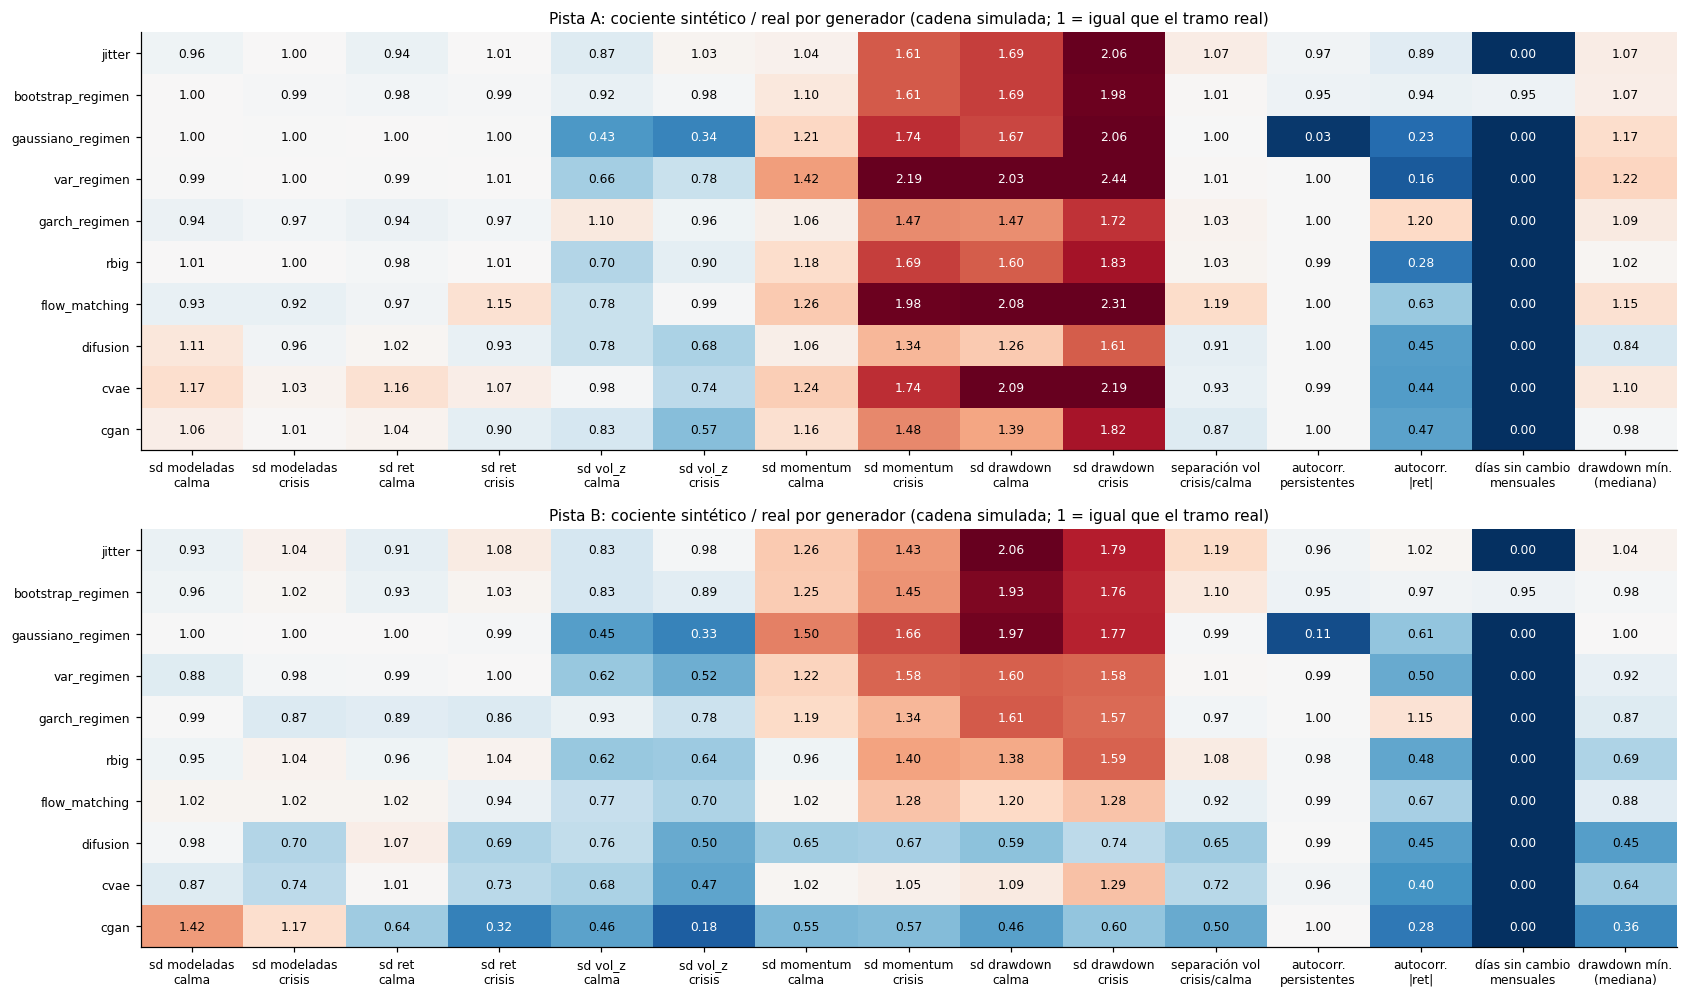

In [46]:
def cocientes(t):
    """Cocientes sintético/real de la pista t (filas = generadores) para el mapa de calor."""
    s, r = SIM.loc[t].drop(index='REAL (train)'), SIM.loc[(t, 'REAL (train)')]
    m = pd.DataFrame(index=s.index)
    for clave, etiqueta in (('sd_mod', 'sd modeladas'), ('sd_ret', 'sd ret'), ('sd_volz', 'sd vol_z'),
                            ('sd_mom', 'sd momentum'), ('sd_dd', 'sd drawdown')):
        for reg_nombre in ETIQ_REG.values():
            m[f'{etiqueta}\n{reg_nombre}'] = s[f'{clave}_{reg_nombre}']
    m['separación vol\ncrisis/calma'] = s['sep_vol'] / r['sep_vol']
    m['autocorr.\npersistentes'] = s['acf1_pers'] / r['acf1_pers']
    m['autocorr.\n|ret|'] = s['acf1_abs_ret'] / r['acf1_abs_ret']
    m['días sin cambio\nmensuales'] = s['sin_cambio'] / r['sin_cambio']
    m['drawdown mín.\n(mediana)'] = s['dd_mediana'] / r['dd_mediana']
    return m.astype(float)


COCIENTES = {t: cocientes(t) for t in PISTAS}
fig, axes = plt.subplots(len(PISTAS), 1, figsize=(15.5, 4.6 * len(PISTAS)))
for ax, t in zip(np.atleast_1d(axes), PISTAS):
    inf.dibujar_heatmap(ax, COCIENTES[t], cmap='RdBu_r', vmin=0.0, vmax=2.0, fmt='{:.2f}', umbral_blanco=0.78, fontsize=8,
                        titulo=f'Pista {t}: cociente sintético / real por generador (cadena simulada; 1 = igual que el tramo real)')
    for texto in ax.texts:   # el fondo es oscuro en los DOS extremos de la escala centrada en 1
        texto.set_color('white' if abs(float(texto.get_text()) - 1.0) > 0.56 else 'black')
    ax.grid(False)
fig.tight_layout(); guardar(fig, 'sanidad_mapa_calor'); plt.show()

figura -> results/sinteticos/generadores/ejemplos_trayectorias_pistaA.png


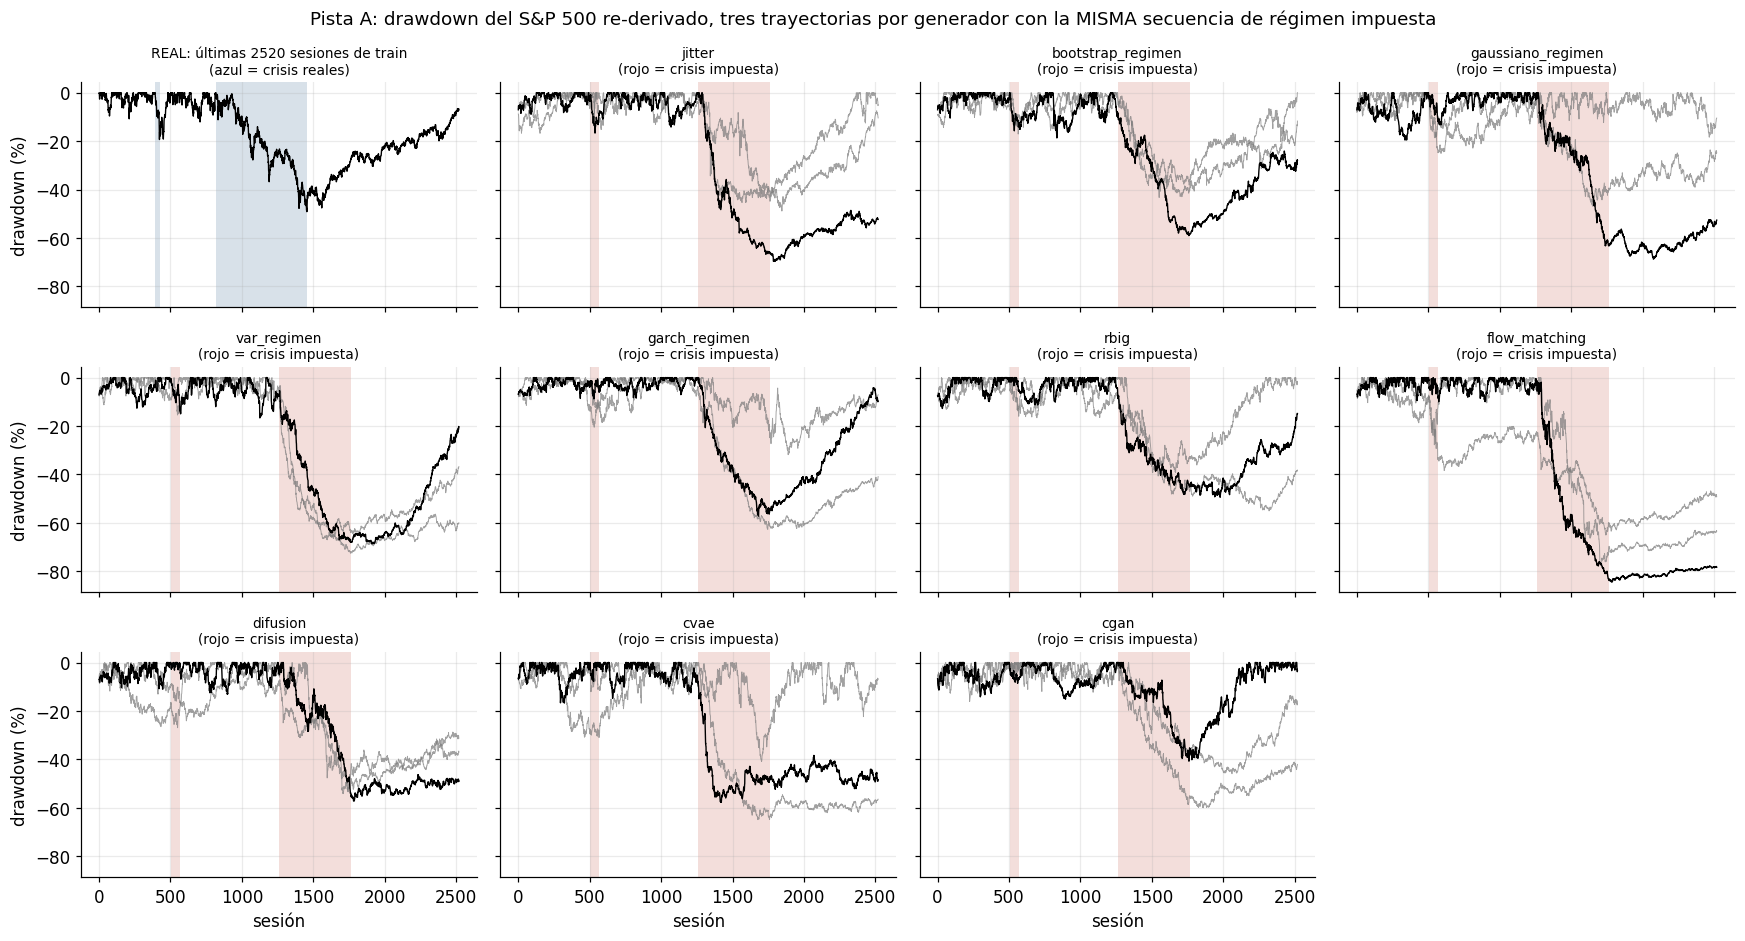

figura -> results/sinteticos/generadores/ejemplos_trayectorias_pistaB.png


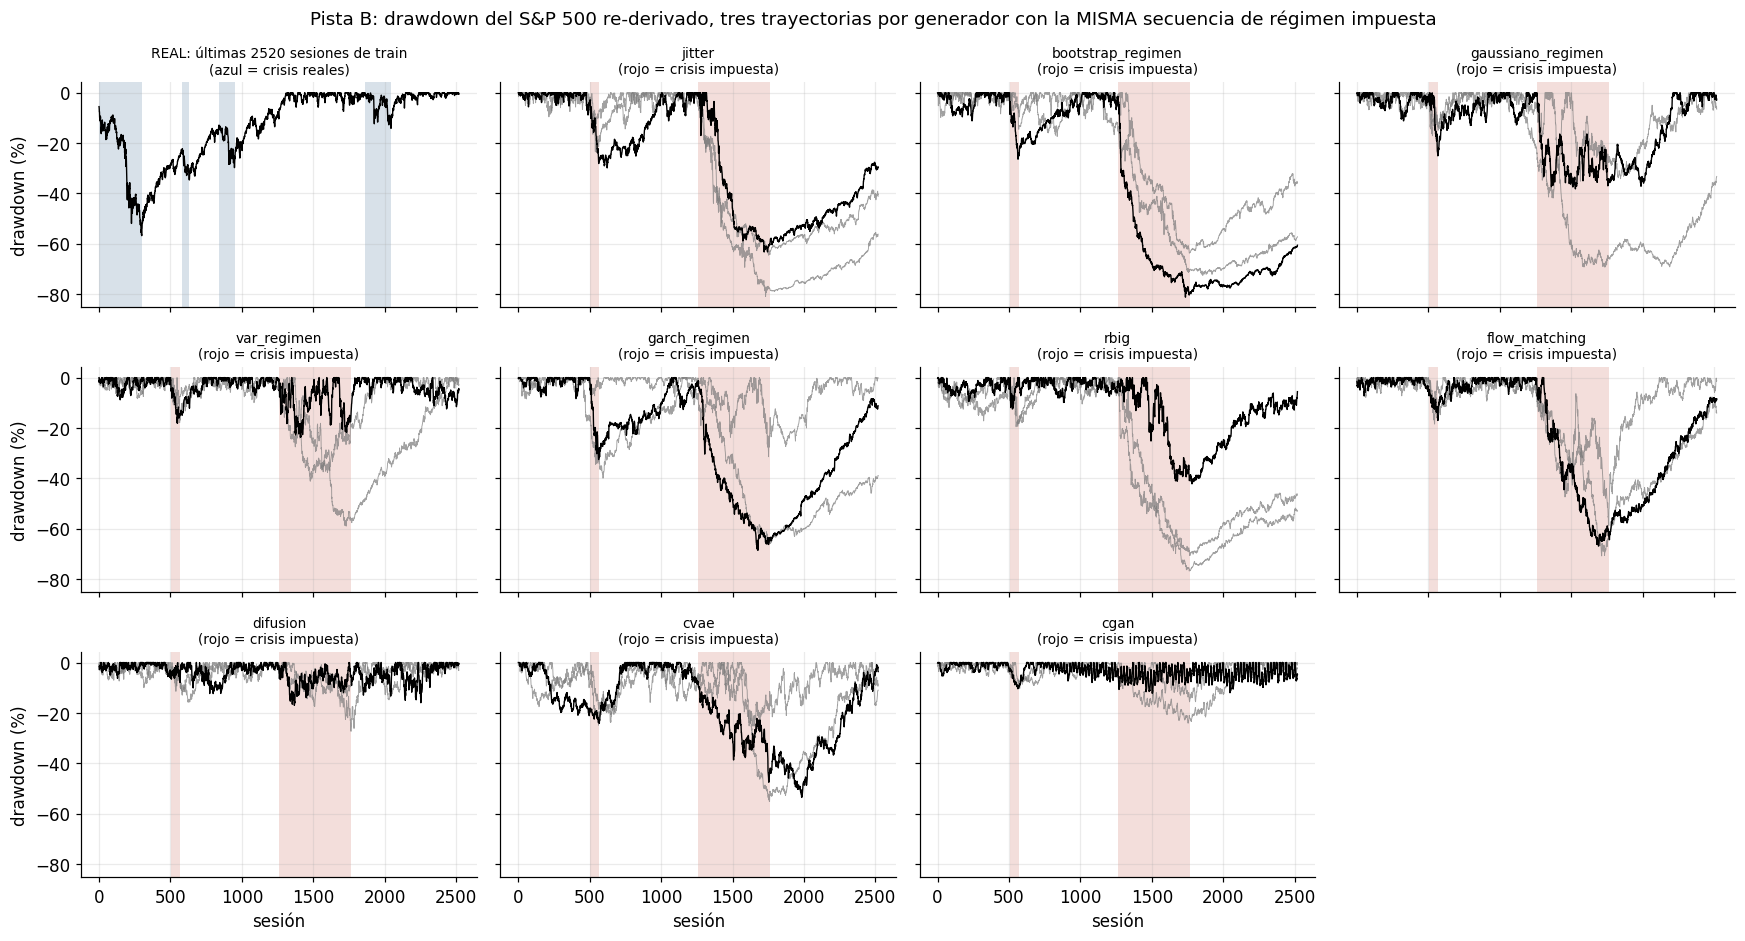

In [47]:
def franjas_secuencia(ax):
    ini = 0
    for k, n in SEGMENTOS:
        if k == 1:
            ax.axvspan(ini, ini + n, color=viz.C_CRISIS, alpha=0.16, lw=0)
        ini += n


for t in PISTAS:
    n_paneles = len(GENERADORES) + 1
    n_col = 4
    n_fil = int(np.ceil(n_paneles / n_col))
    fig, axes = plt.subplots(n_fil, n_col, figsize=(16, 2.9 * n_fil), sharex=True, sharey=True)
    axes = axes.ravel()
    # tramo real: las últimas sesiones de train, con su régimen de referencia
    real = 100 * PANEL[t]['SP500_drawdown'].to_numpy()[-LENGTH:]
    reg_real = REG[t].to_numpy()[-LENGTH:]
    ax = axes[0]
    ax.plot(np.arange(len(real)), real, color='black', lw=0.9)
    cortes = np.flatnonzero(np.diff(np.r_[0, reg_real, 0]) != 0)
    for a, b in zip(cortes[::2], cortes[1::2]):
        ax.axvspan(a, b, color=viz.C_LONG, alpha=0.18, lw=0)
    ax.set_title(f'REAL: últimas {len(real)} sesiones de train\n(azul = crisis reales)', fontsize=9)
    for ax, n in zip(axes[1:], GENERADORES):
        dd = 100 * EJEMPLOS[(t, n)]['SP500_drawdown']
        for j in (2, 1):
            ax.plot(dd[j], color=viz.C_NEG, lw=0.6, alpha=0.7)
        ax.plot(dd[0], color='black', lw=0.9)
        franjas_secuencia(ax)
        ax.set_title(f'{n}\n(rojo = crisis impuesta)', fontsize=9)
    for ax in axes[n_paneles:]:
        ax.set_visible(False)
    for ax in axes[::n_col]:
        ax.set_ylabel('drawdown (%)')
    for ax in axes[-n_col:]:
        ax.set_xlabel('sesión')
    fig.suptitle(f'Pista {t}: drawdown del S&P 500 re-derivado, tres trayectorias por generador con la MISMA secuencia de régimen '
                 f'impuesta', fontsize=12)
    fig.tight_layout(); guardar(fig, f'ejemplos_trayectorias_pista{t}'); plt.show()

figura -> results/sinteticos/generadores/sanidad_drawdown_minimo.png


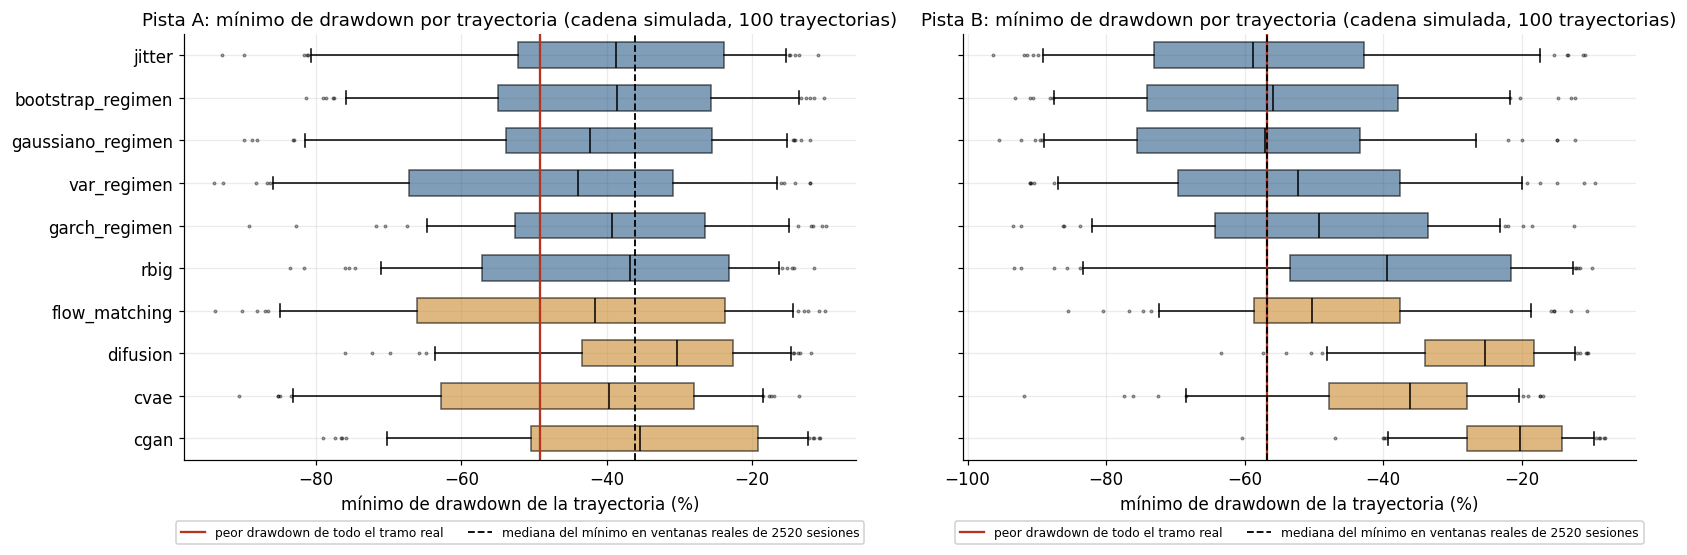

Cajas: cuartiles; bigotes: percentiles 5 y 95; azul = paramétricos, ámbar = neuronales.


In [48]:
fig, axes = plt.subplots(1, len(PISTAS), figsize=(15.5, 5.2), sharey=True)
for ax, t in zip(np.atleast_1d(axes), PISTAS):
    datos_caja = [100 * DD_MIN[(t, n)] for n in GENERADORES[::-1]]
    cajas = ax.boxplot(datos_caja, vert=False, patch_artist=True, widths=0.6, whis=(5, 95), showfliers=True,
                       flierprops={'marker': '.', 'markersize': 3, 'alpha': 0.5}, medianprops={'color': 'black'})
    for caja, n in zip(cajas['boxes'], GENERADORES[::-1]):
        caja.set(facecolor=viz.C_LONG if registro.familia_de(n) == 'parametricos' else viz.C_SHORT, alpha=0.6)
    ax.set_yticks(range(1, len(GENERADORES) + 1), GENERADORES[::-1])
    ax.axvline(100 * REAL[t]['dd_peor'], color=viz.C_CRISIS, lw=1.5, label='peor drawdown de todo el tramo real')
    ax.axvline(100 * REAL[t]['dd_ventana_mediana'], color='black', ls='--', lw=1.2,
               label=f'mediana del mínimo en ventanas reales de {LENGTH} sesiones')
    ax.set_xlabel('mínimo de drawdown de la trayectoria (%)')
    ax.set_title(f'Pista {t}: mínimo de drawdown por trayectoria (cadena simulada, {N_PATHS} trayectorias)')
    ax.legend(fontsize=8, framealpha=0.9, loc='upper center', bbox_to_anchor=(0.5, -0.13), ncol=2)
fig.tight_layout(); guardar(fig, 'sanidad_drawdown_minimo'); plt.show()
print('Cajas: cuartiles; bigotes: percentiles 5 y 95; azul = paramétricos, ámbar = neuronales.')

In [49]:
en_banda = lambda x: bool(BANDA[0] <= x <= BANDA[1])
lineas = []
for t in PISTAS:
    s, r, c = SIM.loc[t].drop(index='REAL (train)'), SIM.loc[(t, 'REAL (train)')], COCIENTES[t]
    modeladas = [n for n in s.index if all(en_banda(s.loc[n, f'sd_mod_{x}_{k}']) for x in ('min', 'max') for k in ETIQ_REG.values())]
    ret = [n for n in s.index if all(en_banda(s.loc[n, f'sd_ret_{k}']) for k in ETIQ_REG.values())]
    deriv = [n for n in s.index if all(en_banda(s.loc[n, f'sd_{x}_{k}']) for x in ('volz', 'mom', 'dd') for k in ETIQ_REG.values())]
    escal = [n for n in s.index if en_banda(c.loc[n, 'días sin cambio\nmensuales'])]
    pers = [n for n in s.index if s.loc[n, 'acf1_pers'] >= 0.99 * r['acf1_pers']]
    clus = [n for n in s.index if en_banda(c.loc[n, 'autocorr.\n|ret|'])]
    peores = s['pct_supera_real'].sort_values(ascending=False)
    extremo = pd.concat({k: s[[f'sd_mod_min_{k}', f'sd_mod_max_{k}']].astype(float).apply(np.log).abs().max(axis=1)
                         for k in ETIQ_REG.values()}, axis=1)
    peor_gen = extremo.max(axis=1).idxmax()
    peor_reg = extremo.loc[peor_gen].idxmax()
    lista = lambda xs: ', '.join(f'`{x}`' for x in xs) if xs else 'ninguno'
    lineas += [
        f"- **Pista {t}** (banda de sanidad de los cocientes: {fmt(BANDA[0])}–{fmt(BANDA[1])}).",
        f"  - Desviación por régimen de **todas** las columnas modeladas dentro de la banda: {lista(modeladas)}. "
        f"De `SP500_ret` en los dos regímenes: {lista(ret)}. El peor caso es `{peor_gen}` en {peor_reg}, con cocientes por "
        f"columna entre {fmt(s.loc[peor_gen, f'sd_mod_min_{peor_reg}'])} y {fmt(s.loc[peor_gen, f'sd_mod_max_{peor_reg}'])}.",
        f"  - Desviación de las tres columnas re-derivadas (`SP500_vol_z`, `SP500_momentum`, `SP500_drawdown`) en los "
        f"dos regímenes dentro de la banda: {lista(deriv)}.",
        f"  - Autocorrelación a un día de las columnas persistentes al menos el 99 % de la real ({fmt(r['acf1_pers'], 4)}): "
        f"{lista(pers)}. Agrupamiento de volatilidad (autocorrelación de |ret|, real {fmt(r['acf1_abs_ret'], 3)}) dentro de "
        f"la banda: {lista(clus)}.",
        f"  - Escalones mensuales (días sin cambio, real {fmt(100 * r['sin_cambio'], 1)} %) dentro de la banda: {lista(escal)}; "
        f"en el resto el porcentaje va de {fmt(100 * s['sin_cambio'].drop(index=escal).min(), 1)} a "
        f"{fmt(100 * s['sin_cambio'].drop(index=escal).max(), 1)} %.",
        f"  - Drawdown: el peor del tramo real es {fmt(100 * r['dd_peor'], 1)} %. Porcentaje de trayectorias que lo "
        f"superan, de {fmt(peores.min(), 0)} % (`{peores.idxmin()}`) a {fmt(peores.max(), 0)} % (`{peores.idxmax()}`); la "
        f"mediana del mínimo por trayectoria va de {fmt(100 * s['dd_mediana'].max(), 1)} % a {fmt(100 * s['dd_mediana'].min(), 1)} % "
        f"(mediana en ventanas reales: {fmt(100 * r['dd_mediana'], 1)} %). Trayectorias sin crisis: "
        f"{int(s['n_sin_crisis'].iloc[0])} de {N_PATHS}; días de crisis: {fmt(100 * s['frac_crisis'].iloc[0], 1)} % "
        f"(train: {fmt(100 * r['frac_crisis'], 1)} %).",
    ]
    if REAL[t]['n_ventanas'] < 5:
        igual = bool(np.isclose(r['dd_mediana'], r['dd_peor']))
        lineas.append(
            f"  - **Referencia real débil.** El tramo de entrenamiento de esta pista solo da {REAL[t]['n_ventanas']} "
            f"ventana(s) de {LENGTH} sesiones para las autocorrelaciones reales"
            + (", y la mediana del mínimo de drawdown en ventanas coincide con el peor del tramo (todas las ventanas "
               "contienen el mismo suelo)" if igual else '')
            + ": los cocientes de dinámica y de drawdown de esta pista son orientativos.")
md('**Lectura de la sanidad común (cifras de las tablas de §6; no es un veredicto de admisión).**',
   f"- Contrato (finitud, régimen impuesto, cadena compartida, columnas y fechas, reproducibilidad, carga desde disco): "
   f"{'cumplido por los ' + str(len(GENERADORES)) + ' generadores en las dos pistas' if CONTRATO_OK else '**NO se cumple en todos los casos: ver la tabla de §6.1**'}.",
   *lineas)

**Lectura de la sanidad común (cifras de las tablas de §6; no es un veredicto de admisión).**
- Contrato (finitud, régimen impuesto, cadena compartida, columnas y fechas, reproducibilidad, carga desde disco): cumplido por los 10 generadores en las dos pistas.
- **Pista A** (banda de sanidad de los cocientes: 0,80–1,25).
  - Desviación por régimen de **todas** las columnas modeladas dentro de la banda: `jitter`, `bootstrap_regimen`, `gaussiano_regimen`, `var_regimen`, `garch_regimen`, `rbig`, `flow_matching`. De `SP500_ret` en los dos regímenes: `jitter`, `bootstrap_regimen`, `gaussiano_regimen`, `var_regimen`, `garch_regimen`, `rbig`, `flow_matching`, `difusion`, `cvae`, `cgan`. El peor caso es `cgan` en calma, con cocientes por columna entre 0,87 y 2,56.
  - Desviación de las tres columnas re-derivadas (`SP500_vol_z`, `SP500_momentum`, `SP500_drawdown`) en los dos regímenes dentro de la banda: ninguno.
  - Autocorrelación a un día de las columnas persistentes al menos el 99 % de la real (0,9979): `var_regimen`, `garch_regimen`, `rbig`, `flow_matching`, `difusion`, `cvae`, `cgan`. Agrupamiento de volatilidad (autocorrelación de |ret|, real 0,188) dentro de la banda: `jitter`, `bootstrap_regimen`, `garch_regimen`.
  - Escalones mensuales (días sin cambio, real 95,2 %) dentro de la banda: `bootstrap_regimen`; en el resto el porcentaje va de 0,0 a 0,0 %.
  - Drawdown: el peor del tramo real es -49,1 %. Porcentaje de trayectorias que lo superan, de 18 % (`difusion`) a 47 % (`var_regimen`); la mediana del mínimo por trayectoria va de -30,3 % a -43,9 % (mediana en ventanas reales: -36,1 %). Trayectorias sin crisis: 14 de 100; días de crisis: 16,5 % (train: 19,6 %).
- **Pista B** (banda de sanidad de los cocientes: 0,80–1,25).
  - Desviación por régimen de **todas** las columnas modeladas dentro de la banda: `jitter`, `bootstrap_regimen`, `gaussiano_regimen`. De `SP500_ret` en los dos regímenes: `jitter`, `bootstrap_regimen`, `gaussiano_regimen`, `var_regimen`, `garch_regimen`, `rbig`, `flow_matching`. El peor caso es `cgan` en crisis, con cocientes por columna entre 0,32 y 6,30.
  - Desviación de las tres columnas re-derivadas (`SP500_vol_z`, `SP500_momentum`, `SP500_drawdown`) en los dos regímenes dentro de la banda: ninguno.
  - Autocorrelación a un día de las columnas persistentes al menos el 99 % de la real (0,9942): `var_regimen`, `garch_regimen`, `difusion`, `cgan`. Agrupamiento de volatilidad (autocorrelación de |ret|, real 0,273) dentro de la banda: `jitter`, `bootstrap_regimen`, `garch_regimen`.
  - Escalones mensuales (días sin cambio, real 95,3 %) dentro de la banda: `bootstrap_regimen`; en el resto el porcentaje va de 0,0 a 0,4 %.
  - Drawdown: el peor del tramo real es -56,8 %. Porcentaje de trayectorias que lo superan, de 1 % (`cgan`) a 55 % (`jitter`); la mediana del mínimo por trayectoria va de -20,3 % a -58,8 % (mediana en ventanas reales: -56,8 %). Trayectorias sin crisis: 1 de 100; días de crisis: 24,8 % (train: 25,9 %).
  - **Referencia real débil.** El tramo de entrenamiento de esta pista solo da 1 ventana(s) de 2520 sesiones para las autocorrelaciones reales, y la mediana del mínimo de drawdown en ventanas coincide con el peor del tramo (todas las ventanas contienen el mismo suelo): los cocientes de dinámica y de drawdown de esta pista son orientativos.

<a id="s7"></a>
## 7. Resumen y siguiente paso

La conclusión, las respuestas a las cuatro preguntas de §0 y las limitaciones se generan en las
celdas siguientes a partir de las tablas de §6 y de los diagnósticos de §4 y §5. Las listas «dentro
de la banda» son un resumen de sanidad con una convención declarada (§4, `BANDA`), no una
clasificación de generadores admitidos y rechazados.

In [50]:
coste = SIM.drop(index='REAL (train)', level='generador')[['familia', 'ajuste_s', 'muestreo_simulada_s', 'muestreo_impuesta_s']]
por_familia = coste.groupby(['pista', 'familia'])[['ajuste_s', 'muestreo_simulada_s', 'muestreo_impuesta_s']].sum()
lento = {t: coste.loc[t]['ajuste_s'].idxmax() for t in PISTAS}
total_min = coste[['ajuste_s', 'muestreo_simulada_s', 'muestreo_impuesta_s']].sum().sum() / 60
comunes = {}
for clave, col, criterio in (('escalones', 'días sin cambio\nmensuales', None), ('agrupamiento', 'autocorr.\n|ret|', None)):
    comunes[clave] = {t: [n for n in GENERADORES if not en_banda(COCIENTES[t].loc[n, col])] for t in PISTAS}
fuera_deriv = {t: [n for n in GENERADORES if not all(en_banda(SIM.loc[(t, n), f'sd_{x}_{k}']) for x in ('volz', 'mom', 'dd')
                                                     for k in ETIQ_REG.values())] for t in PISTAS}
supera = {t: [n for n in GENERADORES if SIM.loc[(t, n), 'pct_supera_real'] > 0] for t in PISTAS}
lista = lambda xs: ', '.join(f'`{x}`' for x in xs) if xs else 'ninguno'
todos = lambda xs: len(xs) == len(GENERADORES)
display(por_familia.style.format('{:.1f}').set_caption('Coste por familia y pista (segundos, suma de generadores)'))
md('### 7.1 Conclusión (generada)',
   f"- **Qué se ha construido.** {len(GENERADORES)} generadores ({len(PARAMETRICOS)} paramétricos, {len(NEURONALES)} "
   f"neuronales) ajustados en {len(PISTAS)} pistas solo con el tramo de entrenamiento, y {N_PATHS} trayectorias de {LENGTH} "
   f"sesiones por generador, pista y modo de régimen, con la verdad-terreno en la columna `regime`. Contrato "
   f"{'cumplido en todos los casos' if CONTRATO_OK else '**incumplido en algún caso** (§6.1)'}.",
   f"- **Coste.** Ajuste más muestreo de todo el catálogo: {fmt(total_min, 1)} minutos de CPU. "
   + ' '.join(f"Pista {t}: paramétricos {fmt(por_familia.loc[(t, 'parametricos'), 'ajuste_s'], 1)} s de ajuste, neuronales "
              f"{fmt(por_familia.loc[(t, 'neuronales'), 'ajuste_s'] / 60, 1)} min (el más lento, `{lento[t]}`: "
              f"{fmt(coste.loc[(t, lento[t]), 'ajuste_s'] / 60, 1)} min)." for t in PISTAS),
   '- **Qué reproduce cada uno.** Ver la lectura de §6 por pista. La escala por régimen de todas las columnas modeladas '
   'queda dentro de la banda en '
   + ' y en '.join(f"{sum(all(en_banda(SIM.loc[(t, n), f'sd_mod_{x}_{k}']) for x in ('min', 'max') for k in ETIQ_REG.values()) for n in GENERADORES)} "
                   f"de {len(GENERADORES)} generadores en la pista {t}" for t in PISTAS)
   + '. La dinámica (persistencia, agrupamiento de volatilidad) separa a los generadores con memoria de los que extraen '
   'días independientes.',
   '- **Qué falla de forma generalizada** (fuera de la banda de sanidad):',
   *[f"  - Pista {t}: escalones mensuales fuera de la banda en {len(comunes['escalones'][t])} de {len(GENERADORES)} "
     f"({lista(comunes['escalones'][t])}); alguna columna re-derivada fuera de la banda en {len(fuera_deriv[t])} de "
     f"{len(GENERADORES)} ({lista(fuera_deriv[t])}); agrupamiento de volatilidad fuera de la banda en "
     f"{len(comunes['agrupamiento'][t])} ({lista(comunes['agrupamiento'][t])}); trayectorias con un drawdown más profundo "
     f"que el peor del tramo real en {len(supera[t])} de {len(GENERADORES)} generadores." for t in PISTAS],
   '- **Lectura.** Escalones, columnas re-derivadas y drawdown fallan por razones estructurales, distintas entre sí, que '
   'no se arreglan cambiando de generador (el agrupamiento de volatilidad sí depende del generador): los escalones mensuales solo '
   'los conserva quien copia filas reales; las columnas re-derivadas acumulan el error de la dinámica de `SP500_ret` a lo '
   'largo de ventanas largas; y los drawdowns dependen de la duración de la crisis sorteada por la deriva media del '
   'régimen (§2.2), de modo que también el bootstrap, que solo recombina días reales, produce caídas que el tramo '
   'real no contiene.')

### 7.1 Conclusión (generada)
- **Qué se ha construido.** 10 generadores (6 paramétricos, 4 neuronales) ajustados en 2 pistas solo con el tramo de entrenamiento, y 100 trayectorias de 2520 sesiones por generador, pista y modo de régimen, con la verdad-terreno en la columna `regime`. Contrato cumplido en todos los casos.
- **Coste.** Ajuste más muestreo de todo el catálogo: 11,0 minutos de CPU. Pista A: paramétricos 4,8 s de ajuste, neuronales 6,1 min (el más lento, `cvae`: 2,3 min). Pista B: paramétricos 2,5 s de ajuste, neuronales 1,6 min (el más lento, `cgan`: 0,7 min).
- **Qué reproduce cada uno.** Ver la lectura de §6 por pista. La escala por régimen de todas las columnas modeladas queda dentro de la banda en 7 de 10 generadores en la pista A y en 3 de 10 generadores en la pista B. La dinámica (persistencia, agrupamiento de volatilidad) separa a los generadores con memoria de los que extraen días independientes.
- **Qué falla de forma generalizada** (fuera de la banda de sanidad):
  - Pista A: escalones mensuales fuera de la banda en 9 de 10 (`jitter`, `gaussiano_regimen`, `var_regimen`, `garch_regimen`, `rbig`, `flow_matching`, `difusion`, `cvae`, `cgan`); alguna columna re-derivada fuera de la banda en 10 de 10 (`jitter`, `bootstrap_regimen`, `gaussiano_regimen`, `var_regimen`, `garch_regimen`, `rbig`, `flow_matching`, `difusion`, `cvae`, `cgan`); agrupamiento de volatilidad fuera de la banda en 7 (`gaussiano_regimen`, `var_regimen`, `rbig`, `flow_matching`, `difusion`, `cvae`, `cgan`); trayectorias con un drawdown más profundo que el peor del tramo real en 10 de 10 generadores.
  - Pista B: escalones mensuales fuera de la banda en 9 de 10 (`jitter`, `gaussiano_regimen`, `var_regimen`, `garch_regimen`, `rbig`, `flow_matching`, `difusion`, `cvae`, `cgan`); alguna columna re-derivada fuera de la banda en 10 de 10 (`jitter`, `bootstrap_regimen`, `gaussiano_regimen`, `var_regimen`, `garch_regimen`, `rbig`, `flow_matching`, `difusion`, `cvae`, `cgan`); agrupamiento de volatilidad fuera de la banda en 7 (`gaussiano_regimen`, `var_regimen`, `rbig`, `flow_matching`, `difusion`, `cvae`, `cgan`); trayectorias con un drawdown más profundo que el peor del tramo real en 10 de 10 generadores.
- **Lectura.** Escalones, columnas re-derivadas y drawdown fallan por razones estructurales, distintas entre sí, que no se arreglan cambiando de generador (el agrupamiento de volatilidad sí depende del generador): los escalones mensuales solo los conserva quien copia filas reales; las columnas re-derivadas acumulan el error de la dinámica de `SP500_ret` a lo largo de ventanas largas; y los drawdowns dependen de la duración de la crisis sorteada por la deriva media del régimen (§2.2), de modo que también el bootstrap, que solo recombina días reales, produce caídas que el tramo real no contiene.

In [51]:
# Respuestas a las cuatro preguntas de §0 (cifras de SIM, IMP, COCIENTES y de las tablas de §4–§5).
resp = []
s_a = SIM.loc[PISTA_PRINCIPAL].drop(index='REAL (train)')
r_a = SIM.loc[(PISTA_PRINCIPAL, 'REAL (train)')]
param_ok = [n for n in PARAMETRICOS if all(en_banda(s_a.loc[n, f'sd_mod_{x}_{k}']) for x in ('min', 'max') for k in ETIQ_REG.values())]
sep = s_a['sep_vol']
resp.append(
    f"1. **¿Qué paramétricos reproducen la dinámica de régimen?** Duraciones y transiciones no las decide ningún generador: "
    f"las pone la cadena común (§2.1), que reproduce la fracción de crisis pero no la forma de la distribución de "
    f"duraciones. Niveles por régimen (pista {PISTA_PRINCIPAL}): todas las columnas modeladas dentro de la banda en "
    f"{lista(param_ok)}; la separación de volatilidad crisis/calma real es {fmt(r_a['sep_vol'])} y la sintética va de "
    f"{fmt(sep[PARAMETRICOS].min())} (`{sep[PARAMETRICOS].idxmin()}`) a {fmt(sep[PARAMETRICOS].max())} "
    f"(`{sep[PARAMETRICOS].idxmax()}`). La persistencia la conservan los que tienen memoria o copian tramos y la "
    f"destruye el gaussiano (autocorrelación de las columnas persistentes: {fmt(s_a.loc['gaussiano_regimen', 'acf1_pers'], 3)} "
    f"frente a {fmt(r_a['acf1_pers'], 4)} real).")
neur = s_a.loc[NEURONALES]
resp.append(
    f"2. **¿Aportan los neuronales realismo adicional sin memorizar?** Este notebook no puede contestarlo: colas, "
    f"dependencia no lineal y memorización son `16`. Lo que sí se ve aquí (pista {PISTA_PRINCIPAL}) es que en sanidad no "
    f"superan a los paramétricos: la mediana del cociente de desviación de las columnas modeladas va de "
    f"{fmt(neur[['sd_mod_calma', 'sd_mod_crisis']].min().min())} a {fmt(neur[['sd_mod_calma', 'sd_mod_crisis']].max().max())}, "
    f"la autocorrelación de |ret| de {fmt(neur['acf1_abs_ret'].min(), 3)} a {fmt(neur['acf1_abs_ret'].max(), 3)} (real "
    f"{fmt(r_a['acf1_abs_ret'], 3)}; `garch_regimen`: {fmt(s_a.loc['garch_regimen', 'acf1_abs_ret'], 3)}) y ninguno conserva los "
    f"escalones mensuales (días sin cambio: como máximo {fmt(100 * neur['sin_cambio'].max(), 1)} %). Su coste de ajuste es "
    f"{fmt(por_familia.loc[(PISTA_PRINCIPAL, 'neuronales'), 'ajuste_s'] / max(por_familia.loc[(PISTA_PRINCIPAL, 'parametricos'), 'ajuste_s'], 1e-9), 0)} "
    f"veces el de los paramétricos.")
resp.append(
    f"3. **¿Cómo se impone una secuencia de régimen y cómo se etiqueta la verdad-terreno?** `sample(n_paths, length, "
    f"regimes, random_state)` admite un vector (se impone a todas las trayectorias), una matriz por trayectoria, o un "
    f"`dict` con las opciones de la cadena simulada; la salida lleva la columna `regime`. Comprobado en los "
    f"{len(GENERADORES)} generadores y las {len(PISTAS)} pistas: el régimen impuesto se respeta día a día en "
    f"{int(T1.drop(index='REAL (train)', level='generador')['régimen impuesto respetado'].astype(bool).sum())} de "
    f"{len(GENERADORES) * len(PISTAS)} casos. La etiqueta significa «día extraído de la ley condicional de crisis», no "
    f"«tramo pico→suelo» (§2.2).")
rep_ok = T1.drop(index='REAL (train)', level='generador')[['reproducible con semilla', 'cargado = ajustado']].astype(bool).all(axis=1)
resp.append(
    f"4. **¿Coste y reproducibilidad?** {fmt(total_min, 1)} minutos de CPU para todo el catálogo y las dos pistas (detalle en "
    f"§6.1); con `EJECUTAR = False` el notebook solo carga. Dos muestras con la misma semilla son idénticas, y el "
    f"generador cargado de disco reproduce la muestra de control del ajustado, en {int(rep_ok.sum())} de {len(rep_ok)} casos.")
md('### 7.2 Respuestas a las preguntas de §0 (generadas)', *resp)

### 7.2 Respuestas a las preguntas de §0 (generadas)
1. **¿Qué paramétricos reproducen la dinámica de régimen?** Duraciones y transiciones no las decide ningún generador: las pone la cadena común (§2.1), que reproduce la fracción de crisis pero no la forma de la distribución de duraciones. Niveles por régimen (pista A): todas las columnas modeladas dentro de la banda en `jitter`, `bootstrap_regimen`, `gaussiano_regimen`, `var_regimen`, `garch_regimen`, `rbig`; la separación de volatilidad crisis/calma real es 1,54 y la sintética va de 1,54 (`gaussiano_regimen`) a 1,66 (`jitter`). La persistencia la conservan los que tienen memoria o copian tramos y la destruye el gaussiano (autocorrelación de las columnas persistentes: 0,032 frente a 0,9979 real).
2. **¿Aportan los neuronales realismo adicional sin memorizar?** Este notebook no puede contestarlo: colas, dependencia no lineal y memorización son `16`. Lo que sí se ve aquí (pista A) es que en sanidad no superan a los paramétricos: la mediana del cociente de desviación de las columnas modeladas va de 0,92 a 1,17, la autocorrelación de |ret| de 0,083 a 0,119 (real 0,188; `garch_regimen`: 0,225) y ninguno conserva los escalones mensuales (días sin cambio: como máximo 0,0 %). Su coste de ajuste es 77 veces el de los paramétricos.
3. **¿Cómo se impone una secuencia de régimen y cómo se etiqueta la verdad-terreno?** `sample(n_paths, length, regimes, random_state)` admite un vector (se impone a todas las trayectorias), una matriz por trayectoria, o un `dict` con las opciones de la cadena simulada; la salida lleva la columna `regime`. Comprobado en los 10 generadores y las 2 pistas: el régimen impuesto se respeta día a día en 20 de 20 casos. La etiqueta significa «día extraído de la ley condicional de crisis», no «tramo pico→suelo» (§2.2).
4. **¿Coste y reproducibilidad?** 11,0 minutos de CPU para todo el catálogo y las dos pistas (detalle en §6.1); con `EJECUTAR = False` el notebook solo carga. Dos muestras con la misma semilla son idénticas, y el generador cargado de disco reproduce la muestra de control del ajustado, en 20 de 20 casos.

In [52]:
ep_n = {t: len(EPISODIOS[t]) for t in PISTAS}
val_sin_crisis = [f'`{n}` (pista {t})' for n in ('flow_matching', 'difusion') for t in PISTAS
                  if GEN[(t, n)].reparto_['categorias_validacion'][1] + GEN[(t, n)].reparto_['categorias_validacion'][2] == 0]
rec_garch = {t: 100 * DIAG[(t, 'garch_regimen', 'simulada')]['fraccion_recorte_varianza'] for t in PISTAS}
dias_no_sesion = {t: (len(pd.bdate_range(PANEL[t].index[0], PANEL[t].index[-1])) - len(PANEL[t]))
                  / ((PANEL[t].index[-1] - PANEL[t].index[0]).days / 365.25) for t in PISTAS}
rango_supera = lambda tabla, t: (f"{fmt(tabla.loc[t].loc[GENERADORES, 'pct_supera_real'].min(), 0)}–"
                                f"{fmt(tabla.loc[t].loc[GENERADORES, 'pct_supera_real'].max(), 0)} %")
flojos = {t: [n for n in GENERADORES
              if SIM.loc[(t, n), 'sep_vol'] / SIM.loc[(t, 'REAL (train)'), 'sep_vol'] < BANDA[0]] for t in PISTAS}
texto_flojos = '; '.join(
    f"pista {t}: " + (', '.join(f"`{n}` (separación {fmt(SIM.loc[(t, n), 'sep_vol'])}, retorno medio en crisis "
                                 f"{fmt(SIM.loc[(t, n), 'ret_crisis_pb'], 1)} pb)" for n in flojos[t])
                       + f" frente a {fmt(SIM.loc[(t, 'REAL (train)'), 'sep_vol'])} y "
                         f"{fmt(SIM.loc[(t, 'REAL (train)'), 'ret_crisis_pb'], 1)} pb reales" if flojos[t] else 'ninguno')
    for t in PISTAS)
pocas_ventanas = [t for t in PISTAS if REAL[t]['n_ventanas'] < 5]
md('### 7.3 Limitaciones declaradas (generadas)',
   f"1. **Semántica de `regime`.** En sintético `regime = 1` es «día de la ley condicional de crisis», no «tramo "
   f"pico→suelo» (§2.2). Los drawdowns sintéticos dependen de la duración sorteada y no se parecen a los reales: "
   f"el peor drawdown de todo el tramo de entrenamiento lo supera, según el generador, el "
   + ' y el '.join(f"{rango_supera(SIM, t)} de las trayectorias en la pista {t}" for t in PISTAS)
   + " con la cadena simulada (§6.3), y el "
   + ' y el '.join(f"{rango_supera(IMP, t)} en la pista {t}" for t in PISTAS)
   + f" con la secuencia impuesta (§6.4), cuya crisis larga es una decisión de diseño de este notebook. Un detector evaluado sobre estas trayectorias se mide "
   f"contra esa etiqueta, no contra la definición histórica de crisis.",
   f"2. **Pocas crisis en el tramo de entrenamiento**: " + ' y '.join(f'{ep_n[t]} episodios en la pista {t}' for t in PISTAS)
   + ". Todo lo que es «de crisis» (medias, covarianzas, VAR, GARCH, modelos por régimen, ventanas de los neuronales) se "
   "estima con esos pocos episodios, muy solapados entre sí en las ventanas; la matriz de transición, con otras tantas "
   "transiciones.",
   f"3. **Cadena compartida.** Todos los generadores reciben el mismo sorteo de regímenes: la comparación es pareada, "
   f"pero cada cifra de §6 está condicionada a ese sorteo (" + '; '.join(
       f"pista {t}: {fmt(100 * SIM.loc[(t, GENERADORES[0]), 'frac_crisis'], 1)} % de crisis frente al "
       f"{fmt(100 * FREC[t][1], 1)} % de train, trayectorias sin crisis: {int(SIM.loc[(t, GENERADORES[0]), 'n_sin_crisis'])}"
       for t in PISTAS) + "). Las duraciones geométricas no reproducen la distribución real de duraciones (§2.1).",
   "4. **Soporte acotado de `bootstrap_regimen`, `jitter` y `rbig`.** No generan un día peor que el peor observado (o "
   "solo a una distancia de ruido de él): como fuente de escenarios extremos nuevos son estériles por construcción.",
   f"5. **Techo de varianza del GARCH.** El generador no produce volatilidad condicional por encima del cuantil elegido de "
   f"su régimen en train; el techo actúa en el " + ' y el '.join(f"{fmt(rec_garch[t], 3)} % de las celdas en la pista {t}" for t in PISTAS)
   + ". Es una decisión de modelado que recorta la cola que más interesaría estresar.",
   "6. **Selección de época y validación interna de los neuronales.** Flow matching, difusión y cVAE eligen la época con "
   "una cola cronológica del propio tramo de entrenamiento (no es un tramo independiente, y en el flow matching y la "
   "difusión no se usa para ajustar); la cGAN no tiene ningún criterio de parada. "
   + (f"La cola de validación no contiene ninguna ventana con crisis en: {', '.join(val_sin_crisis)}. " if val_sin_crisis else '')
   + "Los hiperparámetros se fijaron mirando trayectorias del propio tramo de entrenamiento de la pista principal.",
   f"7. **Calendario.** Las fechas sintéticas son días hábiles de lunes a viernes, no sesiones de la NYSE ("
   + ' y '.join(f"{fmt(dias_no_sesion[t], 1)} días por año de diferencia en la pista {t}" for t in PISTAS)
   + "): son una etiqueta ordenada y no deben cruzarse por fecha con datos reales.",
   "8. **Columnas mensuales y re-derivadas.** Salvo los que copian filas reales, ningún generador produce escalones "
   "mensuales; y las columnas re-derivadas del S&P 500 no las controla el generador (§3). Un detector que use la "
   "regularidad de los escalones o el nivel del drawdown verá un panel distinto del real.",
   f"9. **Condicionamiento al régimen débil en algunos generadores.** Separación de volatilidad crisis/calma por "
   f"debajo de la banda respecto a la real — {texto_flojos}. Ahí un día con `regime = 1` se distingue poco de uno de "
   f"calma: la verdad-terreno es exacta como etiqueta pero casi no lleva señal, y un detector evaluado sobre esas "
   f"trayectorias fallaría por el generador, no por el detector.",
   f"10. **Alcance de las métricas de sanidad.** Las autocorrelaciones de §6.3 son de la trayectoria entera, no de "
   f"dentro de cada régimen (incluyen el cambio de nivel entre regímenes). Los porcentajes sobre trayectorias se "
   f"estiman con {N_PATHS} trayectorias de un único sorteo: su error estándar llega a "
   f"{fmt(100 * 0.5 / np.sqrt(N_PATHS), 0)} puntos, así que las ordenaciones entre generadores próximos no son "
   f"significativas. "
   + (f"La fila «REAL» de dinámica y drawdown descansa en una sola ventana en: pista {', '.join(pocas_ventanas)}. "
      if pocas_ventanas else '')
   + "La banda de los cocientes es una convención de lectura fijada a priori, no un umbral contrastado.",
   "11. **Esto es sanidad, no validación.** Ninguna cifra de este notebook mide fidelidad distribucional, memorización ni "
   "utilidad, y ningún generador queda aquí admitido o descartado.")

### 7.3 Limitaciones declaradas (generadas)
1. **Semántica de `regime`.** En sintético `regime = 1` es «día de la ley condicional de crisis», no «tramo pico→suelo» (§2.2). Los drawdowns sintéticos dependen de la duración sorteada y no se parecen a los reales: el peor drawdown de todo el tramo de entrenamiento lo supera, según el generador, el 18–47 % de las trayectorias en la pista A y el 1–55 % de las trayectorias en la pista B con la cadena simulada (§6.3), y el 35–80 % en la pista A y el 0–81 % en la pista B con la secuencia impuesta (§6.4), cuya crisis larga es una decisión de diseño de este notebook. Un detector evaluado sobre estas trayectorias se mide contra esa etiqueta, no contra la definición histórica de crisis.
2. **Pocas crisis en el tramo de entrenamiento**: 8 episodios en la pista A y 4 episodios en la pista B. Todo lo que es «de crisis» (medias, covarianzas, VAR, GARCH, modelos por régimen, ventanas de los neuronales) se estima con esos pocos episodios, muy solapados entre sí en las ventanas; la matriz de transición, con otras tantas transiciones.
3. **Cadena compartida.** Todos los generadores reciben el mismo sorteo de regímenes: la comparación es pareada, pero cada cifra de §6 está condicionada a ese sorteo (pista A: 16,5 % de crisis frente al 19,6 % de train, trayectorias sin crisis: 14; pista B: 24,8 % de crisis frente al 25,9 % de train, trayectorias sin crisis: 1). Las duraciones geométricas no reproducen la distribución real de duraciones (§2.1).
4. **Soporte acotado de `bootstrap_regimen`, `jitter` y `rbig`.** No generan un día peor que el peor observado (o solo a una distancia de ruido de él): como fuente de escenarios extremos nuevos son estériles por construcción.
5. **Techo de varianza del GARCH.** El generador no produce volatilidad condicional por encima del cuantil elegido de su régimen en train; el techo actúa en el 0,108 % de las celdas en la pista A y el 0,413 % de las celdas en la pista B. Es una decisión de modelado que recorta la cola que más interesaría estresar.
6. **Selección de época y validación interna de los neuronales.** Flow matching, difusión y cVAE eligen la época con una cola cronológica del propio tramo de entrenamiento (no es un tramo independiente, y en el flow matching y la difusión no se usa para ajustar); la cGAN no tiene ningún criterio de parada. La cola de validación no contiene ninguna ventana con crisis en: `flow_matching` (pista B), `difusion` (pista B). Los hiperparámetros se fijaron mirando trayectorias del propio tramo de entrenamiento de la pista principal.
7. **Calendario.** Las fechas sintéticas son días hábiles de lunes a viernes, no sesiones de la NYSE (9,2 días por año de diferencia en la pista A y 9,0 días por año de diferencia en la pista B): son una etiqueta ordenada y no deben cruzarse por fecha con datos reales.
8. **Columnas mensuales y re-derivadas.** Salvo los que copian filas reales, ningún generador produce escalones mensuales; y las columnas re-derivadas del S&P 500 no las controla el generador (§3). Un detector que use la regularidad de los escalones o el nivel del drawdown verá un panel distinto del real.
9. **Condicionamiento al régimen débil en algunos generadores.** Separación de volatilidad crisis/calma por debajo de la banda respecto a la real — pista A: ninguno; pista B: `difusion` (separación 1,43, retorno medio en crisis -3,2 pb), `cvae` (separación 1,59, retorno medio en crisis -4,9 pb), `cgan` (separación 1,10, retorno medio en crisis -3,9 pb) frente a 2,21 y -19,5 pb reales. Ahí un día con `regime = 1` se distingue poco de uno de calma: la verdad-terreno es exacta como etiqueta pero casi no lleva señal, y un detector evaluado sobre esas trayectorias fallaría por el generador, no por el detector.
10. **Alcance de las métricas de sanidad.** Las autocorrelaciones de §6.3 son de la trayectoria entera, no de dentro de cada régimen (incluyen el cambio de nivel entre regímenes). Los porcentajes sobre trayectorias se estiman con 100 trayectorias de un único sorteo: su error estándar llega a 5 puntos, así que las ordenaciones entre generadores próximos no son significativas. La fila «REAL» de dinámica y drawdown descansa en una sola ventana en: pista B. La banda de los cocientes es una convención de lectura fijada a priori, no un umbral contrastado.
11. **Esto es sanidad, no validación.** Ninguna cifra de este notebook mide fidelidad distribucional, memorización ni utilidad, y ningún generador queda aquí admitido o descartado.

### 7.4 Siguiente paso

[`16_sinteticos_validacion`](16_sinteticos_validacion.ipynb) lee las trayectorias guardadas aquí
(`persistencia.cargar_trayectorias`) y decide qué generadores se admiten: fidelidad (discriminador
real frente a sintético, hechos estilizados, colas condicionales al régimen), memorización
(distancia al vecino real más cercano, con `jitter` y `bootstrap_regimen` como controles
positivos) y utilidad (entrenar en sintético y evaluar en real). Solo los admitidos pasan al
laboratorio de [`17_sinteticos_laboratorio`](17_sinteticos_laboratorio.ipynb) y al aumento de
[`18_sinteticos_aumento`](18_sinteticos_aumento.ipynb).

In [53]:
SALIDAS = {'tabla de sanidad completa': ruta_sanidad}
for t in PISTAS:
    for nombre_tabla in ('coste_contrato', 'escala', 'dinamica', 'impuesta'):
        SALIDAS[f'tabla de sanidad ({nombre_tabla}), pista {t}'] = RES_DIR / f'sanidad_{nombre_tabla}_pista{t}.csv'
    for n in GENERADORES:
        SALIDAS[f'{n}, pista {t}: modelo'] = carpeta_modelo(n, t) / FICHERO_MODELO
        for modo, fichero in FICHERO_TRAY.items():
            SALIDAS[f'{n}, pista {t}: trayectorias ({modo})'] = carpeta_modelo(n, t) / fichero
        SALIDAS[f'{n}, pista {t}: ficha'] = ruta_ficha(n, t)
        SALIDAS[f'{n}, pista {t}: historial'] = RES_DIR / f'{n}_pista{t}_historial.csv'
TABLA_SALIDAS = pd.DataFrame([{'salida': k, 'ruta': rel(v), 'existe': v.exists(),
                               'MB': round(v.stat().st_size / 2**20, 2) if v.exists() else np.nan}
                              for k, v in SALIDAS.items()]).set_index('salida')
with pd.option_context('display.max_rows', None):
    display(TABLA_SALIDAS)
versionable = TABLA_SALIDAS[TABLA_SALIDAS['ruta'].str.startswith(rel(RES_DIR))]['MB'].sum()
print(f"{int(TABLA_SALIDAS['existe'].sum())} de {len(TABLA_SALIDAS)} salidas existen; "
      f"{TABLA_SALIDAS['MB'].sum():.0f} MB en total ({versionable:.2f} MB versionables en {rel(RES_DIR)}, "
      f"el resto gitignored en {rel(rutas.DATA_SINTETICOS)}).")
fichas = persistencia.cargar_resumenes()
print(f'Fichas legibles con persistencia.cargar_resumenes(): {len(fichas)} (generador x pista).')
print(f'Figuras de este notebook en {rel(FIG_DIR)}:')
for ruta in sorted(FIG_DIR.glob('*.png')):
    print('  -', ruta.name)

,ruta,existe,MB
salida,,,
tabla de sanidad completa,results/sinteticos/generadores/sanidad_generadores.csv,True,0.03
"tabla de sanidad (coste_contrato), pista A",results/sinteticos/generadores/sanidad_coste_contrato_pistaA.csv,True,0.00
"tabla de sanidad (escala), pista A",results/sinteticos/generadores/sanidad_escala_pistaA.csv,True,0.00
"tabla de sanidad (dinamica), pista A",results/sinteticos/generadores/sanidad_dinamica_pistaA.csv,True,0.00
"tabla de sanidad (impuesta), pista A",results/sinteticos/generadores/sanidad_impuesta_pistaA.csv,True,0.00
"jitter, pista A: modelo",data/sinteticos/jitter/pistaA/generador.pkl,True,1.16
"jitter, pista A: trayectorias (simulada)",data/sinteticos/jitter/pistaA/trayectorias.parquet,True,21.81
"jitter, pista A: trayectorias (impuesta)",data/sinteticos/jitter/pistaA/trayectorias_impuesto.parquet,True,21.84
"jitter, pista A: ficha",results/sinteticos/generadores/jitter_pistaA_resumen.json,True,0.00


109 de 109 salidas existen; 1069 MB en total (0.12 MB versionables en results/sinteticos/generadores, el resto gitignored en data/sinteticos).
Fichas legibles con persistencia.cargar_resumenes(): 20 (generador x pista).
Figuras de este notebook en results/sinteticos/generadores:
  - bootstrap_barrido_longitud.png
  - cadena_duraciones_crisis.png
  - cgan_convergencia.png
  - cvae_convergencia.png
  - difusion_perdida.png
  - ejemplos_trayectorias_pistaA.png
  - ejemplos_trayectorias_pistaB.png
  - flow_matching_perdida.png
  - garch_volatilidad_filtrada.png
  - gaussiano_condicionamiento.png
  - jitter_barrido_sigma.png
  - rbig_reduccion_informacion.png
  - sanidad_drawdown_minimo.png
  - sanidad_mapa_calor.png
  - semantica_regimen_deriva_duracion.png
  - train_regimen_referencia.png
  - var_estabilidad_y_ancla.png
